<div style="background: linear-gradient(135deg, #e9f2fb 0%, #f7fbff 100%); padding: 18px 20px; border: 1px solid #d5e3f0; border-radius: 10px; text-align: center;">
  <div style="font-size: 32px; font-weight: 700; color: #1f3b57; letter-spacing: 0.2px;">NX-414 Brain-like Computation and Intelligence</div>
</div>


<div style="text-align: center; font-size: 21px; font-weight: 600; color: #36536b; margin-top: 6px;">Project Notebook — Spring 2026</div>


<div style="text-align: center; color: #4f6478; font-size: 16px; margin-bottom: 10px;">Brain–Model Alignment Across Neural Recording Modalities</div>
<div style="text-align: center; color: #6b7280; font-size: 13px;">Prepared by: Abdulkadir Gokce</div>

---


# Group Information

Fill in this section at the top of your notebook and report.

- **Group member 1:** Majandra Garcia, 347470, majandra.garcia@epfl.ch  
- **Group member 2:** Clara Delandre, 340954, clara.delandre@epfl.ch  
- **Group member 3:** Louis Tschanz, 315 774, louis.tschanz@eplf.ch  

---

# What You Must Submit

Submit the following files:

1. **One Jupyter notebook** containing your full analysis.
2. **Any supporting Python scripts** needed to run the notebook.
3. **Figures that are part of your notebook answers** should be embedded and rendered in notebook Markdown.
4. **One PDF report** of **up to 2 pages**, **excluding references**, with **no appendix**.
5. **One zip archive** named exactly as:

```text
nx414_{SCIPER1}_{SCIPER2}_{SCIPER3}.zip
```

If your group has fewer than three members, reduce the number of `_SCIPER` fields accordingly.

## Submission Rules

- **Clear all notebook outputs before submission.**
- If outputs are not cleared, we will clear them ourselves and grade the cleaned notebook.
- Submit only the code required to reproduce your results.
- **Do not submit model weights.**
- **Do not submit CSV files or other large derived result dumps.**
- Keep the archive lightweight and reproducible.
- For the **final notebook**, any figure you want to present as part of your scientific argument should be **embedded in Markdown with accompanying interpretation**, rather than left as a raw cell output with no explanation.

Failure to follow these instructions may reduce your final grade.

## Use of LLMs

You may use LLM-based tools to help you write code, debug, or improve explanations. However, you remain fully responsible for the **correctness**, **quality**, and **clarity** of everything you submit, including both the notebook and the report.

In particular:

- check that any generated code actually runs and does what you claim it does,
- verify that any scientific statement or interpretation is correct,
- make sure the final writing sounds like a clear academic report written for this course,
- avoid vague, overly polished, or context-free text,
- avoid fancy wording or unnecessarily complex sentences that do not add clarity.

If you use an LLM, revise the output so that your submission reads naturally, is specific to your actual results, and does not look like generic generated text.

Failure to do so may result in **a point deduction**.

## Expected scope

Because this project spans roughly **three weeks** and counts for **30% of the final course grade**, the expected output is closer to a **compact course project** than to a one-week homework notebook. Your submission should therefore read like a small empirical study: it should be clearly structured, contain short written interpretations throughout, compare alternatives systematically, and end with a coherent synthesis of your main findings.

A strong notebook will not only run end-to-end, but will also explain **why** each analysis is being performed, what each metric is meant to capture, and what the results imply about the strengths and limitations of the models and datasets.

At the same time, **some parts of the project are intentionally left a bit loose**. This is by design: beyond implementing the required core analyses, you are expected to make reasonable scientific choices, justify them clearly, and show some ingenuity in how you explore the data and compare models.

## Suggested 3-week pacing

Use the notebook structure below to organize your work over the three weeks.

- **Week 1:** complete **Section 0** and **Section 1**. Understand the datasets, verify stimulus matching, inspect the processed responses, and start the visualization and reliability analyses.
- **Week 2:** complete the required analyses in **Section 2**. In this section, you must complete both the representational and predictive parts of the project. Begin **Section 3** by brainstorming possible extensions and sketching out a plan for your chosen extension.
- **Week 3:** complete **Section 3**, polish the notebook, select the strongest figures, and write the 2-page report.


---

# 0. Introduction and Setup

## 0.1 Project goal

In this project, you will study how neural responses from different recording modalities align with features extracted from two vision models. More specifically, you will work in the standard **brain–model alignment** setting: a model processes an image, a candidate internal layer is selected, and that representation is compared to measured neural responses using representational and predictive metrics.

The notebook is organized around four sections:

- **Section 0:** introduction, setup, and understanding the provided resources.
- **Section 1:** dataset inspection, visualization, and noise ceiling estimation.
- **Section 2:** brain–model alignment through both representational metrics and predictive linear models.
- **Section 3:** an open-ended extension beyond the baseline pipeline.

## 0.2 Why task-optimized models?

Task-optimized neural networks are among the most useful current **in-silico models of sensory cortex**. The central idea is simple: instead of hand-designing a model to mimic every biological detail, we optimize a model to perform a meaningful visual task and then ask whether its internal representations resemble those found in the brain. This approach has been highly influential because models trained to solve vision tasks often develop representations that predict activity along the visual hierarchy surprisingly well.

These models are useful scientifically because they provide **testable computational hypotheses**. If a model layer predicts neural responses well, that does not mean the brain literally implements the same mechanism, but it does suggest that the layer may encode information in a similar format or at a similar level of abstraction. Brain–model alignment is therefore a way to ask not just whether a model is accurate on a task, but whether it organizes visual information in a brain-relevant way.

## 0.3 Why compare multiple modalities?

A single recording modality gives only a partial view of neural computation. In this project, you will work with **electrophysiology, EEG, and fMRI**, which differ in temporal resolution, spatial resolution, and what exactly is measured. Looking across modalities helps you see which conclusions are robust and which depend on the measurement scale.

## 0.4 Learning goals

By the end of this project, you should be able to:

- inspect and summarize neural datasets from multiple modalities,
- visualize neural signals and data quality,
- implement and compare **two noise ceiling estimators**,
- implement **RSA** and **unbiased linear CKA**,
- fit **linear encoding models** from model features to neural responses,
- compare alignment across **models, layers, ROIs, and metrics**,
- interpret what each alignment metric captures,
- design and evaluate one meaningful extension beyond the baseline pipeline.

A strong submission should therefore demonstrate both **technical correctness** and **scientific reasoning**: beyond obtaining scores, you should be able to explain why a dataset is noisy, why one layer may outperform another, and why representational and predictive metrics sometimes disagree.

## 0.5 Provided data

All main data are stored in `/shared/NX-414/data/`.

### Background: processed data derivatives

The files provided for this project are **not raw neural recordings**. They are already processed, analysis-ready derivatives produced with modality-appropriate pipelines. This is important scientifically: many of your results will depend not only on the model features, but also on preprocessing choices such as repetition averaging, denoising, response-window selection, voxel/channel filtering, and how reliability is estimated.

We performed the preprocessing for you because these pipelines often require substantial modality-specific expertise, time, and compute.

At a high level, the datasets used here were prepared as follows:

- **TVSD (macaque electrophysiology)** — normalized multi-unit responses from ventral-stream areas. Responses were z-scored within session, firing rates were averaged in an analysis window centered on each site’s response peak, low-reliability channels were excluded, and repeated test responses were averaged for evaluation.
- **THINGS-EEG2 (human EEG)** — source EEG responses resampled to **100 Hz**. Noise ceilings were computed per subject, channel, and time point, and repetitions were averaged within train and test splits.
- **NSD (human fMRI)** — **b3 single-trial beta estimates** in `func1pt8mm` space, derived using voxel-wise HRF fitting, GLMdenoise, and ridge regression. Analyses are restricted to ROI-defined visually responsive voxels, low-reliability voxels are filtered out, and responses are averaged across available repetitions.

You are **not** expected to re-run the full preprocessing pipelines. You **are** expected to understand what kinds of neural quantities you are analyzing, what has already been averaged or denoised, and how these choices affect interpretation.

### Main neural datasets

- **`tvsd.h5`** — macaque electrophysiology from **2 monkeys**, with **22,248 train** and **100 test** stimuli, covering **V1, V4, and IT**.
- **`things_eeg2.h5`** — human EEG from **10 subjects**, with **16,540 train** and **200 test** stimuli, with region groupings such as **occipital**, **parietal**, **temporal**, **frontal**, **central**, **occipital_parietal**, and **whole_brain**.
- **`nsd_func1pt8mm_individualROIs.h5`** — human fMRI from **8 subjects**, with roughly **9,000 train** and **1,000 test** stimuli per subject, across multiple visual ROIs.

### Additional files

- `things_eeg2-test_reps.h5`  
  EEG test responses **with repetitions and without averaging**.  
  Use this file to implement and compare **two noise ceiling estimators**.

- `nsd-subj01-ncsnr-{lh,rh}.mgh`  
  Surface-based NSD reliability values for `subj-01` on **fsaverage**.  
  Use these to visualize cortical reliability and convert **ncsnr** into **noise ceiling**.

### Neural response shapes

- **TVSD:** `(n_stimuli, n_units)`
- **EEG2:** `(n_stimuli, n_channels, n_timepoints)`
- **NSD:** `(n_stimuli, n_voxels)`

For EEG, the time axis contains **80 time points** sampled at **100 Hz**, covering **0.0 s to 0.8 s**.

### Noise ceilings

Noise ceilings are stored per target:

- per neuron for **TVSD**,
- per channel × time point for **EEG2**,
- per voxel for **NSD**.

They are stored as **percent reliability**.  
To convert them to the range `[0, 1]`, divide by `100`.

In this project, the provided noise ceilings are mainly intended for **predictive metrics** such as **Pearson correlation** and **explained variance**. They reflect the reliability of the neural responses and therefore define an upper bound on how well any model can predict those responses.

When you compute predictive metrics, you should apply a noise ceiling correction to account for this upper bound. The standard idea is simple: divide the raw predictive score by the corresponding noise ceiling value for that target.

The provided noise ceilings are defined for **explained variance**. If you want to apply the same logic to **Pearson correlation**, first convert the explained-variance ceiling into a correlation ceiling by taking the element-wise square root, and then divide the raw correlation by that quantity. For a more detailed discussion of noise ceiling correction, see van Bree et al. (2025).

You may therefore report both **raw** and **noise-ceiling-corrected** predictive scores where appropriate.


For example, if the provided ceiling is an explained-variance reliability estimate, you can compute a noise-corrected Pearson correlation as:

```python
r_nc = r / np.sqrt(ev_ceiling)
```

where `r` is the raw Pearson correlation and `ev_ceiling` is the explained-variance ceiling expressed on the range `[0, 1]`.

By contrast, **RSA** and **CKA** should typically be reported as **raw values** in this project. Noise ceilings for representational similarity metrics require a different methodology and are **not** provided here.


Do **not** apply this correction directly to **RSA** or **CKA**.

### Stimulus identifiers

- **TVSD / EEG2:** byte strings such as `b'aardvark/aardvark_01b.jpg'`
- **NSD:** integer stimulus IDs

## 0.6 Model features

All extracted features are stored in `/shared/NX-414/extracted_features/`.

The feature files contain **internal activations extracted from multiple candidate layers** while the models process the same images shown in the neural experiments. You can think of each layer as a representation matrix of shape roughly **stimuli × features**. These layer-wise representations are what you will compare to the brain using RSA, CKA, and encoding models.

Feature extractions across models were made tractable by projecting activations to **30,000 dimensions** using a random projection. The provided feature files follow that same idea. In practice, this means you can treat the feature vectors as compact surrogates for the original activations while still performing meaningful alignment analyses.

### Model A: `adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0`

- Architecture: **ResNet-152**
- Pretraining: ImageNet + adversarial fine-tuning
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

### Model B: `Qwen3-VL-2B-Instruct`

- Architecture: **vision-language transformer**
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

For both models, layers have been projected to **30,000 dimensions** using random projections.

### Feature extraction note

For this project, feature extraction has already been done for you. Your job is therefore not to run the vision models on raw images, but to understand **which layer** to use, how to match feature rows to neural stimuli, and what different layers reveal about representational hierarchy.

### Important note for NSD

For NSD, the feature files contain features for **all 73,000 images**, but each subject saw only a subset (~9,000).  
You must therefore select feature rows using the subject-specific NSD stimulus IDs.

## 0.7 Matching features to neural responses

You must match neural responses and features through the stimulus IDs.

### THINGS-based datasets: TVSD and EEG2

For these datasets, both neural IDs and feature IDs are byte strings. Matching should therefore be exact.

### NSD

For NSD, both sides use integer IDs. The feature file contains all 73,000 stimuli, while each subject has only a subset. Use the subject-specific NSD stimulus IDs to select the corresponding feature rows.

### Recommended procedure

```python
feat_ids = feature_file['ids'][:]
id_to_feat_idx = {id_: i for i, id_ in enumerate(feat_ids)}
feat_idx = np.array([id_to_feat_idx[x] for x in neural_ids])
```

To make HDF5 reads efficient:

1. build the index array,
2. sort indices before reading,
3. load only the required rows,
4. restore the original order.

## 0.8 General analysis rules

### Train/test discipline

Do **not** use the test split for model selection or hyperparameter tuning. Use a validation split or cross-validation within the training data.

### EEG targets

For EEG, you may either:

- flatten the targets to `(n_stimuli, n_channels * n_timepoints)`, or
- fit separate models per channel × time point.

Either choice is acceptable, but you must explain your decision clearly.

### Predictive metrics

Report the following predictive metrics where appropriate:

- `pearsonr`
- `pearsonr_nc`
- `explained_variance`
- `explained_variance_nc`

The provided EEG signals are not filtered like the other datasets. As a result, some low-reliability channels or time points can produce unstable predictive scores. When averaging predictive metrics over EEG targets, apply an on-the-fly filter such as **noise ceiling < 0.1**.

### Representational metrics

Also report:

- `RSA`
- `CKA`
- `encoding-RSA`
- `encoding-CKA`

Encoding RSA/CKA is a hybrid metric where you compute RSA or CKA between the predicted neural responses (from the linear encoding model) and the actual neural responses, instead of just comparing model activation directly. This can help you understand whether the linear encoding model captures the representational geometry of the neural data, beyond just predicting individual response values. You can refer to Conwell et al. (2024) for more details on this approach. 

Use only the test split for computing representational metrics.

Do **not** noise-correct RSA or CKA using the predictive-metric procedure.

## 0.9 Setup and data loading

Your notebook should begin with a short introduction, clear imports, utility functions, and a brief verification that the provided files are correctly organized and matched.

**Section 0 is required but not graded separately.** It is treated as setup for the rest of the project. Missing or incorrect setup may reduce scores in later sections if it affects correctness or reproducibility.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Import the required packages.
- Define utility functions.
- Load metadata for all datasets.
- Inspect the structure of each `.h5` file.
- Load feature metadata for both models.
- Verify that feature IDs and neural stimulus IDs match.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Dataset and feature overview:** one compact table or printed summary covering all neural datasets and both feature sets.
2. **Stimulus-matching verification:** explicit checks or assertions showing that stimulus matching works for THINGS-based datasets and for NSD.
3. **Short structural summary:** a short written note describing the main structural differences across datasets.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Questions you should answer</div>

- How many stimuli are available in each dataset?
- What is the shape of the neural response tensor in each dataset?
- Which datasets contain subjects, ROIs, repetitions, channels, or time points?
- What are the feature dimensionalities across layers?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 0</strong><br>Summarize the structure of the three datasets and the two feature sets in 4–6 sentences. Clearly state which dataset is most complex structurally and why.</div>

In [53]:
# TODO: imports
# TODO: define paths
# TODO: inspect dataset structure
# TODO: verify stimulus matching

In [54]:
# TODO: imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn import metrics
from scipy import stats
import nibabel as nib
from nilearn import plotting as nlplt
import h5py
import torch

In [55]:
# TODO: define paths
from pathlib import Path

#0. directories
data_dir = Path("/shared/NX-414/data")
features_dir = Path("/shared/NX-414/extracted_features")

#0.1 list data files
for p in sorted(data_dir.rglob("*")):
    print(p)

# Neural data files
tvsd_path = data_dir / "tvsd.h5"
eeg2_path = data_dir / "things_eeg2.h5"
eeg2_reps_path = data_dir / "things_eeg2-test_reps.h5"
nsd_path = data_dir / "nsd_func1pt8mm_individualROIs.h5"

# Extra NSD reliability maps
nsd_ncsnr_lh_path = data_dir / "nsd-subj01-ncsnr-lh.mgh"
nsd_ncsnr_rh_path = data_dir / "nsd-subj01-ncsnr-rh.mgh"

/shared/NX-414/data/nsd-subj01-ncsnr-lh.mgh
/shared/NX-414/data/nsd-subj01-ncsnr-rh.mgh
/shared/NX-414/data/nsd_func1pt8mm_individualROIs.h5
/shared/NX-414/data/things_eeg2-test_reps.h5
/shared/NX-414/data/things_eeg2.h5
/shared/NX-414/data/tvsd.h5


In [56]:
# Model feature files
model_specs = {
    "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0": {
        "things": features_dir / "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0" / "things_stimuli.h5",
        "nsd": features_dir / "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0" / "nsd_stimuli.h5",
    },
    "Qwen3-VL-2B-Instruct": {
        "things": features_dir / "Qwen3-VL-2B-Instruct" / "things_stimuli.h5",
        "nsd": features_dir / "Qwen3-VL-2B-Instruct" / "nsd_stimuli.h5",
    },
}

In [57]:
# UTILITY FUNCTIONS
def h5_leaf_datasets(h5file):
    rows = []
    def walk(name, obj):
        if isinstance(obj, h5py.Dataset):
            rows.append({
                "name": name,
                "shape": tuple(obj.shape),
                "dtype": str(obj.dtype),
                "ndim": obj.ndim,
            })
    h5file.visititems(walk)
    return pd.DataFrame(rows).sort_values("name").reset_index(drop=True)

def decode_if_bytes(x):
    if isinstance(x, (bytes, np.bytes_)):
        return x.decode("utf-8")
    return x

def collapse_subject(name):
    for k in [f"sub-{i:02d}" for i in range(1, 11)] + [f"subj{i:02d}" for i in range(1, 9)]:
        name = name.replace(k, "sub-XX").replace(k.replace("subj", "subj"), "subjXX")
    return name

def find_feature_layer_datasets(h5file, n_ids):
    """
    Returns datasets that look like layer features:
    - not 'ids'
    - 2D
    - first dimension matches number of stimulus IDs
    """
    rows = []
    def walk(name, obj):
        if isinstance(obj, h5py.Dataset):
            if name == "ids":
                return
            if obj.ndim == 2 and obj.shape[0] == n_ids:
                rows.append({
                    "layer_name": name,
                    "shape": tuple(obj.shape),
                    "feature_dim": int(obj.shape[1]),
                })
    h5file.visititems(walk)
    return pd.DataFrame(rows).sort_values("layer_name").reset_index(drop=True)

def summarize_feature_file(path, model_name, stimulus_set):
    with h5py.File(path, "r") as f:
        ids = f["ids"][:]
        n_ids = len(ids)
        layer_table = find_feature_layer_datasets(f, n_ids)
        if len(layer_table) == 0:
            raise ValueError(f"No layer datasets found in {path}")
        return {
            "model": model_name,
            "stimulus_set": stimulus_set,
            "n_stimuli": n_ids,
            "n_layers": len(layer_table),
            "feature_dims": sorted(layer_table["feature_dim"].unique().tolist()),
            "first_layers": layer_table["layer_name"].head(5).tolist(),
            "layer_table": layer_table,
            "ids": ids,
        }

def get_nsd_subject_summary(nsd_h5):
    rows = []
    for subj in nsd_h5["train/stimulus_ids"].keys():
        train_ids = nsd_h5[f"train/stimulus_ids/{subj}"][:]
        test_ids = nsd_h5[f"test/stimulus_ids/{subj}"][:]
        rows.append({
            "subject": subj,
            "n_train_stimuli": len(train_ids),
            "n_test_stimuli": len(test_ids),
        })
    return pd.DataFrame(rows).sort_values("subject").reset_index(drop=True)

def assert_all_in(feature_ids, neural_ids, label):
    feat_set = set(feature_ids.tolist())
    missing = [x for x in neural_ids if x not in feat_set]
    assert len(missing) == 0, f"{label}: missing {len(missing)} stimulus IDs in feature file"
    print(f"[OK] {label}: {len(neural_ids)} / {len(neural_ids)} stimulus IDs matched")

In [58]:
# Open files
tvsd_h5 = h5py.File(tvsd_path, "r")
eeg2_h5 = h5py.File(eeg2_path, "r")
eeg2_test_reps_h5 = h5py.File(eeg2_reps_path, "r")
nsd_rois_h5 = h5py.File(nsd_path, "r")

nsd_ncsnr_lh = nib.load(str(nsd_ncsnr_lh_path))
nsd_ncsnr_rh = nib.load(str(nsd_ncsnr_rh_path))

print("Neural files loaded successfully.")

Neural files loaded successfully.


In [59]:
# TODO: inspect dataset structure
# Inspect .h5 structure
tvsd_struct = h5_leaf_datasets(tvsd_h5)
eeg2_struct = h5_leaf_datasets(eeg2_h5)
eeg2_reps_struct = h5_leaf_datasets(eeg2_test_reps_h5)
nsd_struct = h5_leaf_datasets(nsd_rois_h5)

print("TVSD:", list(tvsd_h5.keys()))
print("EEG2:", list(eeg2_h5.keys()))
print("EEG2_test_reps:", list(eeg2_test_reps_h5.keys()))
print("NSD:", list(nsd_rois_h5.keys()))

TVSD: ['noise_ceilings', 'test', 'train']
EEG2: ['noise_ceilings', 'noise_ceilings_train', 'test', 'train']
EEG2_test_reps: ['test']
NSD: ['noise_ceiling_full', 'noise_ceilings', 'roi_labels', 'roi_labels_nc', 'test', 'train']


In [60]:
# Create a compact overview of the datasets
# Use what was previously explained on the descriptions 
# and the datasets structure
neural_overview = pd.DataFrame([
    {
        "dataset": "TVSD",
        "stimulus_space": "THINGS",
        "train_stimuli": len(tvsd_h5["train/stimulus_ids"][:]),
        "test_stimuli": len(tvsd_h5["test/stimulus_ids"][:]),
        "example_response_shape": tuple(tvsd_h5["train/neural_data/monkeyF/V1"].shape),
        "main_axes": "stimuli × units",
        "subjects": "2 monkeys",
        "targets": "V1, V4, IT",
        "channels_or_voxels": "units",
        "time_points": "no",
        "repetitions": "no explicit repetition axis",
    },
    {
        "dataset": "EEG2",
        "stimulus_space": "THINGS",
        "train_stimuli": len(eeg2_h5["train/stimulus_ids"][:]),
        "test_stimuli": len(eeg2_h5["test/stimulus_ids"][:]),
        "example_response_shape": tuple(eeg2_h5["train/neural_data/sub-01/whole_brain"].shape),
        "main_axes": "stimuli × channels × time",
        "subjects": f"{len(eeg2_h5['train/neural_data'].keys())} humans",
        "targets": "central, frontal, occipital, occipital_parietal, parietal, temporal, whole_brain",
        "channels_or_voxels": "EEG channels",
        "time_points": "80",
        "repetitions": "test repetitions available in separate file",
    },
    {
        "dataset": "NSD",
        "stimulus_space": "NSD",
        "train_stimuli": "subject-specific",
        "test_stimuli": "subject-specific",
        "example_response_shape": tuple(nsd_rois_h5["train/neural_data/subj01/early"].shape),
        "main_axes": "stimuli × voxels",
        "subjects": f"{len(nsd_rois_h5['train/neural_data'].keys())} humans",
        "targets": "many ROIs + voxelwise maps",
        "channels_or_voxels": "voxels",
        "time_points": "no",
        "repetitions": "no explicit repetition axis",
    },
])

display(neural_overview)

# Subject-specific NSD counts
nsd_subject_counts = get_nsd_subject_summary(nsd_rois_h5)
display(nsd_subject_counts)

,dataset,stimulus_space,train_stimuli,test_stimuli,example_response_shape,main_axes,subjects,targets,channels_or_voxels,time_points,repetitions
0,TVSD,THINGS,22248,100,"(22248, 462)",stimuli × units,2 monkeys,"V1, V4, IT",units,no,no explicit repetition axis
1,EEG2,THINGS,16540,200,"(16540, 63, 80)",stimuli × channels × time,10 humans,"central, frontal, occipital, occipital_parieta...",EEG channels,80,test repetitions available in separate file
2,NSD,NSD,subject-specific,subject-specific,"(9000, 3952)",stimuli × voxels,8 humans,many ROIs + voxelwise maps,voxels,no,no explicit repetition axis


,subject,n_train_stimuli,n_test_stimuli
0,subj01,9000,1000
1,subj02,9000,1000
2,subj03,8481,930
3,subj04,8302,907
4,subj05,9000,1000
5,subj06,8481,930
6,subj07,9000,1000
7,subj08,8302,907


In [61]:
# Load feature metadata
# Create a compact overview of the features
feature_summaries = []
feature_tables = {}

for model_name, paths in model_specs.items():
    for stim_set, path in paths.items():
        summary = summarize_feature_file(path, model_name, stim_set)
        feature_summaries.append({
            "model": summary["model"],
            "stimulus_set": summary["stimulus_set"],
            "n_stimuli": summary["n_stimuli"],
            "n_layers": summary["n_layers"],
            "feature_dims": summary["feature_dims"],
            "example_layers": summary["first_layers"],
        })
        feature_tables[(model_name, stim_set)] = summary

feature_overview = pd.DataFrame(feature_summaries)
display(feature_overview)

,model,stimulus_set,n_stimuli,n_layers,feature_dims,example_layers
0,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,things,26107,10,[30000],"[features/layer1-0, features/layer2-0, feature..."
1,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,nsd,73000,10,[30000],"[features/layer1-0, features/layer2-0, feature..."
2,Qwen3-VL-2B-Instruct,things,26107,10,[30000],"[features/language_model-layers-11, features/l..."
3,Qwen3-VL-2B-Instruct,nsd,73000,10,[30000],"[features/language_model-layers-11, features/l..."


In [62]:
# TODO: verify stimulus matching
# Stimulus-matching verification: 

# THINGS-based datasets: exact byte-string matching
resnet_things_ids = feature_tables[("adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0", "things")]["ids"]
qwen_things_ids = feature_tables[("Qwen3-VL-2B-Instruct", "things")]["ids"]

tvsd_train_ids = tvsd_h5["train/stimulus_ids"][:]
tvsd_test_ids = tvsd_h5["test/stimulus_ids"][:]
eeg2_train_ids = eeg2_h5["train/stimulus_ids"][:]
eeg2_test_ids = eeg2_h5["test/stimulus_ids"][:]

# Perform the assertions showing that stimulus matching works 
# for THINGS-based datasets and for NSD.
assert_all_in(resnet_things_ids, tvsd_train_ids, "ResNet THINGS vs TVSD train")
assert_all_in(resnet_things_ids, tvsd_test_ids, "ResNet THINGS vs TVSD test")
assert_all_in(resnet_things_ids, eeg2_train_ids, "ResNet THINGS vs EEG2 train")
assert_all_in(resnet_things_ids, eeg2_test_ids, "ResNet THINGS vs EEG2 test")

assert_all_in(qwen_things_ids, tvsd_train_ids, "Qwen THINGS vs TVSD train")
assert_all_in(qwen_things_ids, tvsd_test_ids, "Qwen THINGS vs TVSD test")
assert_all_in(qwen_things_ids, eeg2_train_ids, "Qwen THINGS vs EEG2 train")
assert_all_in(qwen_things_ids, eeg2_test_ids, "Qwen THINGS vs EEG2 test")

# NSD: subject-specific subset matching against full 73k feature file
resnet_nsd_ids = feature_tables[("adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0", "nsd")]["ids"]
qwen_nsd_ids = feature_tables[("Qwen3-VL-2B-Instruct", "nsd")]["ids"]

for subj in nsd_rois_h5["train/stimulus_ids"].keys():
    nsd_train_ids = nsd_rois_h5[f"train/stimulus_ids/{subj}"][:]
    nsd_test_ids = nsd_rois_h5[f"test/stimulus_ids/{subj}"][:]

    assert_all_in(resnet_nsd_ids, nsd_train_ids, f"ResNet NSD vs {subj} train")
    assert_all_in(resnet_nsd_ids, nsd_test_ids, f"ResNet NSD vs {subj} test")
    assert_all_in(qwen_nsd_ids, nsd_train_ids, f"Qwen NSD vs {subj} train")
    assert_all_in(qwen_nsd_ids, nsd_test_ids, f"Qwen NSD vs {subj} test")

print("\nAll stimulus-matching checks passed.")

[OK] ResNet THINGS vs TVSD train: 22248 / 22248 stimulus IDs matched
[OK] ResNet THINGS vs TVSD test: 100 / 100 stimulus IDs matched
[OK] ResNet THINGS vs EEG2 train: 16540 / 16540 stimulus IDs matched
[OK] ResNet THINGS vs EEG2 test: 200 / 200 stimulus IDs matched
[OK] Qwen THINGS vs TVSD train: 22248 / 22248 stimulus IDs matched
[OK] Qwen THINGS vs TVSD test: 100 / 100 stimulus IDs matched
[OK] Qwen THINGS vs EEG2 train: 16540 / 16540 stimulus IDs matched
[OK] Qwen THINGS vs EEG2 test: 200 / 200 stimulus IDs matched
[OK] ResNet NSD vs subj01 train: 9000 / 9000 stimulus IDs matched
[OK] ResNet NSD vs subj01 test: 1000 / 1000 stimulus IDs matched
[OK] Qwen NSD vs subj01 train: 9000 / 9000 stimulus IDs matched
[OK] Qwen NSD vs subj01 test: 1000 / 1000 stimulus IDs matched
[OK] ResNet NSD vs subj02 train: 9000 / 9000 stimulus IDs matched
[OK] ResNet NSD vs subj02 test: 1000 / 1000 stimulus IDs matched
[OK] Qwen NSD vs subj02 train: 9000 / 9000 stimulus IDs matched
[OK] Qwen NSD vs subj02

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">How many stimuli are available in each dataset?</div>

- TVSD contains 22 248 training stimuli and 100 test stimuli.  
- EEG2 contains 16 540 training stimuli and 200 test stimuli.  

NSD is subject-specific: 
- Subjects 1, 2, 5, and 7 each have 9 000 training stimuli and 1 000 test stimuli.
- Subjects 3 and 6 each have 8 481 training stimuli and 930 test stimuli.
- Subjects 4 and 8 each have 8 302 training stimuli and 907 test stimuli.

For the feature files, the THINGS feature sets contain 26,107 stimuli, whereas the NSD feature sets contain 73 000 stimuli.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">What is the shape of the neural response tensor in each dataset?</div>

- In TVSD, the neural responses are organized as stimuli × units; for example, one response matrix has shape (22 248, 462).
- In EEG2, the responses are organized as stimuli × channels × time, with an example shape of (16 540, 63, 80).
- In NSD, the responses are organized as stimuli × voxels within each subject and ROI, with an example shape of (9 000, 3 952) for one subject-ROI pair.

Thus, the three datasets differ in that TVSD is unit-based, EEG2 is time-resolved channel-based, and NSD is voxel-based.


<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Which datasets contain subjects, ROIs, repetitions, channels, or time points?</div>

- TVSD contains subjects in the form of two monkeys and includes multiple ROIs (visual regions) like V1, V4 and IT, but it does not include an explicit time axis or repetition axis. It doesn't include channel.
- EEG2 contains 10 human subjects, ROIs per subjects, EEG channels (EEG channels number are associated with the specific region of interest that is measured), and 80 time points; it also includes test repetitions in the separate file things_eeg2-test_reps.h5.
- NSD contains 8 human subjects and many ROIs, with voxelwise responses for each subject-ROI combination, but it does not include an explicit time axis, repetition axis or channel axis in the main response tensors.


Therefore, EEG2 is the only dataset with an explicit temporal dimension, while NSD is the one with the richest ROI-based structure.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">What are the feature dimensionalities across layers?</div>

For both models and for both stimulus sets, the extracted features are stored layer by layer as stimulus × feature matrices.  
Each feature file contains 10 layers, and in all cases the reported feature dimensionality across layers is 30 000.  
So although the layer names differ between the ResNet-based model and the Qwen model, the final stored feature dimensionality is the same across all layers in the provided files.


<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 0</strong><br>Summarize the structure of the three datasets and the two feature sets in 4–6 sentences. Clearly state which dataset is most complex structurally and why.</div>

- TVSD is the simplest dataset structurally: it contains stimulus-by-unit response matrices for two monkeys across three visual regions (V1, V4, and IT), without an explicit time or repetition axis.
  
- EEG2 is more structured because it contains human EEG responses organized as stimuli × channels × time for 10 subjects, and an additional file provides repeated test trials.

- NSD is the most complex dataset because it is organized by subject and ROI, contains voxelwise responses with subject-specific train and test stimulus sets, and also includes additional objects such as ROI labels and noise-ceiling maps.

- The two feature sets have the same overall format for both models: each layer is stored as a stimulus × feature matrix together with stimulus IDs. All feature files contain 10 layers, and all extracted layers are represented in a common 30,000-dimensional feature space.

---

# 1. Inspection, Visualization, and Noise Ceiling Estimates

This section is about understanding the data before doing model comparison. By the end of it, you should have a clear sense of how each modality is organized, which signals appear reliable, and how the provided reliability estimates relate to your own computations.

## 1.1 Inspect the datasets

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Inspect the content and axis meaning of TVSD, EEG2, and NSD.
- Identify where subject IDs, ROI labels, time axes, stimulus IDs, and noise ceilings are stored.
- State clearly what each axis means for each response array.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **TVSD structure table**
2. **EEG2 structure table**
3. **NSD structure table**

Each table must list the array name, array shape, and the meaning of each axis.

In [63]:
# TODO: inspect TVSD
# TODO: inspect EEG2
# TODO: inspect NSD
# TODO: summarize axis meaning

In [64]:
# UTILITY FUNCTIONS
# Inspect the datasets
    
def tvsd_axis_meaning(name):
    if name == "train/stimulus_ids":
        return "axis 0 = training stimulus ID"
    if name == "test/stimulus_ids":
        return "axis 0 = test stimulus ID"
    if name.startswith("train/neural_data/"):
        return "axis 0 = training stimulus, axis 1 = neural unit"
    if name.startswith("test/neural_data/"):
        return "axis 0 = test stimulus, axis 1 = neural unit"
    if name.startswith("noise_ceilings/"):
        return "axis 0 = neural unit"
    return ""

# doute sur le meaning de eeg2
def eeg2_axis_meaning(name):
    if name == "train/stimulus_ids": #stimulus_ids
        return "axis 0 = training stimulus ID"
    if name == "test/stimulus_ids":
        return "axis 0 = test stimulus ID"
    if name.startswith("train/neural_data/"): #train response
        return "axis 0 = training stimulus, axis 1 = EEG channel, axis 2 = time"
    if name.startswith("test/neural_data/"): #test responses
        return "axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time"
    if name.startswith("noise_ceilings/"): #noise ceiling
        return "axis 0 = EEG channel, axis 1 = time"
    if name.startswith("noise_ceilings_train/"): #train noise ceiling
        return "axis 0 = EEG channel, axis 1 = time"
    return ""

def eeg2_reps_axis_meaning(name):
    if name == "test/stimulus_ids":
        return "axis 0 = test stimulus ID"
    if name.startswith("test/neural_data/"):
        return "axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = repetition, axis 3 = time"
    return ""

def nsd_axis_meaning(name):
    if name.startswith("train/stimulus_ids/"):
        return "axis 0 = training stimulus ID"
    if name.startswith("test/stimulus_ids/"):
        return "axis 0 = test stimulus ID"
    if name.startswith("train/neural_data/"):
        return "axis 0 = training stimulus, axis 1 = voxel/feature"
    if name.startswith("test/neural_data/"):
        return "axis 0 = test stimulus, axis 1 = voxel/feature"
    if name.startswith("roi_labels/"):
        return "axis 0 = voxel/feature label"
    if name.startswith("roi_labels_nc/"):
        return "axis 0 = voxel/feature label (noise-ceiling subset)"
    if name.startswith("noise_ceilings/"):
        return "axis 0 = voxel/feature in ROI"
    if name.startswith("noise_ceiling_full/"):
        return "axis 0 = volume x, axis 1 = volume y, axis 2 = volume z"
    return ""


In [65]:
# TVSD  
#show_keys(tvsd_h5, "noise_ceilings/monkeyF")
#show_keys(tvsd_h5, "noise_ceilings/monkeyN")

#show_keys(tvsd_h5, "test/neural_data")
#show_keys(tvsd_h5, "train/neural_data")


tvsd_table = h5_leaf_datasets(tvsd_h5)
tvsd_table["axis_meaning"] = tvsd_table["name"].apply(tvsd_axis_meaning)
tvsd_table = tvsd_table[["name", "shape", "axis_meaning"]]
tvsd_table

,name,shape,axis_meaning
0,noise_ceilings/monkeyF/IT,"(241,)",axis 0 = neural unit
1,noise_ceilings/monkeyF/V1,"(462,)",axis 0 = neural unit
2,noise_ceilings/monkeyF/V4,"(139,)",axis 0 = neural unit
3,noise_ceilings/monkeyN/IT,"(178,)",axis 0 = neural unit
4,noise_ceilings/monkeyN/V1,"(437,)",axis 0 = neural unit
5,noise_ceilings/monkeyN/V4,"(247,)",axis 0 = neural unit
6,test/neural_data/monkeyF/IT,"(100, 241)","axis 0 = test stimulus, axis 1 = neural unit"
7,test/neural_data/monkeyF/V1,"(100, 462)","axis 0 = test stimulus, axis 1 = neural unit"
8,test/neural_data/monkeyF/V4,"(100, 139)","axis 0 = test stimulus, axis 1 = neural unit"
9,test/neural_data/monkeyN/IT,"(100, 178)","axis 0 = test stimulus, axis 1 = neural unit"


In [66]:
# EEG
#show_keys(eeg2_h5, "noise_ceilings/sub-01")
#show_keys(eeg2_h5, "noise_ceilings_train/sub-01")
#show_keys(eeg2_h5, "test/neural_data/sub-01")

eeg2_table = h5_leaf_datasets(eeg2_h5)
eeg2_table["name"] = eeg2_table["name"].apply(collapse_subject)
eeg2_table["axis_meaning"] = eeg2_table["name"].apply(eeg2_axis_meaning)
eeg2_table = eeg2_table.drop_duplicates().sort_values("name").reset_index(drop=True)
# add a source column
eeg2_table["source"] = "things_eeg2.h5"

eeg2_table = eeg2_table[["name", "shape", "axis_meaning", "source"]]
eeg2_table

,name,shape,axis_meaning,source
0,noise_ceilings/sub-XX/central,"(14, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
1,noise_ceilings/sub-XX/frontal,"(21, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
2,noise_ceilings/sub-XX/occipital,"(3, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
3,noise_ceilings/sub-XX/occipital_parietal,"(17, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
4,noise_ceilings/sub-XX/parietal,"(14, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
5,noise_ceilings/sub-XX/temporal,"(6, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
6,noise_ceilings/sub-XX/whole_brain,"(63, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
7,noise_ceilings_train/sub-XX/central,"(14, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
8,noise_ceilings_train/sub-XX/frontal,"(21, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
9,noise_ceilings_train/sub-XX/occipital,"(3, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5


In [67]:
# EEG repetitions
#show_keys(eeg2_test_reps_h5, "test/neural_data")

eeg2_reps_table = h5_leaf_datasets(eeg2_test_reps_h5)
eeg2_reps_table["name"] = eeg2_reps_table["name"].apply(collapse_subject)
eeg2_reps_table["axis_meaning"] = eeg2_reps_table["name"].apply(eeg2_reps_axis_meaning)
eeg2_reps_table = eeg2_reps_table.drop_duplicates().sort_values("name").reset_index(drop=True)
eeg2_reps_table["source"] = "things_eeg2-test_reps.h5"
eeg2_reps_table = eeg2_reps_table[["name", "shape", "axis_meaning", "source"]]

# fusion with table eeg2
eeg2_full_table = pd.concat([eeg2_table, eeg2_reps_table], ignore_index=True)
eeg2_full_table

,name,shape,axis_meaning,source
0,noise_ceilings/sub-XX/central,"(14, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
1,noise_ceilings/sub-XX/frontal,"(21, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
2,noise_ceilings/sub-XX/occipital,"(3, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
3,noise_ceilings/sub-XX/occipital_parietal,"(17, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
4,noise_ceilings/sub-XX/parietal,"(14, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
5,noise_ceilings/sub-XX/temporal,"(6, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
6,noise_ceilings/sub-XX/whole_brain,"(63, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
7,noise_ceilings_train/sub-XX/central,"(14, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
8,noise_ceilings_train/sub-XX/frontal,"(21, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
9,noise_ceilings_train/sub-XX/occipital,"(3, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5


In [68]:
# NSD # NSD: ['noise_ceiling_full', 'noise_ceilings', 'roi_labels', 'roi_labels_nc', 'test', 'train']

#show_keys(nsd_rois_h5, "noise_ceiling_full")
#show_keys(nsd_rois_h5, "noise_ceilings")
#show_keys(nsd_rois_h5, "roi_labels")
#show_keys(nsd_rois_h5, "roi_labels_nc")
#show_keys(nsd_rois_h5, "test")
#show_keys(nsd_rois_h5, "test/neural_data")
#show_keys(nsd_rois_h5, "train")

nsd_table = h5_leaf_datasets(nsd_rois_h5)
nsd_table["name"] = nsd_table["name"].apply(collapse_subject)

# collapse subject XX
nsd_table["axis_meaning"] = nsd_table["name"].apply(nsd_axis_meaning)

nsd_table = nsd_table.drop_duplicates().sort_values("name").reset_index(drop=True)
nsd_table = nsd_table[["name", "shape", "axis_meaning"]]
nsd_table

#print(nsd_rois_h5["noise_ceiling_full/subj01"].shape)   #must be 3D
#print(nsd_rois_h5["noise_ceilings/subj01/EBA"].shape)   #must be 1D
#print(nsd_rois_h5["train/neural_data/subj01/whole_brain"].shape)  #must be 2D
#print(nsd_rois_h5["test/neural_data/subj01/whole_brain"].shape)   #must be 2D

,name,shape,axis_meaning
0,noise_ceiling_full/sub-XX,"(81, 104, 83)","axis 0 = volume x, axis 1 = volume y, axis 2 =..."
1,noise_ceiling_full/sub-XX,"(82, 106, 84)","axis 0 = volume x, axis 1 = volume y, axis 2 =..."
2,noise_ceiling_full/sub-XX,"(81, 106, 82)","axis 0 = volume x, axis 1 = volume y, axis 2 =..."
3,noise_ceiling_full/sub-XX,"(85, 99, 80)","axis 0 = volume x, axis 1 = volume y, axis 2 =..."
4,noise_ceiling_full/sub-XX,"(79, 97, 78)","axis 0 = volume x, axis 1 = volume y, axis 2 =..."
...,...,...,...
1126,train/neural_data/sub-XX/whole_brain,"(9000, 36776)","axis 0 = training stimulus, axis 1 = voxel/fea..."
1127,train/neural_data/sub-XX/whole_brain,"(8481, 40468)","axis 0 = training stimulus, axis 1 = voxel/fea..."
1128,train/stimulus_ids/sub-XX,"(9000,)",axis 0 = training stimulus ID
1129,train/stimulus_ids/sub-XX,"(8481,)",axis 0 = training stimulus ID


<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.1</strong><br>Explain the main differences between the three modalities in terms of what is being measured and how the data are organized.</div>

The three modalities differ both in what they measure and in how their data are organized.

**1st Modality : TVSD**    
- The file *tvsd.h5* contains the TVSD measures macaque neural responses in visual areas V1, V4, and IT.
- TVSD subject IDs are stored as monkey names in the group hierarchy
- The main response data are organized as 2D arrays of shape: **stimulus × neural unit**, with separate train and test splits. 
- In addition, the dataset provides 1D noise-ceiling arrays, with one reliability value per neural unit.
- There is no explicit time axis.

**2nd Modality : EEG2**   
- EEG2 measures human EEG activity in function of time (unlike TVSD).
- The data are organized by subject (sub-01 to sub-10) and by predefined sensor groups (central, frontal, occipital, occipital_parietal, parietal, temporal, whole_brain).
- In our summary table, subjects were written as sub-XX, since the data structure is the same across subjects.
- The main response arrays in *things_eeg2.h5* have shape **stimulus × channel × time**, with separate train and test splits. This means that each stimulus is associated with a multichannel temporal response.
- Noise ceilings are stored as **channel × time** arrays in noise_ceilings/... and noise_ceilings_train/....
- In addition, *things_eeg2-test_reps.* contains repeated test data with shape  **stimulus × channel × repetition × time**, which adds an extra repetition axis.
- Overall, EEG2 is a dynamic stimulus-by-channel-by-time dataset.

**3rd Modality : NSD**
- The file *nsd_func1pt8mm_individualROIs.h5* contains the NSD. It measures human fMRI brain responses at the voxel / ROI level.
- The data are organized separately for each subject (subj01 to subj08). Unlike EEG2, NSD is not time-resolved: the main neural response arrays are static response matrices rather than temporal sequences.
- The neural data are stored separately for each subject and ROI, with train and test splits. The main response arrays are organized as **stimulus × voxel**, meaning that each row corresponds to one image stimulus and each column to one voxel or feature within a given ROI.
- Stimulus IDs are stored in train/stimulus_ids/... and test/stimulus_ids/....
- ROI labels are stored in roi_labels/... and roi_labels_nc/....
- Noise ceilings are stored in noise_ceilings/... as 1D arrays over voxels/features for each ROI, while noise_ceiling_full/... stores full 3D brain volumes with axes corresponding to spatial volume dimensions.
- Overall, NSD is a subject-specific static brain-response dataset, with much richer anatomical and ROI-based organization than TVSD, but without the temporal dimension present in EEG2.

---

## 1.2 Visualize EEG signals

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Plot example EEG responses for several stimuli and channels.
- Plot average responses over time for at least one subject and one ROI.
- Visualize the provided EEG noise ceilings over channels and time.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One plot of example EEG time courses** for several stimuli and channels.
2. **One heatmap over channels × time** for at least one subject and one ROI.
3. **One summary plot of the provided EEG noise ceilings**.
4. **One short written interpretation** in Answer box 1.2.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.2</strong><br>Which time windows and channel groups appear most informative? Are the responses dominated by noise, or do you observe clear evoked structure?</div>

In [69]:
# TODO: load one EEG subject / ROI
# TODO: plot example traces
# TODO: plot channel x time heatmap
# TODO: visualize provided EEG noise ceilings

In [70]:
# TODO: load one EEG subject / ROI

# Select one subject and one EEG channel group
eeg_subject = "sub-01"
eeg_roi = "whole_brain"

X_train = eeg2_h5[f"train/neural_data/{eeg_subject}/{eeg_roi}"][:]   # shape: stimuli x channels x time
X_test = eeg2_h5[f"test/neural_data/{eeg_subject}/{eeg_roi}"][:]     # shape: stimuli x channels x time
nc_test = eeg2_h5[f"noise_ceilings/{eeg_subject}/{eeg_roi}"][:]      # shape: channels x time
nc_train = eeg2_h5[f"noise_ceilings_train/{eeg_subject}/{eeg_roi}"][:]  # shape: channels x time

print("Train EEG shape:", X_train.shape)
print("Test EEG shape:", X_test.shape)
print("Noise ceiling (test) shape:", nc_test.shape)
print("Noise ceiling (train) shape:", nc_train.shape)

n_stimuli, n_channels, n_time = X_train.shape
time_axis = np.arange(n_time)

Train EEG shape: (16540, 63, 80)
Test EEG shape: (200, 63, 80)
Noise ceiling (test) shape: (63, 80)
Noise ceiling (train) shape: (63, 80)


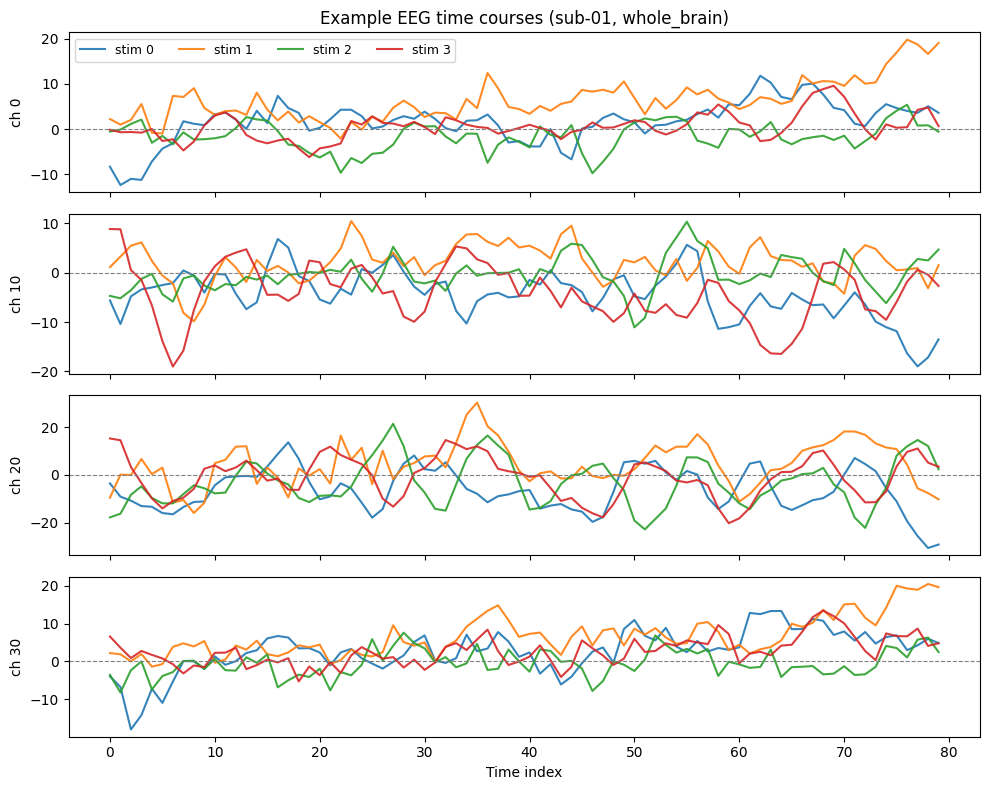

In [71]:
# TODO: plot example trace

# Example EEG time courses
example_stimuli = [0, 1, 2, 3]
example_channels = [0, 10, 20, 30]
#example_channels =[0,1,2] # if occipital, only 3 channels

fig, axes = plt.subplots(len(example_channels), 1, figsize=(10, 8), sharex=True)

for i, ch in enumerate(example_channels):
    ax = axes[i]
    for stim in example_stimuli:
        ax.plot(time_axis, X_train[stim, ch, :], label=f"stim {stim}", alpha=0.9)
    ax.set_ylabel(f"ch {ch}")
    ax.axhline(0, linestyle="--", linewidth=0.8, color="gray")
    if i == 0:
        ax.set_title(f"Example EEG time courses ({eeg_subject}, {eeg_roi})")

axes[-1].set_xlabel("Time index")
axes[0].legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

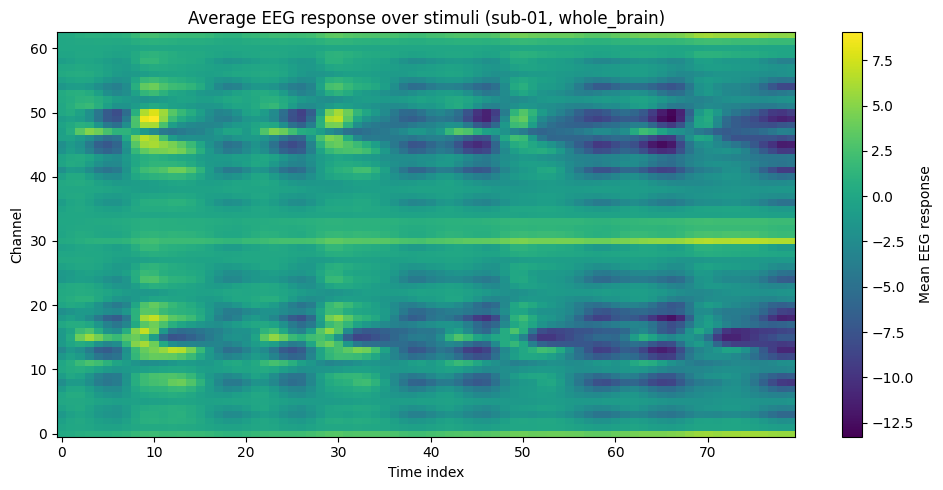

In [72]:
# TODO: plot channel x time heatmap
# Average response heatmap over channels x time
mean_response = X_train.mean(axis=0)   # average over stimuli -> channels x time

plt.figure(figsize=(10, 5))
plt.imshow(mean_response, aspect="auto", origin="lower")
plt.colorbar(label="Mean EEG response")
plt.xlabel("Time index")
plt.ylabel("Channel")
plt.title(f"Average EEG response over stimuli ({eeg_subject}, {eeg_roi})")
plt.tight_layout()
plt.show()

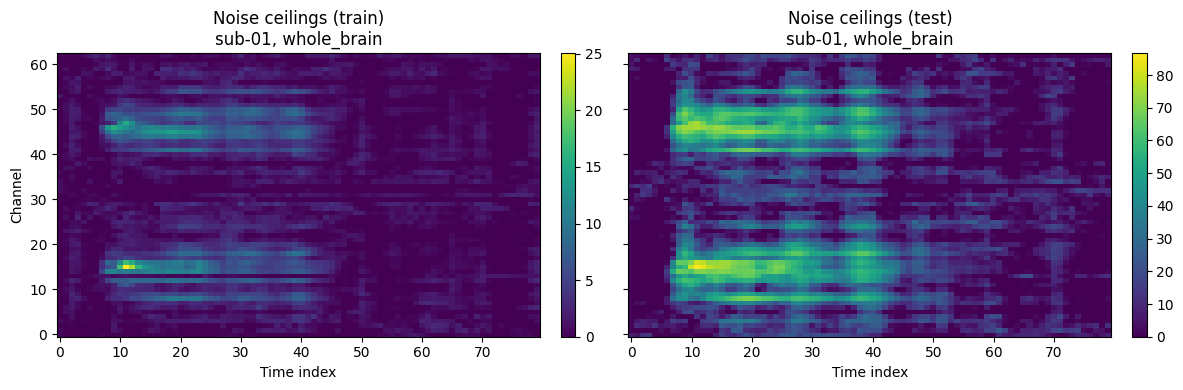

In [73]:
# TODO: visualize provided EEG noise ceilings
# Summary plot of provided EEG noise ceilings
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

im0 = axes[0].imshow(nc_train, aspect="auto", origin="lower")
axes[0].set_title(f"Noise ceilings (train)\n{eeg_subject}, {eeg_roi}")
axes[0].set_xlabel("Time index")
axes[0].set_ylabel("Channel")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(nc_test, aspect="auto", origin="lower")
axes[1].set_title(f"Noise ceilings (test)\n{eeg_subject}, {eeg_roi}")
axes[1].set_xlabel("Time index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.2</strong><br>Which time windows and channel groups appear most informative? Are the responses dominated by noise, or do you observe clear evoked structure?</div>


From the example EEG time courses, the signals are clearly not flat and vary across stimuli, channels, and time, which suggests that they are not dominated by pure noise.  
However, the individual stimulus traces remain quite variable, so the evoked structure is easier to see after averaging.

The average heatmap reveals clear spatio-temporal organization: some channel bands show stronger responses than others, some time windows exhibit larger amplitudes, and the overall pattern is not uniform across time.

The noise-ceiling maps further suggest that some parts of the signal are more informative and reliable than others. In particular, reliability varies across both time and channels, with stronger values appearing roughly between time indices 10 and 25 and in subsets of channels around 8–18 and 40–55 in both the train and test noise ceilings.


-> ajouter + de time windows et de channel groups more informative dans une phrase de conclusion + dire si on voit clear evoked structure

---

## 1.3 Estimate EEG noise ceilings using two methods

In practice, there are multiple ways to estimate noise ceilings, depending on the available data and the specific research question. When you have repeated measurements of the same stimulus, you can estimate reliability from the consistency of those repetitions. When repeated measurements are not available, reliability can instead be estimated across subjects, which often yields a more conservative ceiling.

In this part, you will implement two different estimators using the `things_eeg2-test_reps.h5` file, which contains the unaveraged test responses with repetitions.

You must implement **two different estimators** using `things_eeg2-test_reps.h5`. You can refer to the cited paper in each method's docstring for details.


### Required estimators

1. **Variance-based estimator**  
2. **Split-half reliability estimator**

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Implement both estimators.
- Compute both estimators for EEG2.
- Compare them to the provided EEG noise ceilings stored in `things_eeg2.h5`.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Working implementation of the variance-based estimator**
2. **Working implementation of the split-half estimator**
3. **One plot of mean noise ceiling over time**
4. **One plot of mean noise ceiling over channels**
5. **At least one channel × time heatmap for each estimator**
6. **At least one histogram comparing the value distributions**
7. **One direct visual comparison to the stored EEG noise ceilings**

### Starter functions

In [74]:
import numpy as np


def compute_ceiling_variancebased(responses: np.ndarray, nan_policy: str = 'omit') -> np.ndarray:
    """
    Noise ceiling per unit using the method described in the NSD paper
    (Allen et al., 2021 / 2022 style variance-based estimator).

    Steps:
      1) z-score across stimuli (axis=1) for each (unit, rep) -> total var ≈ 1
      2) estimate noise variance across repetitions (axis=2), then average across stimuli
      3) signal variance = 1 - noise_var
      4) reliability (percent) for finite repeats:
             nc = 100 * (snr / (snr + 1 / n_reps))

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
    nan_policy : {'propagate', 'raise', 'omit'}, default='omit'
        Passed to the z-scoring logic when handling NaNs.

    Returns
    -------
    np.ndarray
        Per-unit noise ceilings in percent with shape (n_units,) or
        (n_channels, n_timepoints), depending on your implementation.
    """

    ### TODO
    pass


def compute_ceiling_splithalf(
    responses: np.ndarray,
    folds: int = 10,
    seed: int = 0,
    spearman_brown: bool = True,
    equalize_halves: bool = True,
    clip_folds: bool = False
) -> np.ndarray:
    """
    Split-half reliability per unit (voxel / channel / channel*timepoint).
    You can refer to van Bree et al. (2025) for mathematical details.
    
    Steps:
      1) For each fold, randomly split repetitions into two halves.
      2) Average responses within each half and compute Pearson correlation across stimuli.
      3) Optionally apply Spearman-Brown correction to each fold's correlation.
      4) Average across folds to get a final reliability estimate.

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
        The last axis corresponds to repetitions / trials.
    folds : int, default=10
        Number of random split-halves to sample.
    seed : int, default=0
        Base RNG seed; each fold may use seed + fold_idx.
    spearman_brown : bool, default=True
        Apply Spearman-Brown correction:
            r_sb = 2r / (1 + r)
    equalize_halves : bool, default=True
        If True, use equal-sized halves and drop one trial if n_reps is odd.
        If False, the second half may be larger by one trial.
    clip_folds : bool, default=False
        If True, clip reliability values after correction.

    Returns
    -------
    np.ndarray
        Array of shape (n_units) or (n_channels, n_timepoints).
    """
    ### TODO
    pass

In [75]:
# TODO: load repeated EEG test responses
# TODO: compute variance-based estimator
# TODO: compute split-half estimator
# TODO: visualize and compare both estimators

In [76]:
import numpy as np


def compute_ceiling_variancebased(responses: np.ndarray, nan_policy: str = 'omit') -> np.ndarray:
    """
    Noise ceiling per unit using the method described in the NSD paper
    (Allen et al., 2021 / 2022 style variance-based estimator).

    Steps:
      1) z-score across stimuli (axis=1) for each (unit, rep) -> total var ≈ 1
      2) estimate noise variance across repetitions (axis=2), then average across stimuli
      3) signal variance = 1 - noise_var
      4) reliability (percent) for finite repeats:
             nc = 100 * (snr / (snr + 1 / n_reps))

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
    nan_policy : {'propagate', 'raise', 'omit'}, default='omit'
        Passed to the z-scoring logic when handling NaNs.

    Returns
    -------
    np.ndarray
        Per-unit noise ceilings in percent with shape (n_units,) or
        (n_channels, n_timepoints), depending on your implementation.
    """

    x = np.asarray(responses, dtype=np.float64)
    n_reps = x.shape[-1]

    # 1) z-score across stimuli for each unit and repetition
    mean = np.nanmean(x, axis=-2, keepdims=True)
    std = np.nanstd(x, axis=-2, ddof=1, keepdims=True)

    if nan_policy == "raise" and (np.isnan(x).any() or np.isnan(std).any()):
        raise ValueError("NaNs found in responses")

    std = np.where(std == 0, np.nan, std)
    z = (x - mean) / std

    # 2) noise variance: variance across repetitions, averaged over stimuli
    noise_var_per_stim = np.nanvar(z, axis=-1, ddof=1)     
    noise_var = np.nanmean(noise_var_per_stim, axis=-1)   

    # 3) signal variance
    signal_var = 1.0 - noise_var 
    signal_var = np.maximum(signal_var, 0.0)   # no negative -> zero instead

    # 4) reliability (percent) for finite repeats
    eps = 1e-12
    snr = signal_var / np.maximum(noise_var, eps)
    
    nc = 100.0 * (snr / (snr + 1.0 / n_reps))
    nc = np.clip(nc, 0.0, 100.0)      # necessary ??

    return nc


def compute_ceiling_splithalf(
    responses: np.ndarray,
    folds: int = 10,
    seed: int = 0,
    spearman_brown: bool = True,
    equalize_halves: bool = True,
    clip_folds: bool = False
) -> np.ndarray:
    """
    Split-half reliability per unit (voxel / channel / channel*timepoint).
    You can refer to van Bree et al. (2025) for mathematical details.
    
    Steps:
      1) For each fold, randomly split repetitions into two halves.
      2) Average responses within each half and compute Pearson correlation across stimuli.
      3) Optionally apply Spearman-Brown correction to each fold's correlation.
      4) Average across folds to get a final reliability estimate.

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
        The last axis corresponds to repetitions / trials.
    folds : int, default=10
        Number of random split-halves to sample.
    seed : int, default=0
        Base RNG seed; each fold may use seed + fold_idx.
    spearman_brown : bool, default=True
        Apply Spearman-Brown correction:
            r_sb = 2r / (1 + r)
    equalize_halves : bool, default=True
        If True, use equal-sized halves and drop one trial if n_reps is odd.
        If False, the second half may be larger by one trial.
    clip_folds : bool, default=False
        If True, clip reliability values after correction.

    Returns
    -------
    np.ndarray
        Array of shape (n_units) or (n_channels, n_timepoints).
    """
    x = np.asarray(responses, dtype=np.float64)
    
    unit_shape = x.shape[:-2]
    n_stim = x.shape[-2]
    n_reps = x.shape[-1]
    
    x_flat = x.reshape(-1, n_stim, n_reps)
    out = []

    # 1) For each fold, randomly split repetitions into two halves
    for fold in range(folds):
        rng = np.random.default_rng(seed + fold)
        perm = rng.permutation(n_reps)

        if equalize_halves:
            k = n_reps // 2
            idx1 = perm[:k]
            idx2 = perm[k:2*k]

        else:
            k = n_reps // 2
            idx1 = perm[:k]
            idx2 = perm[k:]

        # 2) Average responses within each half and compute Pearson correlation across stimuli.
        a = np.nanmean(x_flat[:, :, idx1], axis=-1)   # (n_units, n_stim)
        b = np.nanmean(x_flat[:, :, idx2], axis=-1)
        
        a = a - np.nanmean(a, axis=1, keepdims=True)
        b = b - np.nanmean(b, axis=1, keepdims=True)

        num = np.nansum(a * b, axis=1)
        den = np.sqrt(np.nansum(a * a, axis=1) * np.nansum(b * b, axis=1))

        r = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)

        # 3) Optionally apply Spearman-Brown correction to each fold's correlation.
        if spearman_brown:
            r = (2 * r) / (1 + r)

        if clip_folds:
            r = np.clip(r, 0.0, 1.0)

        out.append(r)

    # 4) Average across folds to get a final reliability estimate.
    rel = np.nanmean(np.stack(out, axis=0), axis=0)
    rel = rel.reshape(unit_shape)
    rel = 100.0 * rel

    return rel

In [77]:
def corr_ignore_nan(a, b):
    """
    compute the correlation between a and b ignoring the nans
    maybe not necessary, not sure if there are nans
    """
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan
    return np.corrcoef(a[mask], b[mask])[0, 1]

def prepare_eeg_reps_candidates(raw):
    """
    -> construct 2 versions possible of the same tensor, depending on 
    -> if (channel, time, stimulus, repetition) or the inverse (see after)
    raw is assumed to come from things_eeg2-test_reps.h5 for one subject and one ROI.
    We test two plausible layouts:
      A: (stimulus, channel, repetition, time) -> (channel, time, stimulus, repetition)
      B: (stimulus, channel, time, repetition) -> (channel, time, stimulus, repetition)
    """
    cand_A = np.transpose(raw, (1, 3, 0, 2))
    cand_B = np.transpose(raw, (1, 2, 0, 3))
    return {"stim-ch-rep-time": cand_A, 
            "stim-ch-time-rep": cand_B}

In [78]:
# Un noise ceiling est une estimation de la fiabilité maximale 
# qu’on peut espérer expliquer avec un modèle, 
# compte tenu du bruit dans les données neuronales.

# Dans EEG :
# un noise ceiling élevé sur un canal/temps veut dire que la réponse 
# y est assez stable et informative
# un noise ceiling faible veut dire que cette partie du signal est 
# surtout bruitée ou peu reproductible

# TODO: load repeated EEG test responses
eeg_subject = "sub-01"
eeg_roi = "whole_brain"

stored_nc = eeg2_h5[f"noise_ceilings/{eeg_subject}/{eeg_roi}"][:]            # (channels, time)
stored_nc_train = eeg2_h5[f"noise_ceilings_train/{eeg_subject}/{eeg_roi}"][:] # optional
reps_raw = eeg2_test_reps_h5[f"test/neural_data/{eeg_subject}/{eeg_roi}"][:]

print("Raw repeated EEG shape:", reps_raw.shape)
print("Stored test noise ceiling shape:", stored_nc.shape)

# comme on sait pas si (200, 63, 80, 80) c'est la forme 
# (stimulus, channel, time, repetition) ou (stimulus, channel, repetition, time) (voir q3 doc)
# alors il faut faire des tests pas jolis dans le cellule d'après....

# The main EEG dataset has shape (stimulus, channel, time).
# The repeated-test EEG file adds one repetition axis, but since both the
# time axis and the repetition axis have size 80, we verify which ordering
# is consistent with the stored noise ceilings.

Raw repeated EEG shape: (200, 63, 80, 80)
Stored test noise ceiling shape: (63, 80)


In [79]:
# Try both plausible axis layouts
candidates = prepare_eeg_reps_candidates(reps_raw)
candidate_results = {}

for name, arr in candidates.items():
    # TODO: compute variance-based estimator
    vb = compute_ceiling_variancebased(arr)

    # TODO: compute split-half estimator
    sh = compute_ceiling_splithalf(
        arr,
        folds=10,
        seed=0,
        spearman_brown=True,
        equalize_halves=True,
        clip_folds=False
    )

    corr_vb = corr_ignore_nan(vb, stored_nc)
    corr_sh = corr_ignore_nan(sh, stored_nc)
    score = np.nanmean([corr_vb, corr_sh])

    candidate_results[name] = {
        "responses": arr,
        "variancebased": vb,
        "splithalf": sh,
        "corr_vb_vs_stored": corr_vb,
        "corr_sh_vs_stored": corr_sh,
        "mean_score": score,
    }

best_name = max(candidate_results, key=lambda k: candidate_results[k]["mean_score"])
best = candidate_results[best_name]

responses_eeg = best["responses"]   # (channels, time, stimuli, reps)
nc_var = best["variancebased"]      # (channels, time)
nc_split = best["splithalf"]        # (channels, time)

print(f"Chosen axis interpretation: {best_name}")
print("Correlation variance-based vs stored:", best["corr_vb_vs_stored"])
print("Correlation split-half vs stored:", best["corr_sh_vs_stored"])

# -------------------------
# Time axis in seconds
# EEG: 80 time points at 100 Hz from 0.0 to 0.8 s
# -------------------------
n_time = stored_nc.shape[1]
time_s = np.arange(n_time) / 100.0

Chosen axis interpretation: stim-ch-time-rep
Correlation variance-based vs stored: 0.9835951559494392
Correlation split-half vs stored: 0.9220454305355926


In [ ]:
# TODO: visualize and compare both estimators

# -------------------------
# 1) Plot mean noise ceiling over time
# -------------------------
mean_time_var = np.nanmean(nc_var, axis=0)
mean_time_split = np.nanmean(nc_split, axis=0)
mean_time_stored = np.nanmean(stored_nc, axis=0)

plt.figure(figsize=(10, 4))
plt.plot(mean_time_var, label="Variance-based")
plt.plot(mean_time_split, label="Split-half")
plt.plot(mean_time_stored, label="Stored EEG noise ceiling")
plt.xlabel("Time index")
plt.ylabel("Mean noise ceiling")
plt.title(f"Mean EEG noise ceiling over time ({eeg_subject}, {eeg_roi})")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# 2) Plot mean noise ceiling over channels
# -------------------------
mean_chan_var = np.nanmean(nc_var, axis=1)
mean_chan_split = np.nanmean(nc_split, axis=1)
mean_chan_stored = np.nanmean(stored_nc, axis=1)

plt.figure(figsize=(10, 4))
plt.plot(mean_chan_var, label="Variance-based")
plt.plot(mean_chan_split, label="Split-half")
plt.plot(mean_chan_stored, label="Stored EEG noise ceiling")
plt.xlabel("Channel")
plt.ylabel("Mean noise ceiling")
plt.title(f"Mean EEG noise ceiling over channels ({eeg_subject}, {eeg_roi})")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# 3) Heatmaps: one for each estimator + stored ceiling
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

im0 = axes[0].imshow(nc_var, aspect="auto", origin="lower")
axes[0].set_title("Variance-based")
axes[0].set_xlabel("Time index")
axes[0].set_ylabel("Channel")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(nc_split, aspect="auto", origin="lower")
axes[1].set_title("Split-half")
axes[1].set_xlabel("Time index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(stored_nc, aspect="auto", origin="lower")
axes[2].set_title("Stored EEG noise ceiling")
axes[2].set_xlabel("Time index")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f"EEG noise ceiling comparison ({eeg_subject}, {eeg_roi})")
plt.tight_layout()
plt.show()

# -------------------------
# 4) Histogram comparing distributions
# -------------------------
plt.figure(figsize=(8, 5))
plt.hist(nc_var.ravel(), bins=50, alpha=0.5, label="Variance-based")
plt.hist(nc_split.ravel(), bins=50, alpha=0.5, label="Split-half")
plt.hist(stored_nc.ravel(), bins=50, alpha=0.5, label="Stored EEG noise ceiling")
plt.xlabel("Noise ceiling value")
plt.ylabel("Count")
plt.title(f"Distribution comparison ({eeg_subject}, {eeg_roi})")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# 5) Optional direct difference maps
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

im0 = axes[0].imshow(nc_var - stored_nc, aspect="auto", origin="lower")
axes[0].set_title("Variance-based - stored")
axes[0].set_xlabel("Time index")
axes[0].set_ylabel("Channel")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(nc_split - stored_nc, aspect="auto", origin="lower")
axes[1].set_title("Split-half - stored")
axes[1].set_xlabel("Time index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle(f"Difference maps ({eeg_subject}, {eeg_roi})")
plt.tight_layout()
plt.show()

# -------------------------
# 6) Simple numeric summary
# -------------------------
def summarize_map(name, arr, ref):
    mask = np.isfinite(arr) & np.isfinite(ref)
    mae = np.mean(np.abs(arr[mask] - ref[mask]))
    corr = np.corrcoef(arr[mask].ravel(), ref[mask].ravel())[0, 1]
    print(f"{name:20s} | mean={np.nanmean(arr):8.3f} | std={np.nanstd(arr):8.3f} | corr_with_stored={corr:8.3f} | MAE={mae:8.3f}")

summarize_map("Variance-based", nc_var, stored_nc)
summarize_map("Split-half", nc_split, stored_nc)
summarize_map("Stored", stored_nc, stored_nc)

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.3</strong><br>Compare the two estimators. Do they produce similar patterns across channels and time? Where do they differ most?</div>

---

## 1.4 Compare the noise ceiling estimators statistically on EEG2

In `things_eeg2.h5`, we provided noise ceilings computed using one of the two methods you implemented. Can you determine which one it is by comparing the stored ceilings to your computed ones?

Perform a hypothesis test to compare the stored ceilings to each of your computed estimators. For example, you could compute the mean squared error between the stored ceilings and each estimator per subject/time/channel, and then use a paired t-test to see if one estimator is significantly closer to the stored values than the other.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- State clearly what each estimator assumes.
- Define a quantitative comparison to the stored EEG noise ceilings.
- Run at least one simple statistical test or formal comparison.

Examples:

- mean absolute deviation from the stored values,
- paired comparison across channel × time units,
- correlation with the stored values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One quantitative comparison table** comparing both estimators to the stored EEG noise ceilings.
2. **One statistical test or one formal quantitative comparison** such as a paired test, correlation analysis, or mean absolute deviation analysis.
3. **One concise written conclusion** stating which estimator better matches the stored values and why.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.4</strong><br>Which estimator is more likely to have been used to generate the stored EEG noise ceilings? Justify your answer with both visual and quantitative evidence.</div>

In [ ]:
# TODO: define estimator comparison metric
# TODO: run statistical comparison
# TODO: summarize which estimator best matches stored values

---

## 1.5 Convert NSD ncsnr to noise ceiling and visualize it on cortex

Some datasets, such as NSD, provide reliability estimates with the data release. In this section, you will visualize the provided NSD reliability estimates on the cortical surface and convert them into noise ceilings for later use in predictive analyses.

The provided NSD reliability estimates are stored as **ncsnr** values on the fsaverage surface. To use them as noise ceilings for voxel-wise analyses, you need to convert ncsnr to noise ceiling using the formula provided in the NSD methods paper.

Parcellations and atlases provide group-level anatomical labels for brain regions. They are often defined on a standard surface or volume space (e.g., fsaverage, MNI) and can be used to summarize or interpret neural data. For this exercise, use the Destrieux atlas to anatomically label the regions with the highest and lowest noise ceilings. It is available in fsaverage space and can be accessed through `nilearn`. Compute the average noise ceiling within each atlas region and identify which regions have the highest and lowest reliability.

If the available atlas is in a different surface resolution (e.g. `fsaverage5`), you can interpolate either the atlas or the noise ceiling map to the same space before visualization. Prefer downsampling rather than upsampling to avoid introducing artificial precision.

You can use `nibabel` to load the `.mgh` files and `nilearn` to visualize the resulting noise ceiling on the fsaverage surface.


<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Load the provided `.mgh` files for subject 01.
- Convert **ncsnr** to a **noise ceiling estimate** using the formula described in the NSD paper.
- Visualize the resulting noise ceiling on the fsaverage surface.
- Overlay a cortical parcellation.
- Compute parcel-wise average values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One histogram of ncsnr values**
2. **One cortical surface plot** of ncsnr or the derived noise ceiling
3. **One cortical surface plot with parcel overlay**
4. **One parcel-wise summary figure or one parcel-wise summary table**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.5</strong><br>Which cortical regions appear most reliable, and which appear least reliable? Explain how the parcellation helps interpret the surface maps.</div>

In [ ]:
# TODO: load lh/rh ncsnr maps
# TODO: convert ncsnr to noise ceiling
# TODO: plot histogram
# TODO: visualize on fsaverage
# TODO: compute parcel-wise summary

---

# 2. Brain–Model Alignment

In this section, you will compare neural responses and model features using **both representational metrics and predictive linear models**. You must complete both parts of this section. The goal is not only to report scores, but also to compare what different metrics reveal about model–brain alignment.

## 2.1 Representational alignment: RSA

RSA stands for representational similarity analysis. It is one of the most widely used analyses in fMRI and model–brain alignment research. It compares the geometry of two representational spaces through their representational dissimilarity matrices (RDMs). Given two response matrices, `X` and `Y`, with rows corresponding to the same stimuli, we first compute an RDM for each matrix using correlation distance:

$$
D^X_{ij} = 1 - \mathrm{corr}(X[i,:], X[j,:]),
\qquad
D^Y_{ij} = 1 - \mathrm{corr}(Y[i,:], Y[j,:]),
$$

for stimulus pairs $i \neq j$.

We then vectorize the upper triangle of each RDM and compute RSA as the Spearman correlation between these two vectors:

$$
\mathrm{RSA}(X, Y)
=
\rho_{\mathrm{Spearman}}
\left(
\mathrm{vec}(D^X),\,
\mathrm{vec}(D^Y)
\right).
$$

In this project, `X` will usually denote model features from one candidate layer, and `Y` will denote neural responses from one dataset, ROI, subject, or time slice, depending on the analysis.

- Implement RSA between two representation matrices.
- Support at least one dissimilarity measure and one similarity measure.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [82]:
from typing import Literal
import numpy as np
from scipy import stats
from scipy.spatial.distance import pdist, squareform

class RepresentationalSimilarityAnalysis:
    """
    Representational Similarity Analysis (RSA).

    Given two representation matrices X and Y with the same number of conditions
    (rows), RSA:

    1. Computes a Representational Dissimilarity Matrix (RDM) for each:
       RDM_X[i, j] = dissimilarity(x_i, x_j)
       RDM_Y[i, j] = dissimilarity(y_i, y_j)

    2. Flattens the upper triangles of both RDMs and computes a correlation
       between them (Pearson or Spearman).
    """

    def __init__(
        self,
        dissimilarity: Literal["correlation", "euclidean", "cosine"] = "correlation",
        similarity_metric: Literal["pearson", "spearman"] = "spearman",
    ):
        assert dissimilarity in ("correlation", "euclidean", "cosine"), \
            f"Unknown dissimilarity: {dissimilarity}"
        assert similarity_metric in ("pearson", "spearman"), \
            f"Unknown similarity_metric: {similarity_metric}"
        self.dissimilarity = dissimilarity
        self.similarity_metric = similarity_metric

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Compute RSA similarity between X and Y.

        Parameters
        ----------
        X, Y : np.ndarray
            Arrays of shape (n_conditions, ...) that may need to be flattened
            along feature dimensions.

        Returns
        -------
        rsa_similarity : float
            Correlation between the vectorized upper triangles of the two RDMs.
        """
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Compute RSA similarity between X and Y.
    
        Steps:
          1) Flatten X and Y to (n_conditions, n_features).
          2) Compute one RDM per matrix using the chosen dissimilarity.
          3) Extract upper triangles and correlate them using the chosen
             similarity metric (Pearson or Spearman).
    
        Parameters
        ----------
        X : np.ndarray
            Array of shape (n_conditions, ...).
        Y : np.ndarray
            Array of shape (n_conditions, ...).
    
        Returns
        -------
        float
            RSA similarity score between X and Y.
        """
        # Flatten feature dimensions if needed: (n_conditions, ...)
        X = np.asarray(X, dtype=np.float64).reshape(X.shape[0], -1)
        Y = np.asarray(Y, dtype=np.float64).reshape(Y.shape[0], -1)

        if X.shape[0] != Y.shape[0]:
            raise ValueError(
                f"X and Y must have the same number of conditions: "
                f"{X.shape[0]} vs {Y.shape[0]}"
            )

        rdm_x = self.compute_rdm(X)
        rdm_y = self.compute_rdm(Y)
        return self.compare_rdms(rdm_x, rdm_y)

    def compute_rdm(self, X: np.ndarray) -> np.ndarray:
        """
        Compute the Representational Dissimilarity Matrix (RDM)
        for a given representation matrix X.

        Parameters
        ----------
        X : np.ndarray
            Array of shape (n_conditions, n_features).

        Returns
        -------
        rdm : np.ndarray
            Array of shape (n_conditions, n_conditions) with pairwise dissimilarities.
        """
        X = np.asarray(X, dtype=np.float64).reshape(X.shape[0], -1)

        # pdist returns the condensed upper-triangle distances
        distances = pdist(X, metric=self.dissimilarity)
        return squareform(distances)

    def compare_rdms(self, rdm1: np.ndarray, rdm2: np.ndarray) -> float:
        """
        Compare two RDMs by correlating their upper triangles.
        """
        n = rdm1.shape[0]
        # Extract upper triangle indices (excluding diagonal)
        idx = np.triu_indices(n, k=1)
        vec1 = rdm1[idx]
        vec2 = rdm2[idx]

        # Remove any NaNs
        mask = np.isfinite(vec1) & np.isfinite(vec2)
        vec1, vec2 = vec1[mask], vec2[mask]

        if len(vec1) < 3:
            return np.nan

        if self.similarity_metric == "spearman":
            r, _ = stats.spearmanr(vec1, vec2)
        else:
            r, _ = stats.pearsonr(vec1, vec2)

        return float(r)

In [83]:
# Quick RSA test
rsa = RepresentationalSimilarityAnalysis(
    dissimilarity="correlation",
    similarity_metric="spearman"
)

X = np.random.randn(20, 50)
Y = X + 0.1 * np.random.randn(20, 50)

score = rsa(X, Y)
print("RSA score:", score)

RSA score: 0.9916037913282333


## 2.2 Representational alignment: unbiased linear CKA

CKA stands for centered kernel alignment. It is commonly used in interpretability and representation analysis to test how strongly the internal computations of two systems align. As a second mapping-free alignment metric, we want to compute unbiased linear centered kernel alignment (CKA) between model features and neural responses. Let

$$
X \in \mathbb{R}^{n \times d}, \qquad
Y \in \mathbb{R}^{n \times p},
$$

where both matrices are measured on the same $n$ stimuli. We form linear Gram matrices

$$
K = XX^\top,
\qquad
L = YY^\top.
$$

We then estimate dependence using the unbiased (U-statistic) HSIC estimator, $\mathrm{HSIC}_u(K, L)$, and define CKA as

$$
\mathrm{CKA}(X, Y)
=
\frac{\mathrm{HSIC}_u(K, L)}
{\sqrt{\mathrm{HSIC}_u(K, K)\,\mathrm{HSIC}_u(L, L)}}.
$$

Like RSA, CKA compares representational structure directly without fitting a predictive mapping. In this notebook, `X` and `Y` again refer to aligned model and neural response matrices evaluated on the same set of stimuli.

- Implement **unbiased linear CKA** only.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [84]:
import numpy as np

class CenteredKernelAlignment:
    """
    Unbiased linear CKA only.

    Parameters
    ----------
    eps : float
        Small constant for numerical stability.
    dtype : np.dtype
        Data type used for computations.
    """

    def __init__(
        self,
        eps: float = 1e-8,
        dtype: np.dtype = np.float64,
    ):
        self.eps = eps
        self.dtype = dtype

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        X = np.asarray(X).astype(self.dtype)
        Y = np.asarray(Y).astype(self.dtype)

        if X.shape[0] != Y.shape[0]:
            raise ValueError(
                f"Batch sizes must match along axis 0: {X.shape[0]} vs {Y.shape[0]}"
            )

        # Flatten to (n_samples, n_features)
        X = X.reshape(X.shape[0], -1)
        Y = Y.reshape(Y.shape[0], -1)

        return self._unbiased_linear_cka(X, Y)

    def _unbiased_linear_hsic(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased HSIC estimator for the linear kernel.

        X : [n, d_x]
        Y : [n, d_y]
        """
        n = X.shape[0]

        K = X @ X.T
        L = Y @ Y.T

        # Zero out diagonals to remove self-similarity bias
        np.fill_diagonal(K, 0.0)
        np.fill_diagonal(L, 0.0)

        KL = K @ L
        hsic = (
            np.trace(KL)
            + K.sum() * L.sum() / ((n - 1) * (n - 2))
            - 2.0 * KL.sum() / (n - 2)
        ) / (n * (n - 3))

        return float(hsic)

    def _unbiased_linear_cka(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased linear CKA:

            CKA_unb(X, Y) =
                HSIC_unb(X, Y) / sqrt(HSIC_unb(X, X) * HSIC_unb(Y, Y))
        """
        hsic_xy = self._unbiased_linear_hsic(X, Y)
        hsic_xx = self._unbiased_linear_hsic(X, X)
        hsic_yy = self._unbiased_linear_hsic(Y, Y)

        denom = np.sqrt(hsic_xx * hsic_yy)

        if denom < self.eps:
            return float("nan")

        return float(hsic_xy / denom)

In [85]:
# Quick CKA test
cka = CenteredKernelAlignment()

X = np.random.randn(30, 50)
Y = X + 0.1 * np.random.randn(30, 50)
Z = np.random.randn(30, 50)

print("CKA(X, Y):", cka(X, Y))
print("CKA(X, Z):", cka(X, Z))

CKA(X, Y): 0.9890165703860083
CKA(X, Z): -0.026462181142983255


## 2.3 Apply RSA and CKA

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Compare layers within each model.
- Compare the two models.
- For EEG, show how representational similarity changes over time.
- For TVSD and NSD, compare across ROIs.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Layer-wise RSA results** for both models.
2. **Layer-wise CKA results** for both models.
3. **One direct comparison between the two models** using representational metrics.
4. **One EEG time-resolved analysis** or **one ROI-wise analysis** for TVSD/NSD.
5. **One short written interpretation** in Answer box 2.1.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.1</strong><br>Do RSA and CKA tell the same story? Identify at least one case where they agree and one case where they disagree, and explain what that might mean.</div>

In [86]:
# TODO: implement RSA
# TODO: implement unbiased linear CKA
# TODO: compute scores across layers
# TODO: compare across models and ROIs / time windows

In [87]:
# TODO: implement RSA
rsa_metric = RepresentationalSimilarityAnalysis(
    dissimilarity="correlation",
    similarity_metric="spearman",
)

# TODO: implement unbiased linear CKA
cka_metric = CenteredKernelAlignment(
    eps=1e-8,
    dtype=np.float64,
)

In [88]:
# TODO: compute scores across layers

# Helper functions
def get_feature_layers(feature_file_path):
    """
    Return all layer dataset names from one feature file.
    """
    with h5py.File(feature_file_path, "r") as f:
        ids = f["ids"][:]
        n_ids = len(ids)
        layers = []

        def walk(name, obj):
            if isinstance(obj, h5py.Dataset):
                if name == "ids":
                    return
                if obj.ndim == 2 and obj.shape[0] == n_ids:
                    layers.append(name)

        f.visititems(walk)

    return sorted(layers)


def build_id_index(ids):
    return {k: i for i, k in enumerate(ids)}


def load_layer_subset(feature_file_path, target_ids, layer_names):
    """
    Load features for the requested stimulus IDs only.

    Returns
    -------
    dict
        layer_name -> array of shape (n_stimuli, n_features)
    """
    with h5py.File(feature_file_path, "r") as f:
        feature_ids = f["ids"][:]
        idx_map = build_id_index(feature_ids)

        # Indices in the order requested by target_ids
        idx = np.array([idx_map[sid] for sid in target_ids], dtype=int)

        # h5py requires sorted indices
        sort_order = np.argsort(idx)
        idx_sorted = idx[sort_order]

        # Inverse permutation to restore original order
        undo_sort = np.argsort(sort_order)

        out = {}
        for layer in layer_names:
            arr_sorted = f[layer][idx_sorted]
            out[layer] = arr_sorted[undo_sort]

    return out

def safe_metric(fn, X, Y):
    try:
        return fn(X, Y)
    except Exception:
        return np.nan

In [89]:
# Model files
resnet_name = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
qwen_name = "Qwen3-VL-2B-Instruct"

resnet_things_path = model_specs[resnet_name]["things"]
qwen_things_path = model_specs[qwen_name]["things"]

resnet_layers = get_feature_layers(resnet_things_path)
qwen_layers = get_feature_layers(qwen_things_path)

print("ResNet layers:", resnet_layers)
print("Qwen layers:", qwen_layers)

ResNet layers: ['features/layer1-0', 'features/layer2-0', 'features/layer3-0', 'features/layer3-10', 'features/layer3-15', 'features/layer3-20', 'features/layer3-25', 'features/layer3-30', 'features/layer3-5', 'features/layer4-1']
Qwen layers: ['features/language_model-layers-11', 'features/language_model-layers-16', 'features/language_model-layers-3', 'features/language_model-layers-8', 'features/visual-blocks-10', 'features/visual-blocks-14', 'features/visual-blocks-18', 'features/visual-blocks-2', 'features/visual-blocks-22', 'features/visual-blocks-6']


,dataset,subject,roi,model,layer,RSA,CKA
0,TVSD,monkeyF,V1,ResNet152_adv,features/layer1-0,0.107959,0.331148
1,TVSD,monkeyF,V1,ResNet152_adv,features/layer2-0,0.189209,0.347218
2,TVSD,monkeyF,V1,ResNet152_adv,features/layer3-0,0.197675,0.315858
3,TVSD,monkeyF,V1,ResNet152_adv,features/layer3-10,0.094924,0.161933
4,TVSD,monkeyF,V1,ResNet152_adv,features/layer3-15,0.070352,0.138361


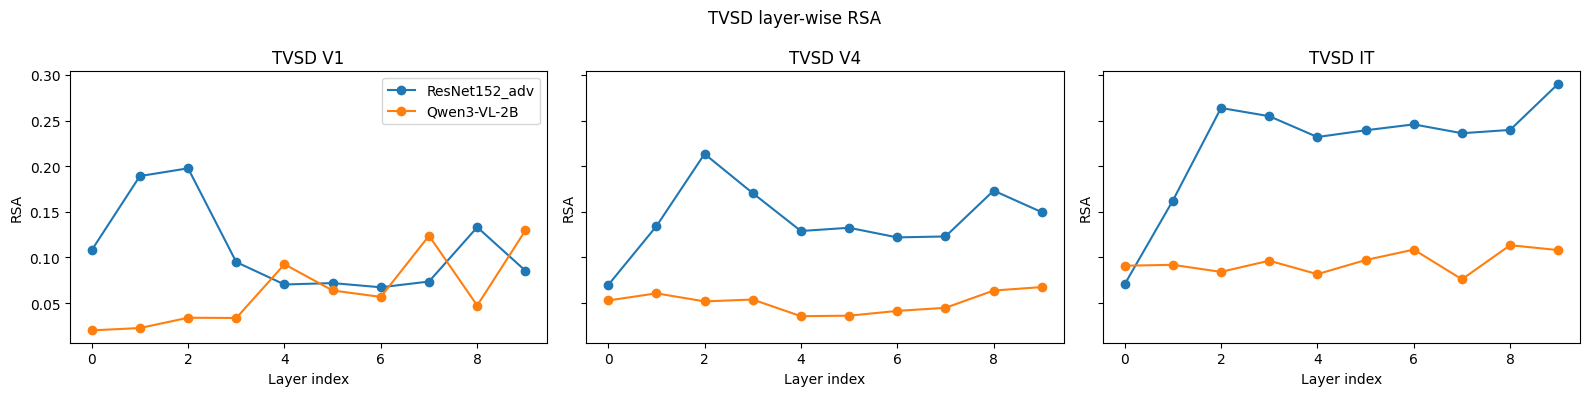

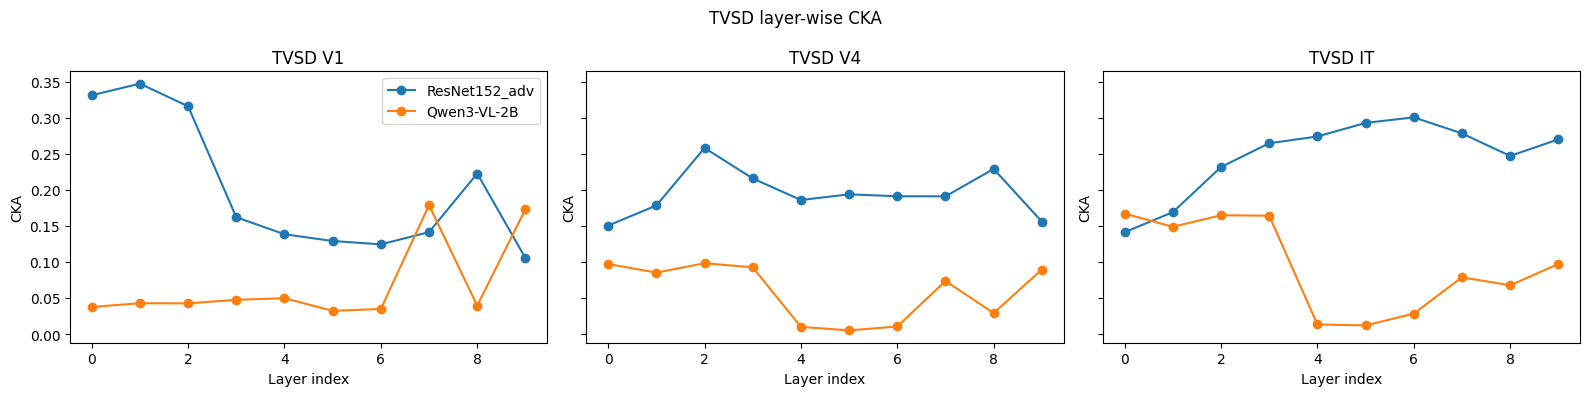

,model,roi,RSA,CKA
0,Qwen3-VL-2B,IT,0.113419,0.167071
3,ResNet152_adv,IT,0.290472,0.300511
1,Qwen3-VL-2B,V1,0.129551,0.178757
4,ResNet152_adv,V1,0.197675,0.347218
2,Qwen3-VL-2B,V4,0.067519,0.098150
5,ResNet152_adv,V4,0.213488,0.258056


In [35]:
# =========================================================
# A) TVSD ROI-wise analysis
# =========================================================

tvsd_subject = "monkeyF"
tvsd_rois = ["V1", "V4", "IT"]

tvsd_test_ids = tvsd_h5["test/stimulus_ids"][:]

# Neural data: one ROI at a time, shape (n_stimuli, n_units)
tvsd_neural = {
    roi: tvsd_h5[f"test/neural_data/{tvsd_subject}/{roi}"][:]
    for roi in tvsd_rois
}

# Load aligned model features for the TVSD test stimuli
resnet_tvsd_feats = load_layer_subset(resnet_things_path, tvsd_test_ids, resnet_layers)
qwen_tvsd_feats   = load_layer_subset(qwen_things_path,   tvsd_test_ids, qwen_layers)

rows_tvsd = []

for roi in tvsd_rois:
    Y = tvsd_neural[roi]

    for layer in resnet_layers:
        X = resnet_tvsd_feats[layer]
        rows_tvsd.append({
            "dataset": "TVSD",
            "subject": tvsd_subject,
            "roi": roi,
            "model": "ResNet152_adv",
            "layer": layer,
            "RSA": safe_metric(rsa_metric, X, Y),
            "CKA": safe_metric(cka_metric, X, Y),
        })

    for layer in qwen_layers:
        X = qwen_tvsd_feats[layer]
        rows_tvsd.append({
            "dataset": "TVSD",
            "subject": tvsd_subject,
            "roi": roi,
            "model": "Qwen3-VL-2B",
            "layer": layer,
            "RSA": safe_metric(rsa_metric, X, Y),
            "CKA": safe_metric(cka_metric, X, Y),
        })

df_tvsd = pd.DataFrame(rows_tvsd)
display(df_tvsd.head())


# Layer-wise TVSD plots
for metric in ["RSA", "CKA"]:
    fig, axes = plt.subplots(1, len(tvsd_rois), figsize=(16, 4), sharey=True)

    for ax, roi in zip(axes, tvsd_rois):
        sub = df_tvsd[df_tvsd["roi"] == roi]

        res = sub[sub["model"] == "ResNet152_adv"].reset_index(drop=True)
        qwe = sub[sub["model"] == "Qwen3-VL-2B"].reset_index(drop=True)

        ax.plot(np.arange(len(res)), res[metric], marker="o", label="ResNet152_adv")
        ax.plot(np.arange(len(qwe)), qwe[metric], marker="o", label="Qwen3-VL-2B")

        ax.set_title(f"TVSD {roi}")
        ax.set_xlabel("Layer index")
        ax.set_ylabel(metric)

    axes[0].legend()
    plt.suptitle(f"TVSD layer-wise {metric}")
    plt.tight_layout()
    plt.show()

# TVSD compact summary
tvsd_summary = (
    df_tvsd.groupby(["model", "roi"], as_index=False)[["RSA", "CKA"]]
    .max()
    .sort_values(["roi", "model"])
)
display(tvsd_summary)

,dataset,subject,roi,time_idx,time_s,model,layer,RSA,CKA
0,EEG2,sub-01,whole_brain,0,0.0,ResNet152_adv,features/layer1-0,0.049546,0.002274
1,EEG2,sub-01,whole_brain,0,0.0,ResNet152_adv,features/layer2-0,0.045083,0.003360
2,EEG2,sub-01,whole_brain,0,0.0,ResNet152_adv,features/layer3-0,0.040082,0.006118
3,EEG2,sub-01,whole_brain,0,0.0,ResNet152_adv,features/layer3-10,0.036737,0.002964
4,EEG2,sub-01,whole_brain,0,0.0,ResNet152_adv,features/layer3-15,0.028753,0.001095


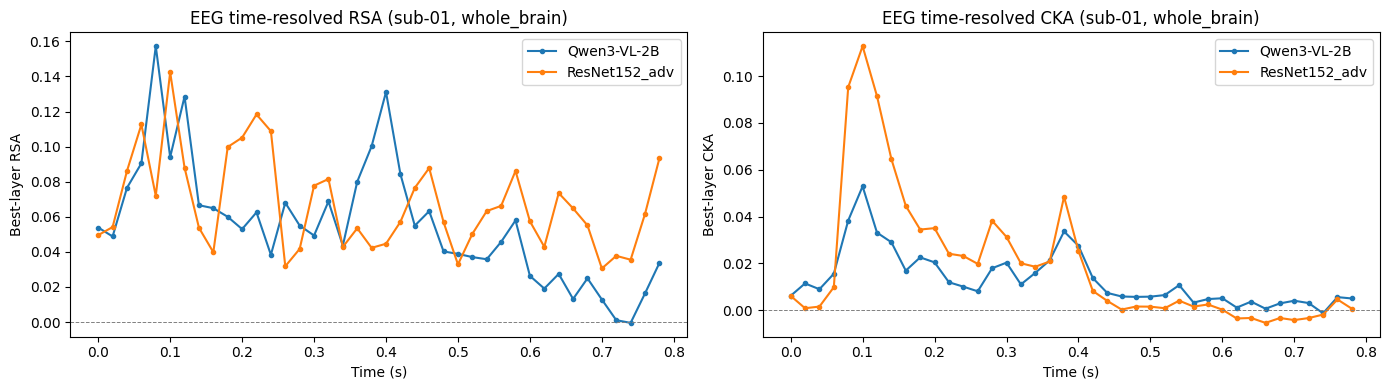

In [38]:
# =========================================================
# B) EEG time-resolved analysis (faster version)
# =========================================================

eeg_subject = "sub-01"
eeg_roi = "whole_brain"

eeg_test_ids = eeg2_h5["test/stimulus_ids"][:]
eeg_test = eeg2_h5[f"test/neural_data/{eeg_subject}/{eeg_roi}"][:]   # (stimuli, channels, time)

resnet_eeg_feats = load_layer_subset(resnet_things_path, eeg_test_ids, resnet_layers)
qwen_eeg_feats   = load_layer_subset(qwen_things_path,   eeg_test_ids, qwen_layers)

n_time = eeg_test.shape[2]
time_s = np.arange(n_time) / 100.0

# Use fewer time points to keep runtime reasonable -> can change to 8, 12, ...
time_indices = np.arange(0, n_time, 2)

# Precompute model RDMs once
resnet_eeg_rdms = {
    layer: rsa_metric.compute_rdm(resnet_eeg_feats[layer])
    for layer in resnet_layers
}

qwen_eeg_rdms = {
    layer: rsa_metric.compute_rdm(qwen_eeg_feats[layer])
    for layer in qwen_layers
}

rows_eeg = []

for t in time_indices:
    Y_t = eeg_test[:, :, t]   # (stimuli, channels)

    # Precompute neural RDM once for this time point
    Y_rdm = rsa_metric.compute_rdm(Y_t)

    for layer in resnet_layers:
        X = resnet_eeg_feats[layer]
        rsa_score = rsa_metric.compare_rdms(resnet_eeg_rdms[layer], Y_rdm)
        cka_score = safe_metric(cka_metric, X, Y_t)

        rows_eeg.append({
            "dataset": "EEG2",
            "subject": eeg_subject,
            "roi": eeg_roi,
            "time_idx": t,
            "time_s": time_s[t],
            "model": "ResNet152_adv",
            "layer": layer,
            "RSA": rsa_score,
            "CKA": cka_score,
        })

    for layer in qwen_layers:
        X = qwen_eeg_feats[layer]
        rsa_score = rsa_metric.compare_rdms(qwen_eeg_rdms[layer], Y_rdm)
        cka_score = safe_metric(cka_metric, X, Y_t)

        rows_eeg.append({
            "dataset": "EEG2",
            "subject": eeg_subject,
            "roi": eeg_roi,
            "time_idx": t,
            "time_s": time_s[t],
            "model": "Qwen3-VL-2B",
            "layer": layer,
            "RSA": rsa_score,
            "CKA": cka_score,
        })

df_eeg = pd.DataFrame(rows_eeg)
display(df_eeg.head())

# Best layer per model at each time point
best_eeg_rsa = df_eeg.groupby(["model", "time_s"], as_index=False)["RSA"].max()
best_eeg_cka = df_eeg.groupby(["model", "time_s"], as_index=False)["CKA"].max()

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for model in best_eeg_rsa["model"].unique():
    sub = best_eeg_rsa[best_eeg_rsa["model"] == model]
    axes[0].plot(sub["time_s"], sub["RSA"], marker="o", markersize=3, label=model)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Best-layer RSA")
axes[0].set_title(f"EEG time-resolved RSA ({eeg_subject}, {eeg_roi})")
axes[0].axhline(0, linestyle="--", linewidth=0.7, color="gray")
axes[0].legend()

for model in best_eeg_cka["model"].unique():
    sub = best_eeg_cka[best_eeg_cka["model"] == model]
    axes[1].plot(sub["time_s"], sub["CKA"], marker="o", markersize=3, label=model)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Best-layer CKA")
axes[1].set_title(f"EEG time-resolved CKA ({eeg_subject}, {eeg_roi})")
axes[1].axhline(0, linestyle="--", linewidth=0.7, color="gray")
axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:
# =========================================================
# C) NSD ROI-wise analysis
# =========================================================
nsd_subject  = "subj01"
nsd_key_rois = ["early", "midventral", "ventral", "whole_brain"]
nsd_test_ids = nsd_rois_h5["test/stimulus_ids/subj01"][:]

nsd_neural = {
    roi: nsd_rois_h5[f"test/neural_data/{nsd_subject}/{roi}"][:]
    for roi in nsd_key_rois
}

resnet_nsd_path   = model_specs[resnet_name]["nsd"]
qwen_nsd_path     = model_specs[qwen_name]["nsd"]
resnet_nsd_layers = get_feature_layers(resnet_nsd_path)
qwen_nsd_layers   = get_feature_layers(qwen_nsd_path)

print("ResNet NSD layers:", resnet_nsd_layers)
print("Qwen NSD layers:",   qwen_nsd_layers)

resnet_nsd_feats = load_layer_subset(resnet_nsd_path, nsd_test_ids, resnet_nsd_layers)
qwen_nsd_feats   = load_layer_subset(qwen_nsd_path,   nsd_test_ids, qwen_nsd_layers)

# Speedup 1: PCA-reduce features once per layer
# Justified: RSA uses correlation distance which is invariant to linear
# transformations; CKA with linear kernel is largely preserved under PCA.
# 300 components from 30,000 dimensions captures >99% of variance.
from sklearn.decomposition import PCA

def pca_reduce(X, n_components=300):
    if X.shape[1] <= n_components:
        return X
    return PCA(n_components=n_components, random_state=0).fit_transform(X)

resnet_nsd_feats_pca = {
    layer: pca_reduce(X) for layer, X in resnet_nsd_feats.items()
}
qwen_nsd_feats_pca = {
    layer: pca_reduce(X) for layer, X in qwen_nsd_feats.items()
}

# Speedup 2: precompute model RDMs once per layer
resnet_nsd_rdms = {
    layer: rsa_metric.compute_rdm(X)
    for layer, X in resnet_nsd_feats_pca.items()
}
qwen_nsd_rdms = {
    layer: rsa_metric.compute_rdm(X)
    for layer, X in qwen_nsd_feats_pca.items()
}

# Speedup 3: precompute neural RDMs once per ROI
nsd_neural_rdms = {
    roi: rsa_metric.compute_rdm(Y)
    for roi, Y in nsd_neural.items()
}

ResNet NSD layers: ['features/layer1-0', 'features/layer2-0', 'features/layer3-0', 'features/layer3-10', 'features/layer3-15', 'features/layer3-20', 'features/layer3-25', 'features/layer3-30', 'features/layer3-5', 'features/layer4-1']
Qwen NSD layers: ['features/language_model-layers-11', 'features/language_model-layers-16', 'features/language_model-layers-3', 'features/language_model-layers-8', 'features/visual-blocks-10', 'features/visual-blocks-14', 'features/visual-blocks-18', 'features/visual-blocks-2', 'features/visual-blocks-22', 'features/visual-blocks-6']


Processing NSD ROI: early, shape: (1000, 3952)
Processing NSD ROI: midventral, shape: (1000, 814)
Processing NSD ROI: ventral, shape: (1000, 3027)
Processing NSD ROI: whole_brain, shape: (1000, 36776)


,dataset,subject,roi,model,layer,RSA,CKA
0,NSD,subj01,early,ResNet152_adv,features/layer1-0,0.244011,0.255128
1,NSD,subj01,early,ResNet152_adv,features/layer2-0,0.289676,0.291291
2,NSD,subj01,early,ResNet152_adv,features/layer3-0,0.352824,0.330620
3,NSD,subj01,early,ResNet152_adv,features/layer3-10,0.327990,0.274217
4,NSD,subj01,early,ResNet152_adv,features/layer3-15,0.318971,0.262912


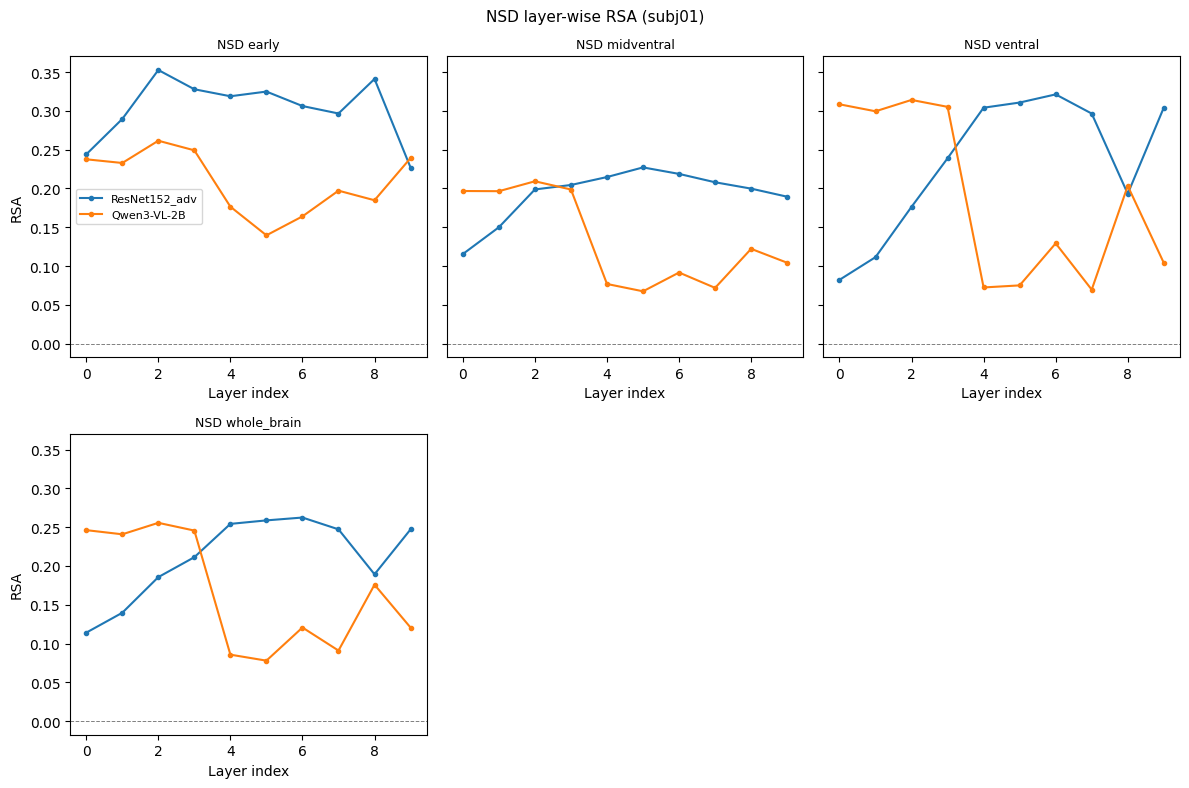

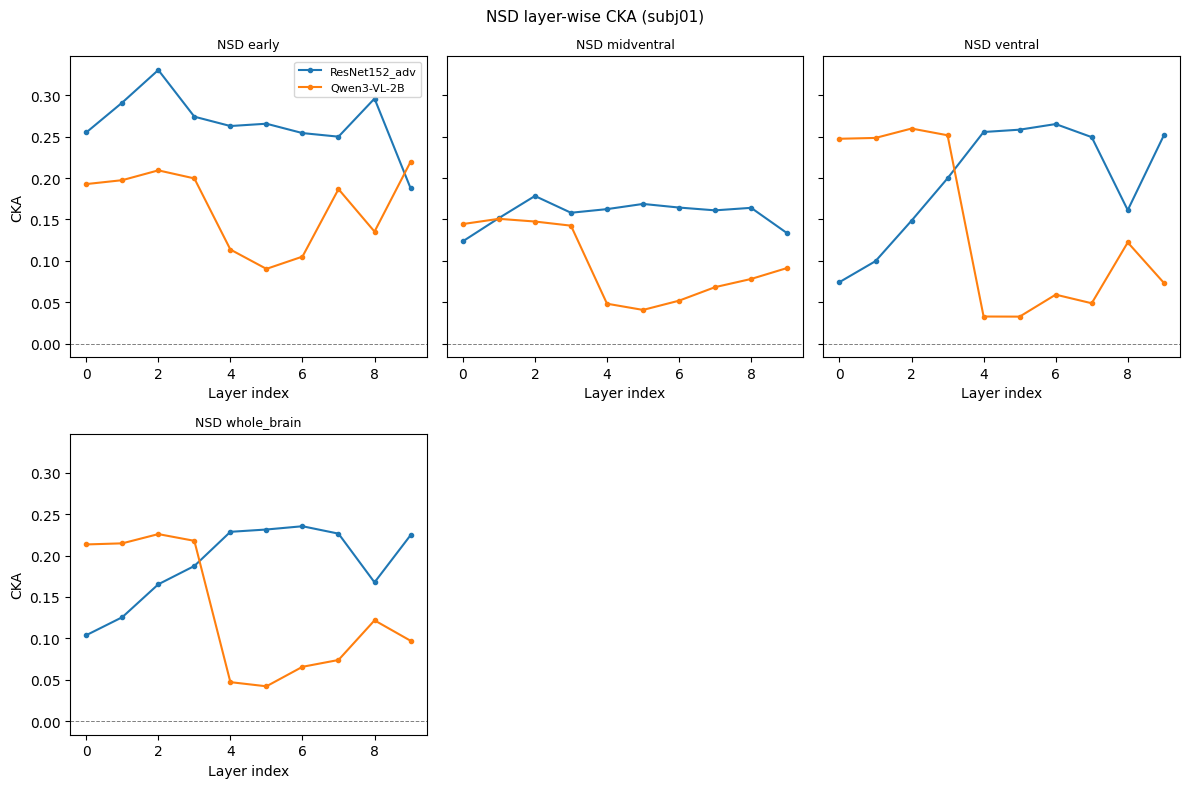

,model,roi,RSA,CKA
0,Qwen3-VL-2B,early,0.261615,0.219670
4,ResNet152_adv,early,0.352824,0.330620
1,Qwen3-VL-2B,midventral,0.209299,0.150756
5,ResNet152_adv,midventral,0.227196,0.178363
2,Qwen3-VL-2B,ventral,0.314227,0.259881
6,ResNet152_adv,ventral,0.321383,0.265293
3,Qwen3-VL-2B,whole_brain,0.255667,0.225963
7,ResNet152_adv,whole_brain,0.262502,0.235460


In [40]:
# Main loop
rows_nsd = []
for roi in nsd_key_rois:
    Y      = nsd_neural[roi]
    Y_rdm  = nsd_neural_rdms[roi]
    print(f"Processing NSD ROI: {roi}, shape: {Y.shape}")

    for layer in resnet_nsd_layers:
        X   = resnet_nsd_feats_pca[layer]
        rows_nsd.append({
            "dataset": "NSD",
            "subject": nsd_subject,
            "roi":     roi,
            "model":   "ResNet152_adv",
            "layer":   layer,
            "RSA":     rsa_metric.compare_rdms(resnet_nsd_rdms[layer], Y_rdm),
            "CKA":     safe_metric(cka_metric, X, Y),
        })

    for layer in qwen_nsd_layers:
        X   = qwen_nsd_feats_pca[layer]
        rows_nsd.append({
            "dataset": "NSD",
            "subject": nsd_subject,
            "roi":     roi,
            "model":   "Qwen3-VL-2B",
            "layer":   layer,
            "RSA":     rsa_metric.compare_rdms(qwen_nsd_rdms[layer], Y_rdm),
            "CKA":     safe_metric(cka_metric, X, Y),
        })

df_nsd = pd.DataFrame(rows_nsd)
display(df_nsd.head())

# Plots
for metric in ["RSA", "CKA"]:
    n_rois = len(nsd_key_rois)
    n_cols = min(n_rois, 3)
    n_rows = int(np.ceil(n_rois / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(12, 4 * n_rows),
        sharey=True, squeeze=False
    )

    for idx, roi in enumerate(nsd_key_rois):
        row = idx // n_cols
        col = idx % n_cols
        ax  = axes[row][col]

        sub = df_nsd[df_nsd["roi"] == roi]
        for model in ["ResNet152_adv", "Qwen3-VL-2B"]:
            sub_m = sub[sub["model"] == model].reset_index(drop=True)
            ax.plot(np.arange(len(sub_m)), sub_m[metric],
                    marker="o", markersize=3, label=model)

        ax.set_title(f"NSD {roi}", fontsize=9)
        ax.set_xlabel("Layer index")
        if col == 0:
            ax.set_ylabel(metric)
        ax.axhline(0, linestyle="--", linewidth=0.7, color="gray")

    axes[0][0].legend(fontsize=8)

    for idx in range(n_rois, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].set_visible(False)

    fig.suptitle(f"NSD layer-wise {metric} ({nsd_subject})", fontsize=11)
    plt.tight_layout()
    plt.show()

# Summary
nsd_summary = (
    df_nsd.groupby(["model", "roi"], as_index=False)[["RSA", "CKA"]]
    .max()
    .sort_values(["roi", "model"])
)
display(nsd_summary)

,dataset,roi,model,RSA,CKA
0,EEG2,whole_brain,Qwen3-VL-2B,0.157288,0.052914
1,EEG2,whole_brain,ResNet152_adv,0.142405,0.112804
2,NSD,early,Qwen3-VL-2B,0.261615,0.219670
3,NSD,early,ResNet152_adv,0.352824,0.330620
4,NSD,midventral,Qwen3-VL-2B,0.209299,0.150756
5,NSD,midventral,ResNet152_adv,0.227196,0.178363
6,NSD,ventral,Qwen3-VL-2B,0.314227,0.259881
7,NSD,ventral,ResNet152_adv,0.321383,0.265293
8,NSD,whole_brain,Qwen3-VL-2B,0.255667,0.225963
9,NSD,whole_brain,ResNet152_adv,0.262502,0.235460



Best RSA per dataset:


model,Qwen3-VL-2B,ResNet152_adv
dataset,,
EEG2,0.157288,0.142405
NSD,0.314227,0.352824
TVSD,0.129551,0.290472



Best CKA per dataset:


model,Qwen3-VL-2B,ResNet152_adv
dataset,,
EEG2,0.052914,0.112804
NSD,0.259881,0.330620
TVSD,0.178757,0.347218


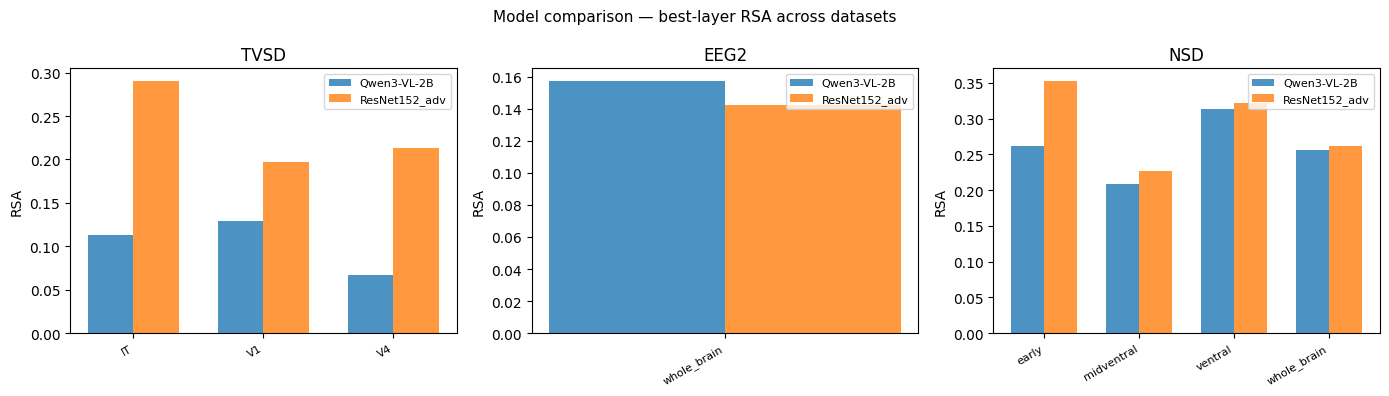

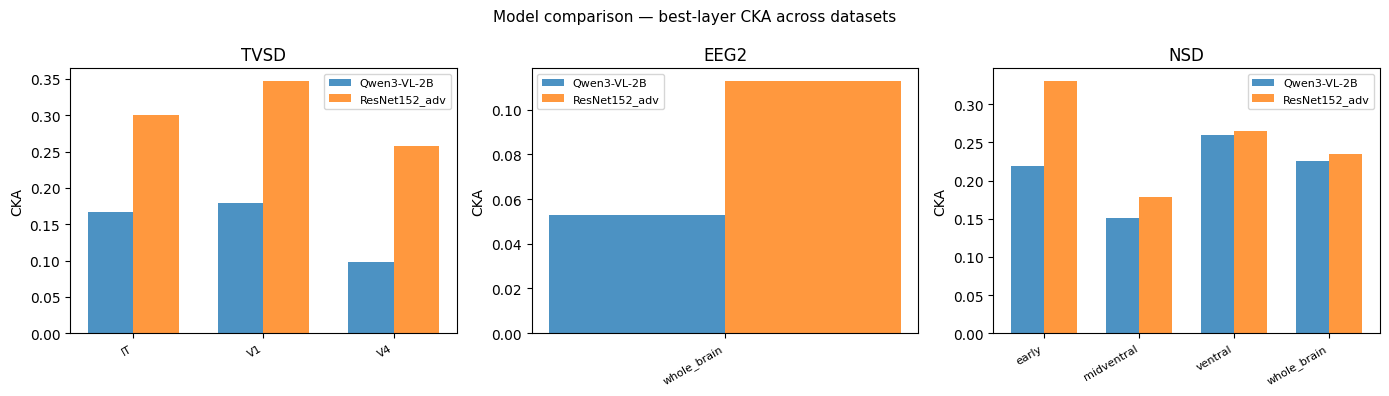

In [41]:
# =========================================================
# D) Direct comparison between the two models - all datasets
# =========================================================

# Best score per model per ROI for each dataset
direct_tvsd = (
    df_tvsd.groupby(["model", "roi"], as_index=False)[["RSA", "CKA"]]
    .max().assign(dataset="TVSD")
)
direct_eeg = (
    df_eeg.groupby(["model"], as_index=False)[["RSA", "CKA"]]
    .max().assign(dataset="EEG2", roi="whole_brain")
)
direct_nsd = (
    df_nsd.groupby(["model", "roi"], as_index=False)[["RSA", "CKA"]]
    .max().assign(dataset="NSD")
)

direct_all = pd.concat(
    [direct_tvsd, direct_eeg, direct_nsd],
    ignore_index=True
)[["dataset", "roi", "model", "RSA", "CKA"]]

display(direct_all.sort_values(["dataset", "roi", "model"]).reset_index(drop=True))

# Summary: best score per model per dataset
for metric in ["RSA", "CKA"]:
    pivot = (
        direct_all.groupby(["dataset", "model"])[metric]
        .max()
        .unstack("model")
    )
    print(f"\nBest {metric} per dataset:")
    display(pivot)

# Bar plot: model comparison per dataset
for metric in ["RSA", "CKA"]:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

    for ax, (dataset_name, df_d) in zip(axes, [
        ("TVSD",  direct_tvsd),
        ("EEG2",  direct_eeg),
        ("NSD",   direct_nsd),
    ]):
        roi_names   = df_d["roi"].unique().tolist()
        model_names = df_d["model"].unique().tolist()
        x     = np.arange(len(roi_names))
        width = 0.35

        for i, model_name in enumerate(model_names):
            scores = [
                df_d.loc[(df_d["roi"] == roi) & (df_d["model"] == model_name), metric].values[0]
                if len(df_d.loc[(df_d["roi"] == roi) & (df_d["model"] == model_name)]) > 0
                else 0.0
                for roi in roi_names
            ]
            ax.bar(x + i * width, scores, width, label=model_name, alpha=0.8)

        ax.set_xticks(x + width / 2)
        ax.set_xticklabels(roi_names, rotation=30, ha="right", fontsize=8)
        ax.set_title(dataset_name)
        ax.set_ylabel(metric)
        ax.axhline(0, linestyle="--", linewidth=0.7, color="gray")
        ax.legend(fontsize=8)

    fig.suptitle(f"Model comparison — best-layer {metric} across datasets", fontsize=11)
    plt.tight_layout()
    plt.show()

---

## 2.4 Predictive alignment: linear encoding models

## Linear encoding model

In the predictive part of the project, you will map model features to neural responses using a **linear encoding model with L2 regularization (ridge regression)**.

For a stimulus $\mathbf{x}$, let $\mathbf{z}_{\ell}(\mathbf{x})$ denote the feature vector extracted from model layer $\ell$. For a given subject $s$ and neural target $r$ (for example an ROI, a group of voxels, or a set of channels / time points), the predicted neural response is

$$
\widehat{\mathbf{y}}_{r,s}(\mathbf{x})
=
W_{r,s}\,\mathbf{z}_{\ell}(\mathbf{x}) + \mathbf{b}_{r,s},
$$

where:
- $\mathbf{z}_{\ell}(\mathbf{x}) \in \mathbb{R}^{d}$ is the model feature vector,
- $\widehat{\mathbf{y}}_{r,s}(\mathbf{x}) \in \mathbb{R}^{p}$ is the predicted neural response,
- $W_{r,s} \in \mathbb{R}^{p \times d}$ is the learned linear mapping,
- $\mathbf{b}_{r,s} \in \mathbb{R}^{p}$ is a bias term.

We fit the mapping on the training split using ridge regression:

$$
\min_{W_{r,s},\,\mathbf{b}_{r,s}}
\sum_{\mathbf{x}\in\mathcal{D}_{\mathrm{train}}}
\left\|
\mathbf{y}_{r,s}(\mathbf{x}) - \widehat{\mathbf{y}}_{r,s}(\mathbf{x})
\right\|_2^2
\;+\;
\alpha \left\|W_{r,s}\right\|_F^2.
$$

Here, $\mathbf{y}_{r,s}(\mathbf{x})$ is the measured neural response, and $\alpha$ controls the strength of L2 regularization. Larger $\alpha$ penalizes large weights more strongly, which can improve generalization when the feature dimension is high. You should select $\alpha$ using only the training data, for example with a validation split or cross-validation, and then evaluate the final model on the held-out test set.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Select the required targets</div>

Use the following targets:

- **TVSD:** all ROIs
- **EEG2:** `occipital_parietal`
- **NSD:** `V1v`, `V2v`, `V3v`, `hV4`, `FFA-1`, `VWFA-1`, `PPA`, `OPA`, `EBA`

You may explore additional ROIs if you wish.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.2</strong><br>Briefly explain why these targets are scientifically interesting. Are they chosen mainly for reliability, interpretability, or both?</div>

In [90]:
# TODO: define target ROIs / regions
# TODO: load corresponding neural data

In [91]:
# TVSD: all ROIs, monkeyF only
tvsd_monkey   = "monkeyF"
tvsd_rois_enc = list(tvsd_h5["train/neural_data/monkeyF"].keys())  # all ROIs

tvsd_targets = {}
for roi in tvsd_rois_enc:
    tvsd_targets[roi] = {
        "X_train":   tvsd_h5[f"train/neural_data/{tvsd_monkey}/{roi}"][:],
        "X_test":    tvsd_h5[f"test/neural_data/{tvsd_monkey}/{roi}"][:],
        "nc":        tvsd_h5[f"noise_ceilings/{tvsd_monkey}/{roi}"][:],
        "ids_train": tvsd_h5["train/stimulus_ids"][:],
        "ids_test":  tvsd_h5["test/stimulus_ids"][:],
        "feat_key":  "things",
    }

print("TVSD targets (monkeyF):")
for k, v in tvsd_targets.items():
    print(f"  {k}: train={v['X_train'].shape}, test={v['X_test'].shape}, nc={v['nc'].shape}")

TVSD targets (monkeyF):
  IT: train=(22248, 241), test=(100, 241), nc=(241,)
  V1: train=(22248, 462), test=(100, 462), nc=(462,)
  V4: train=(22248, 139), test=(100, 139), nc=(139,)


In [92]:
# EEG2: occipital_parietal, subject 01

# Flatten (n_stimuli, n_channels, n_time) -> (n_stimuli, n_channels * n_time)
# as justified in section 0.8: we choose flattening for computational tractability.
eeg_subject = "sub-01"
eeg2_targets = {}

for roi in ["occipital_parietal"]:
    Y_train_raw = eeg2_h5[f"train/neural_data/{eeg_subject}/{roi}"][:]
    Y_test_raw  = eeg2_h5[f"test/neural_data/{eeg_subject}/{roi}"][:]
    nc_raw      = eeg2_h5[f"noise_ceilings/{eeg_subject}/{roi}"][:]  # (channels, time)

    eeg2_targets[roi] = {
        "X_train":   Y_train_raw.reshape(Y_train_raw.shape[0], -1),  # (n_stim, ch*time)
        "X_test":    Y_test_raw.reshape(Y_test_raw.shape[0], -1),
        "nc":        nc_raw.ravel(),   # (ch*time,) to match flattened targets
        "nc_2d":     nc_raw,           # (channels, time) kept for EEG filter
        "ids_train": eeg2_h5["train/stimulus_ids"][:],
        "ids_test":  eeg2_h5["test/stimulus_ids"][:],
        "feat_key":  "things",
    }

print("\nEEG2 targets (sub-01):")
for k, v in eeg2_targets.items():
    print(f"  {k}: train={v['X_train'].shape}, test={v['X_test'].shape}, nc={v['nc'].shape}")


EEG2 targets (sub-01):
  occipital_parietal: train=(16540, 1360), test=(200, 1360), nc=(1360,)


In [93]:
# NSD: required ROIs, subj01
nsd_subject       = "subj01"
nsd_rois_required = ["V1v", "V2v", "V3v", "hV4", "FFA-1", "VWFA-1", "PPA", "OPA", "EBA"]

nsd_targets = {}
for roi in nsd_rois_required:
    try:
        Y_train = nsd_rois_h5[f"train/neural_data/{nsd_subject}/{roi}"][:]
        Y_test  = nsd_rois_h5[f"test/neural_data/{nsd_subject}/{roi}"][:]
        nc      = nsd_rois_h5[f"noise_ceilings/{nsd_subject}/{roi}"][:]

        nsd_targets[roi] = {
            "X_train":   Y_train,
            "X_test":    Y_test,
            "nc":        nc,
            "ids_train": nsd_rois_h5[f"train/stimulus_ids/{nsd_subject}"][:],
            "ids_test":  nsd_rois_h5[f"test/stimulus_ids/{nsd_subject}"][:],
            "feat_key":  "nsd",
        }
    except KeyError:
        print(f"  [WARNING] ROI {roi} not found for {nsd_subject}, skipping.")

print(f"\nNSD targets ({nsd_subject}):")
for k, v in nsd_targets.items():
    print(f"  {k}: train={v['X_train'].shape}, test={v['X_test'].shape}, nc={v['nc'].shape}")



NSD targets (subj01):
  V1v: train=(9000, 570), test=(1000, 570), nc=(570,)
  V2v: train=(9000, 725), test=(1000, 725), nc=(725,)
  V3v: train=(9000, 554), test=(1000, 554), nc=(554,)
  hV4: train=(9000, 578), test=(1000, 578), nc=(578,)
  FFA-1: train=(9000, 423), test=(1000, 423), nc=(423,)
  VWFA-1: train=(9000, 666), test=(1000, 666), nc=(666,)
  PPA: train=(9000, 604), test=(1000, 604), nc=(604,)
  OPA: train=(9000, 1353), test=(1000, 1353), nc=(1353,)
  EBA: train=(9000, 2078), test=(1000, 2078), nc=(2078,)


<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

For each dataset, target, model, and candidate layer:

- fit a **linear encoding model**,
- select hyperparameters without using the test split,
- evaluate on the test split.

Use iterative solvers (e.g. SGD, Adam) when needed to avoid memory issues, since `sklearn` Ridge might cause OOM.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly defined train/validation/test procedure** that does not use the test set for model selection.
2. **Linear encoding model results** for all required datasets and targets.
3. **The following predictive metrics:** Pearson correlation, noise-corrected Pearson correlation, explained variance, and noise-corrected explained variance.
4. **The following hybrid representational metrics on predicted responses:** encoding-RSA and encoding-CKA.
5. **Layer-wise plots** showing performance across candidate layers.
6. **One best-layer summary table** for the required targets.
7. **One comparison between the two models** using predictive results.
8. **One short written interpretation** in Answer box 2.3.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.3</strong><br>Which model and which layer perform best for each dataset? Summarize the main trends in a short paragraph.</div>

In [47]:
# TODO: define train/val/test procedure
# TODO: fit linear models across layers
# TODO: compute predictive metrics
# TODO: summarize best layers and best scores

In [48]:
# TODO: define train/val/test procedure

#### Train / validation / test split strategy
The neural data is already split into train and test by the dataset providers (section 0.8), so we must NOT touch the test split for hyperparameter selection (alpha in ridge regression).

**Strategy:**
- Train set  : provided train split (used to fit the ridge model)
- Val set    : 10% held out from the train split, used only for alpha selection
- Test set   : provided test split, used only for final evaluation

**Alpha selection:** we try a log-spaced grid of alpha values on the val set and pick the one with the highest mean Pearson correlation across targets.  
The final model is then refit on the full train set (train + val) with the selected alpha before evaluating on test.

In [94]:
from sklearn.linear_model import Ridge, RidgeCV
from scipy.stats import pearsonr
from sklearn.metrics import explained_variance_score

ALPHA_GRID   = np.logspace(1, 7, 6)
RANDOM_STATE = 42


def select_alpha_fast(X_train, Y_train, alpha_grid=ALPHA_GRID):
    """
    Select ridge regularization strength alpha using RidgeCV with
    efficient leave-one-out cross-validation on the training set.
    Much faster than fitting one Ridge per alpha on a held-out val set.
    The test split is never used here.

    Parameters
    ----------
    X_train : np.ndarray, shape (n_train, n_features)
    Y_train : np.ndarray, shape (n_train, n_targets)
    alpha_grid : array-like
        Candidate alpha values.

    Returns
    -------
    best_alpha : float
    """
    rcv = RidgeCV(alphas=alpha_grid, fit_intercept=True)
    rcv.fit(X_train, Y_train)
    return float(rcv.alpha_)


def fit_encoding_model(X_train, Y_train, alpha):
    """
    Fit a ridge regression model on the full training set
    with the selected alpha.

    Parameters
    ----------
    X_train : np.ndarray, shape (n_train, n_features)
    Y_train : np.ndarray, shape (n_train, n_targets)
    alpha   : float

    Returns
    -------
    ridge : fitted Ridge model
    """
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    ridge.fit(X_train, Y_train)
    return ridge


def compute_predictive_metrics(Y_true, Y_pred, noise_ceiling):
    """
    Compute all required predictive metrics per target.

    Metrics (from section 0.8):
      - pearsonr             : raw Pearson correlation per target
      - pearsonr_nc          : noise-corrected Pearson r / sqrt(ev_ceiling)
      - explained_variance   : raw explained variance per target
      - explained_variance_nc: noise-corrected explained variance ev / ev_ceiling

    Noise ceiling correction (from section 0.5):
      - ev_ceiling provided in percent -> divide by 100 to get [0, 1]
      - pearsonr_nc   = r / sqrt(ev_ceiling)
      - ev_nc         = ev / ev_ceiling

    For EEG: targets with noise_ceiling < 0.1 (i.e. < 10%) are excluded
    from averaging as required by section 0.8. This is applied externally
    when summarizing scores, not inside this function.

    Parameters
    ----------
    Y_true        : np.ndarray, shape (n_test, n_targets)
    Y_pred        : np.ndarray, shape (n_test, n_targets)
    noise_ceiling : np.ndarray, shape (n_targets,) in percent [0, 100]

    Returns
    -------
    dict with keys: pearsonr, pearsonr_nc, explained_variance, explained_variance_nc
    """
    nc        = noise_ceiling / 100.0
    n_targets = Y_true.shape[1]
    rs        = np.full(n_targets, np.nan)
    evs       = np.full(n_targets, np.nan)

    for j in range(n_targets):
        yt = Y_true[:, j]
        yp = Y_pred[:, j]
        if np.std(yt) > 0 and np.std(yp) > 0:
            rs[j], _ = pearsonr(yt, yp)
        if np.var(yt) > 0:
            evs[j] = explained_variance_score(yt, yp)

    with np.errstate(divide="ignore", invalid="ignore"):
        rs_nc  = np.where(nc > 0, rs  / np.sqrt(nc), np.nan)
        evs_nc = np.where(nc > 0, evs / nc,           np.nan)

    return {
        "pearsonr":              rs,
        "pearsonr_nc":           rs_nc,
        "explained_variance":    evs,
        "explained_variance_nc": evs_nc,
    }


print("Train/val/test procedure defined.")
print(f"  Alpha grid  : {ALPHA_GRID[0]:.2e} → {ALPHA_GRID[-1]:.2e} ({len(ALPHA_GRID)} values)")
print(f"  TVSD targets: {list(tvsd_targets.keys())}")
print(f"  EEG2 targets: {list(eeg2_targets.keys())}")
print(f"  NSD targets : {list(nsd_targets.keys())}")

Train/val/test procedure defined.
  Alpha grid  : 1.00e+01 → 1.00e+07 (6 values)
  TVSD targets: ['IT', 'V1', 'V4']
  EEG2 targets: ['occipital_parietal']
  NSD targets : ['V1v', 'V2v', 'V3v', 'hV4', 'FFA-1', 'VWFA-1', 'PPA', 'OPA', 'EBA']


In [95]:
# TODO: fit linear models across layers

import time
import json
from IPython.display import clear_output
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr
from sklearn.metrics import explained_variance_score

In [96]:
# Models definition
models = {
    "adv_resnet152": {
        "things": h5py.File(model_specs["adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"]["things"], "r"),
        "nsd":    h5py.File(model_specs["adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"]["nsd"],    "r"),
    },
    "qwen3_vl": {
        "things": h5py.File(model_specs["Qwen3-VL-2B-Instruct"]["things"], "r"),
        "nsd":    h5py.File(model_specs["Qwen3-VL-2B-Instruct"]["nsd"],    "r"),
    },
}

In [97]:
# Helper functions 
def get_layer_names(feat_h5, neural_ids):
    """
    Return all layer dataset names in a feature file,
    filtering out 'ids' and checking shape matches.
    """
    layers = []
    def walk(name, obj):
        if isinstance(obj, h5py.Dataset) and name != "ids":
            if obj.ndim == 2 and obj.shape[0] == len(feat_h5["ids"]):
                layers.append(name)
    feat_h5.visititems(walk)
    return sorted(layers)

def load_features_for_ids(feat_h5, layer_name, neural_ids):
    """
    Load feature rows from an open HDF5 feature file,
    selecting only the rows that correspond to neural_ids.
    """
    feat_ids  = feat_h5["ids"][:]
    id_to_idx = {id_: i for i, id_ in enumerate(feat_ids)}
    feat_idx  = np.array([id_to_idx[x] for x in neural_ids])

    sort_order   = np.argsort(feat_idx)
    restore_order = np.argsort(sort_order)
    sorted_idx   = feat_idx[sort_order]

    features = feat_h5[layer_name][sorted_idx]
    return features[restore_order]

In [98]:
# Pre-fetch layer names — run this before any of the encoding cells
layer_names_cache = {}
for model_name, model_files in models.items():
    layer_names_cache[model_name] = {
        "things": get_layer_names(model_files["things"],
                                  tvsd_h5["test/stimulus_ids"][:]),
        "nsd":    get_layer_names(model_files["nsd"],
                                  nsd_rois_h5["test/stimulus_ids/subj01"][:]),
    }
print("Layer names cached.")

Layer names cached.


In [99]:
from sklearn.linear_model import RidgeCV

def select_alpha_fast(X_tr, Y_tr, alpha_grid=ALPHA_GRID):
    """
    Select alpha using RidgeCV with efficient LOO cross-validation.
    Much faster than fitting one Ridge per alpha.
    """
    rcv = RidgeCV(alphas=alpha_grid, fit_intercept=True)
    rcv.fit(X_tr, Y_tr)
    return rcv.alpha_


def run_encoding_for_target(target_dict, feat_h5_things, feat_h5_nsd,
                             layer_names_things, layer_names_nsd,
                             rsa_fn, cka_fn, n_pca=50):
    """
    Fit ridge encoding models across all layers for one target ROI.
    Uses RidgeCV for fast alpha selection without a separate val split.
    PCA reduced to n_pca=50 for memory efficiency.
    """
    Y_train   = target_dict["X_train"]
    Y_test    = target_dict["X_test"]
    nc        = target_dict["nc"]
    ids_train = target_dict["ids_train"]
    ids_test  = target_dict["ids_test"]
    feat_key  = target_dict["feat_key"]

    feat_h5     = feat_h5_things if feat_key == "things" else feat_h5_nsd
    layer_names = layer_names_things if feat_key == "things" else layer_names_nsd

    layer_results = {}

    for layer in layer_names:
        # 1) Load features
        X_train_full = load_features_for_ids(feat_h5, layer, ids_train)
        X_test_full  = load_features_for_ids(feat_h5, layer, ids_test)

        # 2) PCA reduction — fit on train only
        n_components = min(n_pca, X_train_full.shape[1],
                           X_train_full.shape[0] - 1)
        pca = PCA(n_components=n_components, random_state=0)
        X_train_full = pca.fit_transform(X_train_full)
        X_test_full  = pca.transform(X_test_full)
        del pca

        # 3) Select alpha with RidgeCV (LOO, no separate val split needed)
        best_alpha = select_alpha_fast(X_train_full, Y_train)

        # 4) Refit on full train with selected alpha
        ridge = Ridge(alpha=best_alpha, fit_intercept=True)
        ridge.fit(X_train_full, Y_train)

        # 5) Predict on test
        Y_pred = ridge.predict(X_test_full)
        del ridge

        # 6) Predictive metrics
        metrics_dict = compute_predictive_metrics(Y_test, Y_pred, nc)

        # 7) Encoding-RSA and encoding-CKA
        enc_rsa = rsa_fn(Y_pred, Y_test)
        enc_cka = cka_fn(Y_pred, Y_test)

        layer_results[layer] = {
            "alpha":                 best_alpha,
            "pearsonr":              metrics_dict["pearsonr"],
            "pearsonr_nc":           metrics_dict["pearsonr_nc"],
            "explained_variance":    metrics_dict["explained_variance"],
            "explained_variance_nc": metrics_dict["explained_variance_nc"],
            "encoding_rsa":          enc_rsa,
            "encoding_cka":          enc_cka,
        }

    return layer_results

In [100]:
# Function so save the results
def save_results_enc(results_enc, path="results_enc.json"):
    """Save encoding results to JSON checkpoint."""
    def convert(obj):
        if isinstance(obj, (np.floating, np.integer)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return obj

    serializable = {}
    for dataset, models_d in results_enc.items():
        serializable[dataset] = {}
        for model, rois in models_d.items():
            serializable[dataset][model] = {}
            for roi, layers in rois.items():
                serializable[dataset][model][roi] = {}
                for layer, met in layers.items():
                    serializable[dataset][model][roi][layer] = {
                        k: convert(v) for k, v in met.items()
                    }
    with open(path, "w") as f:
        json.dump(serializable, f)
    print(f"Saved to {path}")

# Function to reload the results
def load_results_enc(path="results_enc.json"):
    """Reload encoding results from JSON checkpoint."""
    with open(path, "r") as f:
        return json.load(f)

Supposedly long cells:

TSVD: 3 ROIs, 2 models -> 6 results (100 test stimulis)

In [52]:
# TVSD
results_enc = {}

results_enc["TVSD"] = {}
for model_name, model_files in models.items():
    results_enc["TVSD"][model_name] = {}
    for roi_name, target_dict in tvsd_targets.items():
        layer_res = run_encoding_for_target(
            target_dict,
            model_files["things"], model_files["nsd"],
            layer_names_cache[model_name]["things"],
            layer_names_cache[model_name]["nsd"],
            rsa, cka,
        )
        results_enc["TVSD"][model_name][roi_name] = layer_res
        print(f"✓ TVSD | {model_name} | {roi_name}")

save_results_enc(results_enc)

✓ TVSD | adv_resnet152 | IT
✓ TVSD | adv_resnet152 | V1
✓ TVSD | adv_resnet152 | V4
✓ TVSD | qwen3_vl | IT
✓ TVSD | qwen3_vl | V1
✓ TVSD | qwen3_vl | V4


NameError: name 'json' is not defined

In [50]:
save_results_enc(results_enc)

Saved to results_enc.json


In [48]:
results_enc = load_results_enc("results_enc.json")

EEG: 1 ROIs, 2 models -> 2 results (but 16'540 train stimulis)

In [49]:
# EEG2
results_enc["EEG2"] = {}
for model_name, model_files in models.items():
    results_enc["EEG2"][model_name] = {}
    for roi_name, target_dict in eeg2_targets.items():
        layer_res = run_encoding_for_target(
            target_dict,
            model_files["things"], model_files["nsd"],
            layer_names_cache[model_name]["things"],
            layer_names_cache[model_name]["nsd"],
            rsa, cka,
        )
        results_enc["EEG2"][model_name][roi_name] = layer_res
        print(f"✓ EEG2 | {model_name} | {roi_name}")

save_results_enc(results_enc)

✓ EEG2 | adv_resnet152 | occipital_parietal
✓ EEG2 | qwen3_vl | occipital_parietal
Saved to results_enc.json


NSD: 9 ROIs, 2 models -> 18 results (9'000 train stimulis)  
divided in : 3 batches of 3 ROIs each -> 6 results per batch

In [51]:
# NSD batch 1 (V1v, V2v, V3v)
results_enc["NSD"] = {}
nsd_batch1 = ["V1v", "V2v", "V3v"]

for model_name, model_files in models.items():
    results_enc["NSD"][model_name] = {}
    for roi_name in nsd_batch1:
        if roi_name not in nsd_targets:
            continue
        layer_res = run_encoding_for_target(
            nsd_targets[roi_name],
            model_files["things"], model_files["nsd"],
            layer_names_cache[model_name]["things"],
            layer_names_cache[model_name]["nsd"],
            rsa, cka,
        )
        results_enc["NSD"][model_name][roi_name] = layer_res
        print(f"✓ NSD | {model_name} | {roi_name}")

save_results_enc(results_enc)

✓ NSD | adv_resnet152 | V1v
✓ NSD | adv_resnet152 | V2v
✓ NSD | adv_resnet152 | V3v
✓ NSD | qwen3_vl | V1v
✓ NSD | qwen3_vl | V2v
✓ NSD | qwen3_vl | V3v
Saved to results_enc.json


In [101]:
results_enc = load_results_enc("results_enc.json")

In [105]:
# NSD batch 2 (hV4, FFA-1, VWFA-1)
nsd_batch2 = ["hV4", "FFA-1", "VWFA-1"]

for model_name, model_files in models.items():
    for roi_name in nsd_batch2:
        if roi_name not in nsd_targets:
            continue
        layer_res = run_encoding_for_target(
            nsd_targets[roi_name],
            model_files["things"], model_files["nsd"],
            layer_names_cache[model_name]["things"],
            layer_names_cache[model_name]["nsd"],
            rsa, cka,
        )
        results_enc["NSD"][model_name][roi_name] = layer_res
        print(f"✓ NSD | {model_name} | {roi_name}")

save_results_enc(results_enc)

✓ NSD | adv_resnet152 | hV4
✓ NSD | adv_resnet152 | FFA-1
✓ NSD | adv_resnet152 | VWFA-1
✓ NSD | qwen3_vl | hV4
✓ NSD | qwen3_vl | FFA-1
✓ NSD | qwen3_vl | VWFA-1
Saved to results_enc.json


In [106]:
# NSD batch 3 (PPA, OPA, EBA)
nsd_batch3 = ["PPA", "OPA", "EBA"]

for model_name, model_files in models.items():
    for roi_name in nsd_batch3:
        if roi_name not in nsd_targets:
            continue
        layer_res = run_encoding_for_target(
            nsd_targets[roi_name],
            model_files["things"], model_files["nsd"],
            layer_names_cache[model_name]["things"],
            layer_names_cache[model_name]["nsd"],
            rsa, cka,
        )
        results_enc["NSD"][model_name][roi_name] = layer_res
        print(f"✓ NSD | {model_name} | {roi_name}")

save_results_enc(results_enc)

✓ NSD | adv_resnet152 | PPA
✓ NSD | adv_resnet152 | OPA
✓ NSD | adv_resnet152 | EBA
✓ NSD | qwen3_vl | PPA
✓ NSD | qwen3_vl | OPA
✓ NSD | qwen3_vl | EBA
Saved to results_enc.json


---

In [107]:
# TODO: compute predictive metrics

import pandas as pd

def summarize_encoding_results(results_enc, eeg_nc_threshold=0.1):
    """
    Summarize encoding results across layers, datasets, models and ROIs.
    For each (dataset, model, roi), finds the best layer and reports
    all required metrics averaged across targets.

    For EEG: targets with noise_ceiling < eeg_nc_threshold (in [0,1])
    are excluded from averaging as required by section 0.8.

    Parameters
    ----------
    results_enc : dict
        results_enc[dataset][model][roi][layer] = {metrics...}
    eeg_nc_threshold : float
        Noise ceiling threshold below which EEG targets are excluded.

    Returns
    -------
    rows : list of dict, one per (dataset, model, roi, layer)
    df_best : pd.DataFrame, one row per (dataset, model, roi) with best layer
    """
    rows = []

    for dataset_name, models_d in results_enc.items():
        for model_name, rois_d in models_d.items():
            for roi_name, layers_d in rois_d.items():

                for layer_name, met in layers_d.items():

                    # Determine which targets to include
                    # For EEG apply noise ceiling filter (section 0.8)
                    pr  = np.array(met["pearsonr"])
                    pnc = np.array(met["pearsonr_nc"])
                    ev  = np.array(met["explained_variance"])
                    enc = np.array(met["explained_variance_nc"])

                    if dataset_name == "EEG2":
                        # nc stored in eeg2_targets as percent -> convert to [0,1]
                        nc_vals = eeg2_targets[roi_name]["nc"] / 100.0
                        keep    = nc_vals >= eeg_nc_threshold
                        pr  = pr[keep]
                        pnc = pnc[keep]
                        ev  = ev[keep]
                        enc = enc[keep]

                    rows.append({
                        "dataset":               dataset_name,
                        "model":                 model_name,
                        "roi":                   roi_name,
                        "layer":                 layer_name,
                        "alpha":                 met["alpha"],
                        "pearsonr":              float(np.nanmean(pr)),
                        "pearsonr_nc":           float(np.nanmean(pnc)),
                        "explained_variance":    float(np.nanmean(ev)),
                        "explained_variance_nc": float(np.nanmean(enc)),
                        "encoding_rsa":          float(met["encoding_rsa"]),
                        "encoding_cka":          float(met["encoding_cka"]),
                    })

    df_all = pd.DataFrame(rows)

    # Best layer per (dataset, model, roi) by mean Pearson r
    idx_best = df_all.groupby(
        ["dataset", "model", "roi"]
    )["pearsonr"].idxmax()
    df_best = df_all.loc[idx_best].reset_index(drop=True)

    return df_all, df_best

# Compute summary
df_all_enc, df_best_enc = summarize_encoding_results(results_enc)

print("=== All layers — first rows ===")
display(df_all_enc.head(10))

print(f"\nTotal rows (dataset x model x roi x layer): {len(df_all_enc)}")

=== All layers — first rows ===


,dataset,model,roi,layer,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_rsa,encoding_cka
0,TVSD,adv_resnet152,IT,features/layer1-0,39810.717055,0.431367,0.447533,0.194095,0.208792,0.328742,0.231415
1,TVSD,adv_resnet152,IT,features/layer2-0,39810.717055,0.503947,0.522813,0.262162,0.282015,0.381879,0.331721
2,TVSD,adv_resnet152,IT,features/layer3-0,2511.886432,0.600198,0.622674,0.368679,0.396481,0.508025,0.508631
3,TVSD,adv_resnet152,IT,features/layer3-10,2511.886432,0.643112,0.667448,0.421061,0.453586,0.550879,0.576268
4,TVSD,adv_resnet152,IT,features/layer3-15,2511.886432,0.672241,0.697705,0.459784,0.495409,0.592578,0.638074
5,TVSD,adv_resnet152,IT,features/layer3-20,2511.886432,0.669402,0.694820,0.456092,0.491601,0.605038,0.632065
6,TVSD,adv_resnet152,IT,features/layer3-25,2511.886432,0.673683,0.699197,0.460573,0.496298,0.609517,0.643508
7,TVSD,adv_resnet152,IT,features/layer3-30,2511.886432,0.670998,0.696313,0.455618,0.490643,0.604226,0.633197
8,TVSD,adv_resnet152,IT,features/layer3-5,2511.886432,0.626943,0.650642,0.401866,0.432820,0.533555,0.546640
9,TVSD,adv_resnet152,IT,features/layer4-1,39810.717055,0.634020,0.657747,0.405600,0.436333,0.550227,0.570268



Total rows (dataset x model x roi x layer): 260


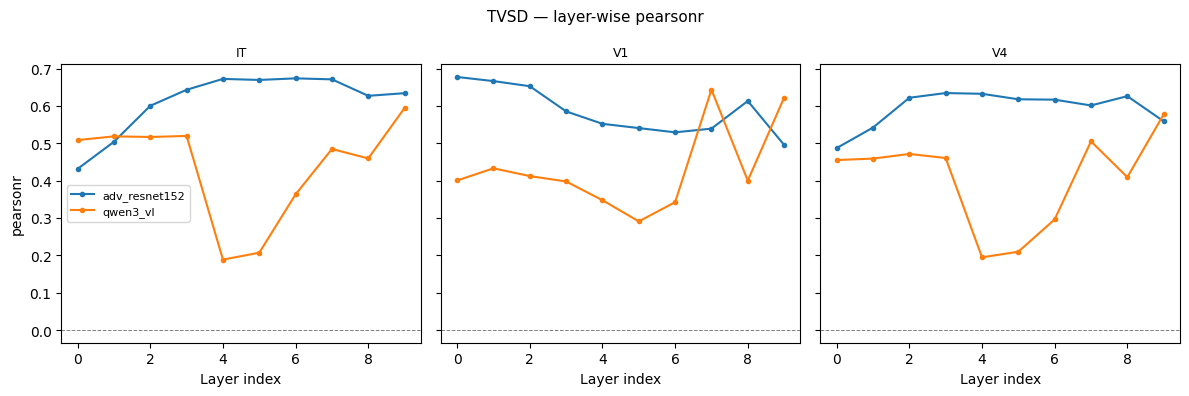

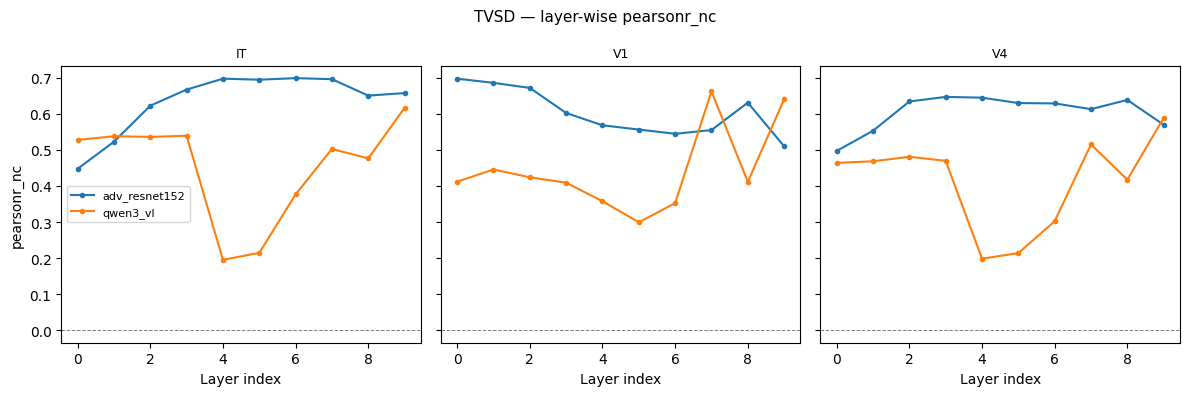

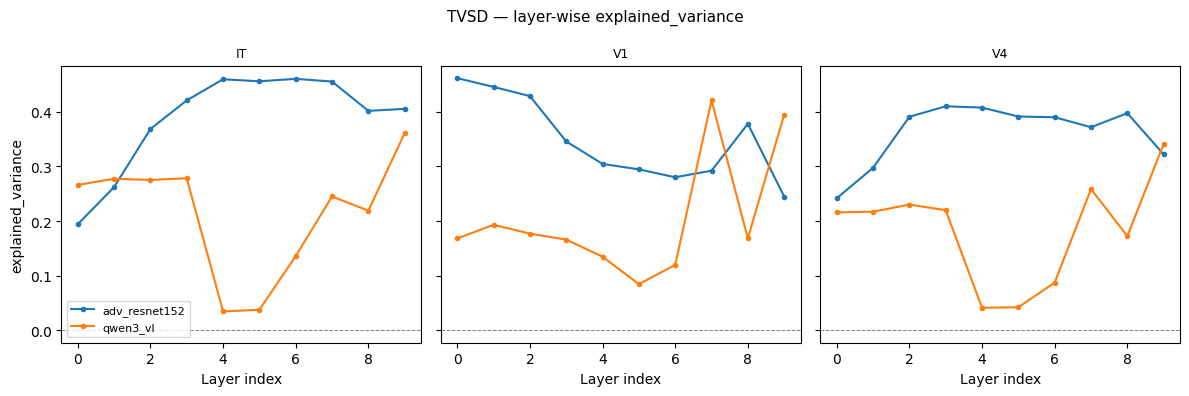

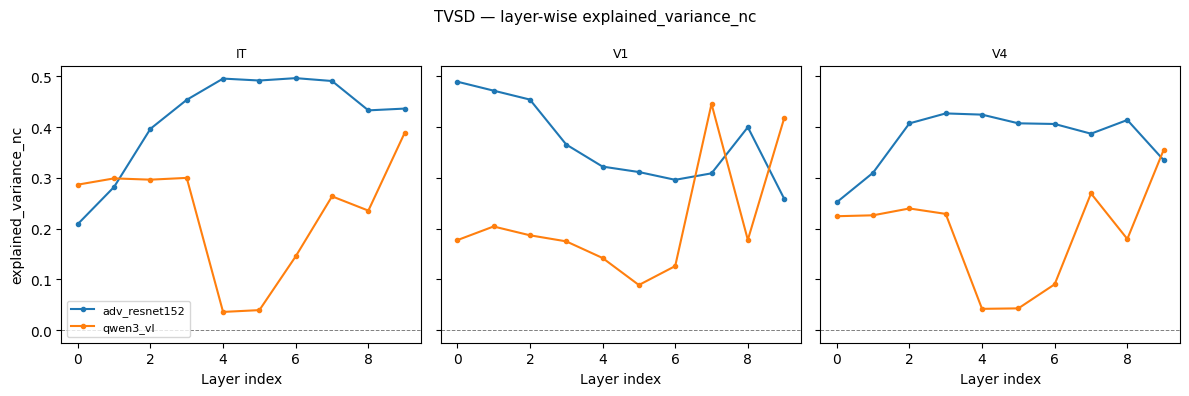

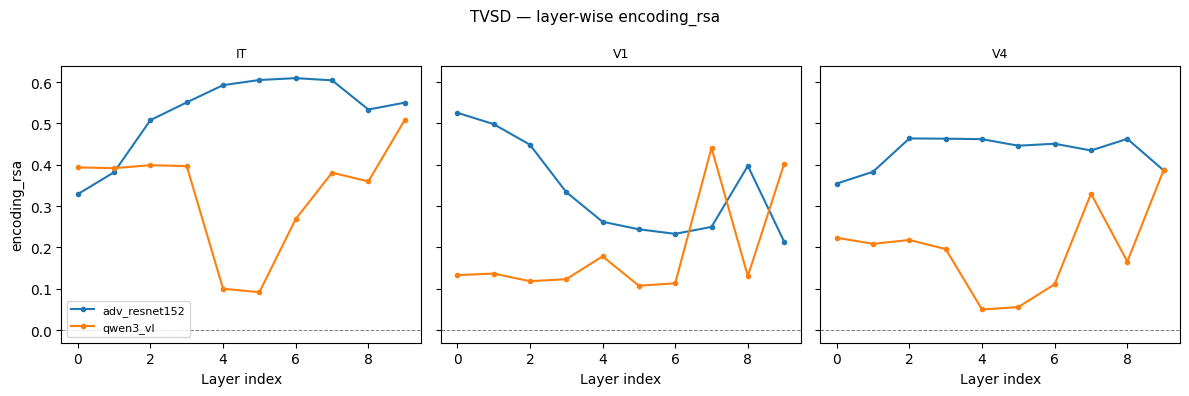

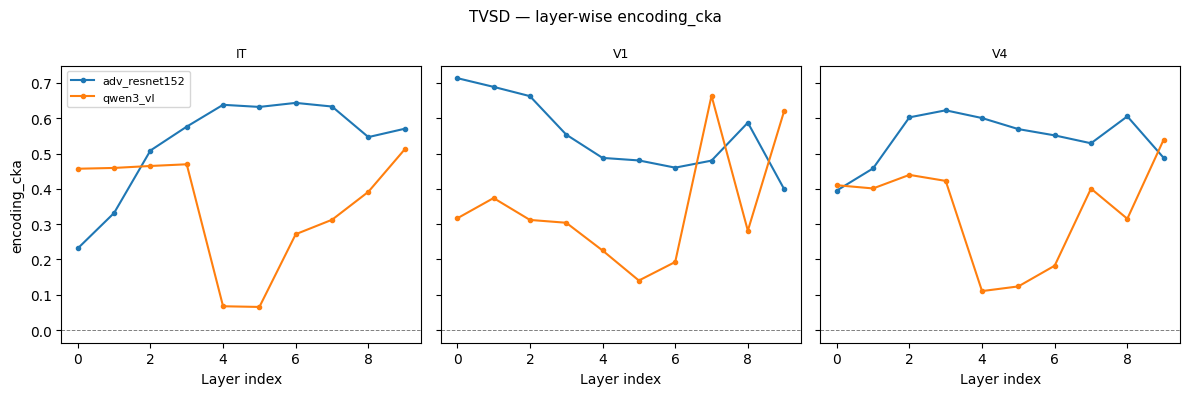

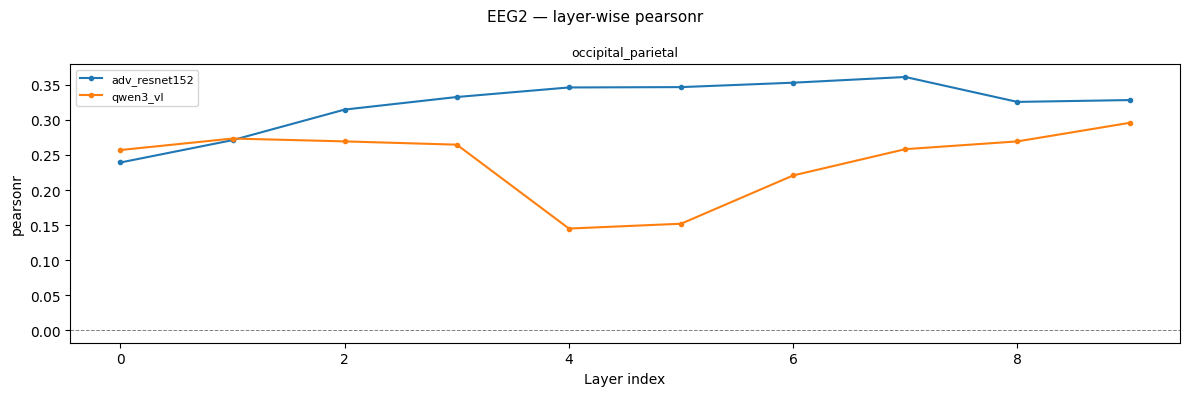

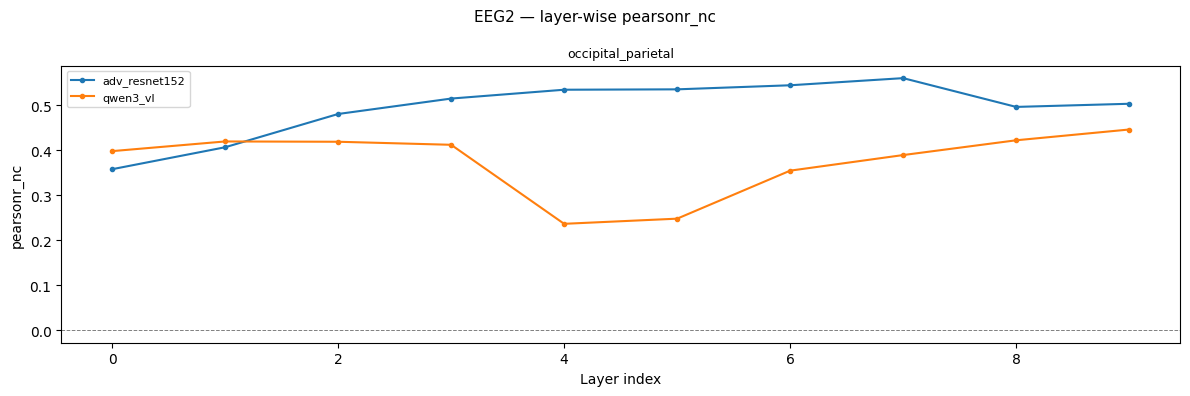

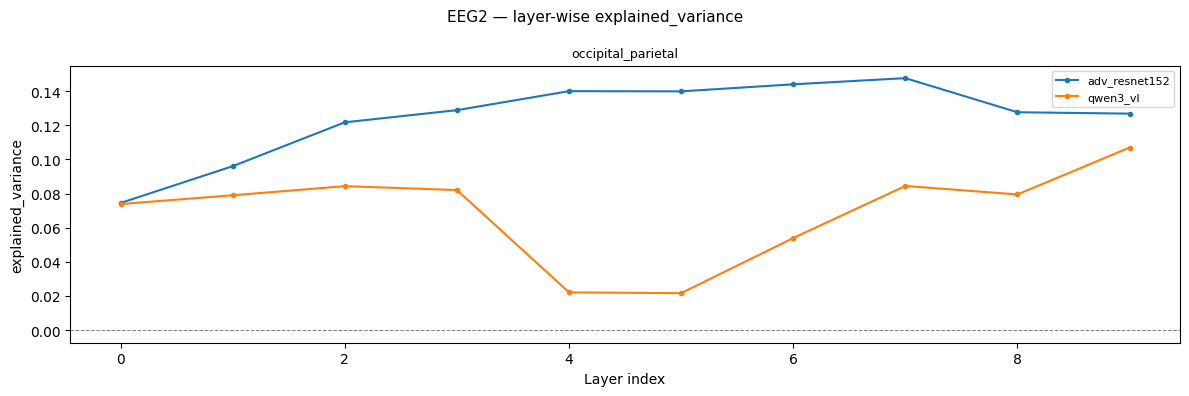

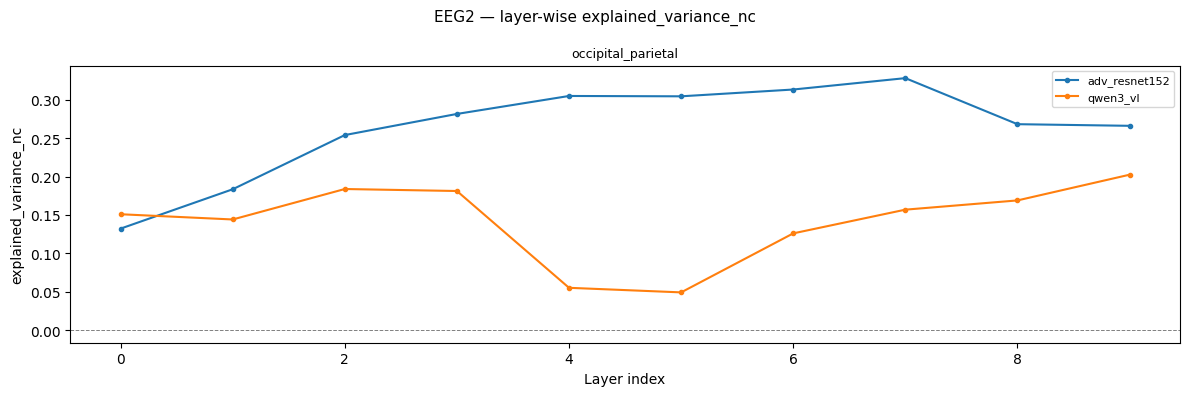

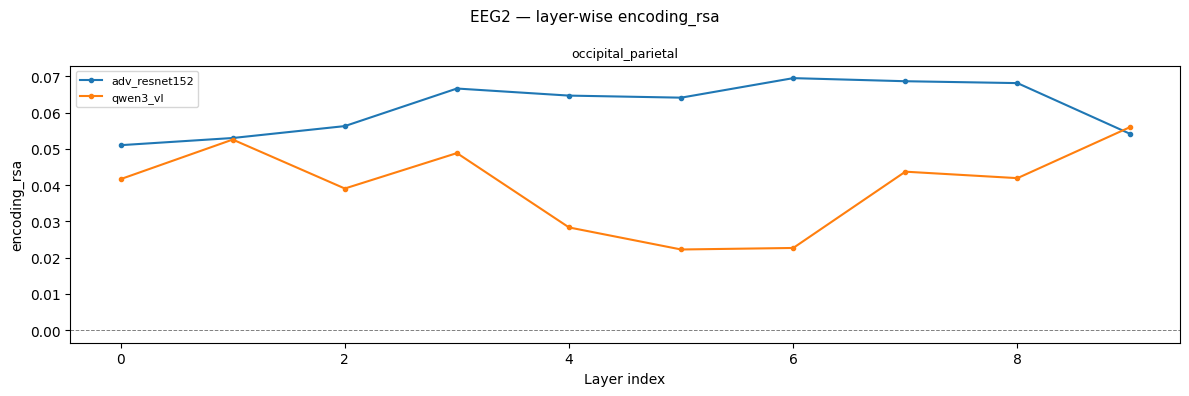

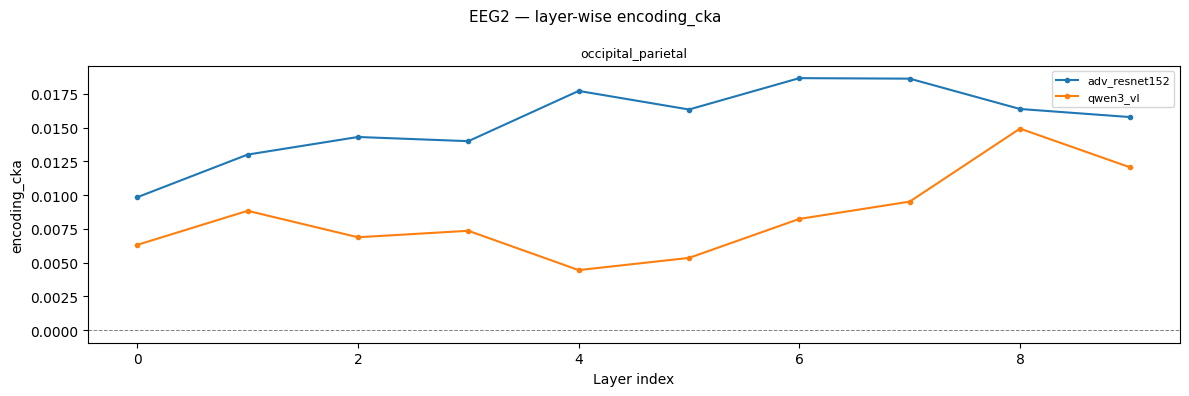

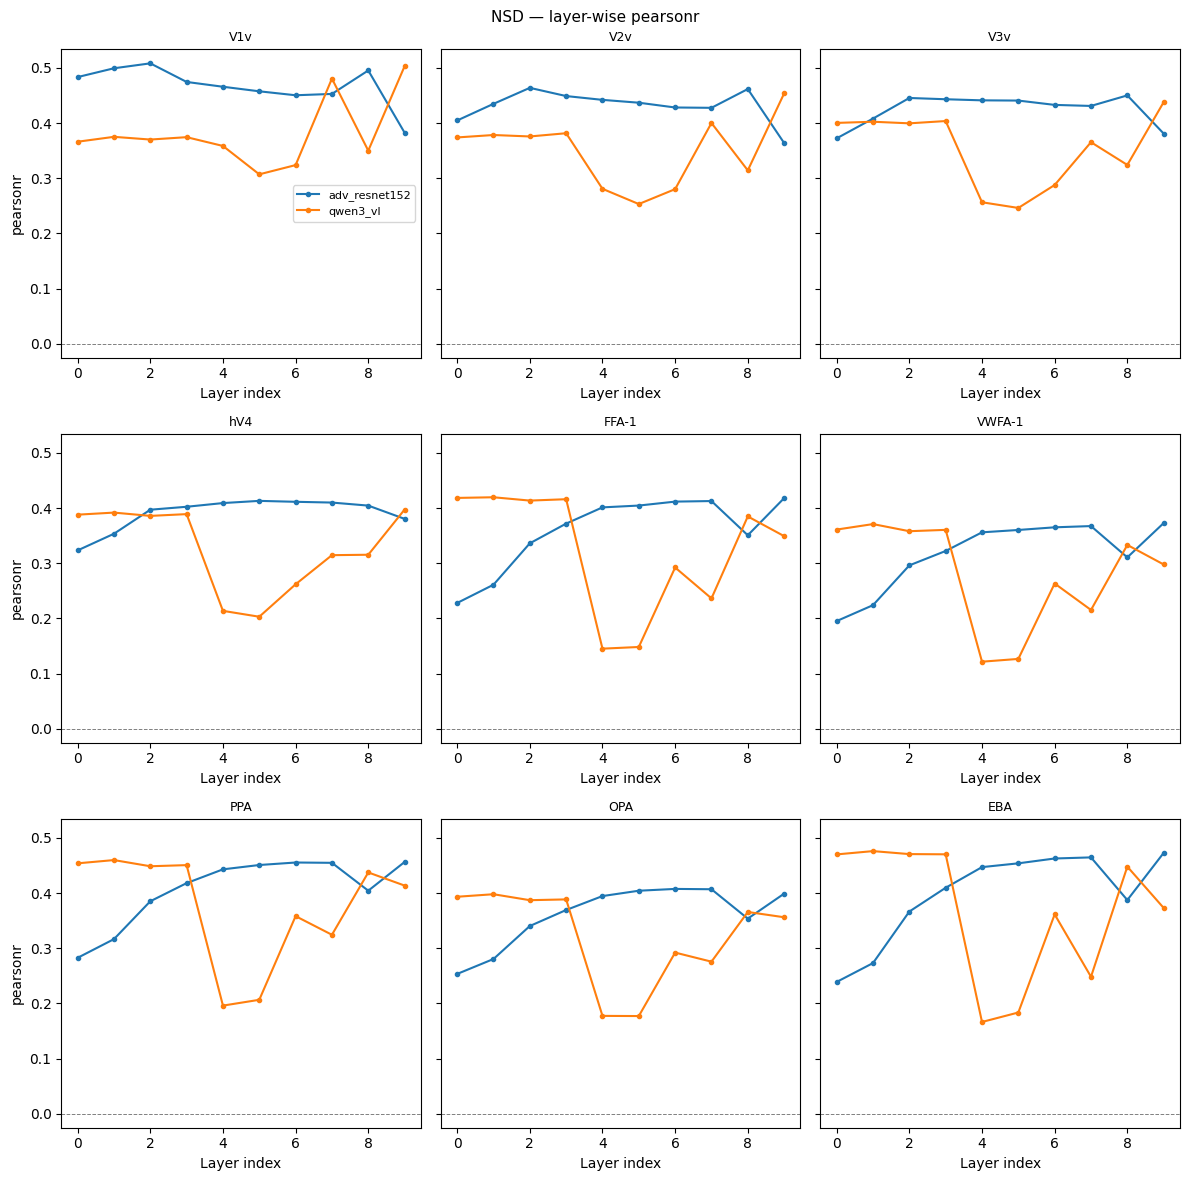

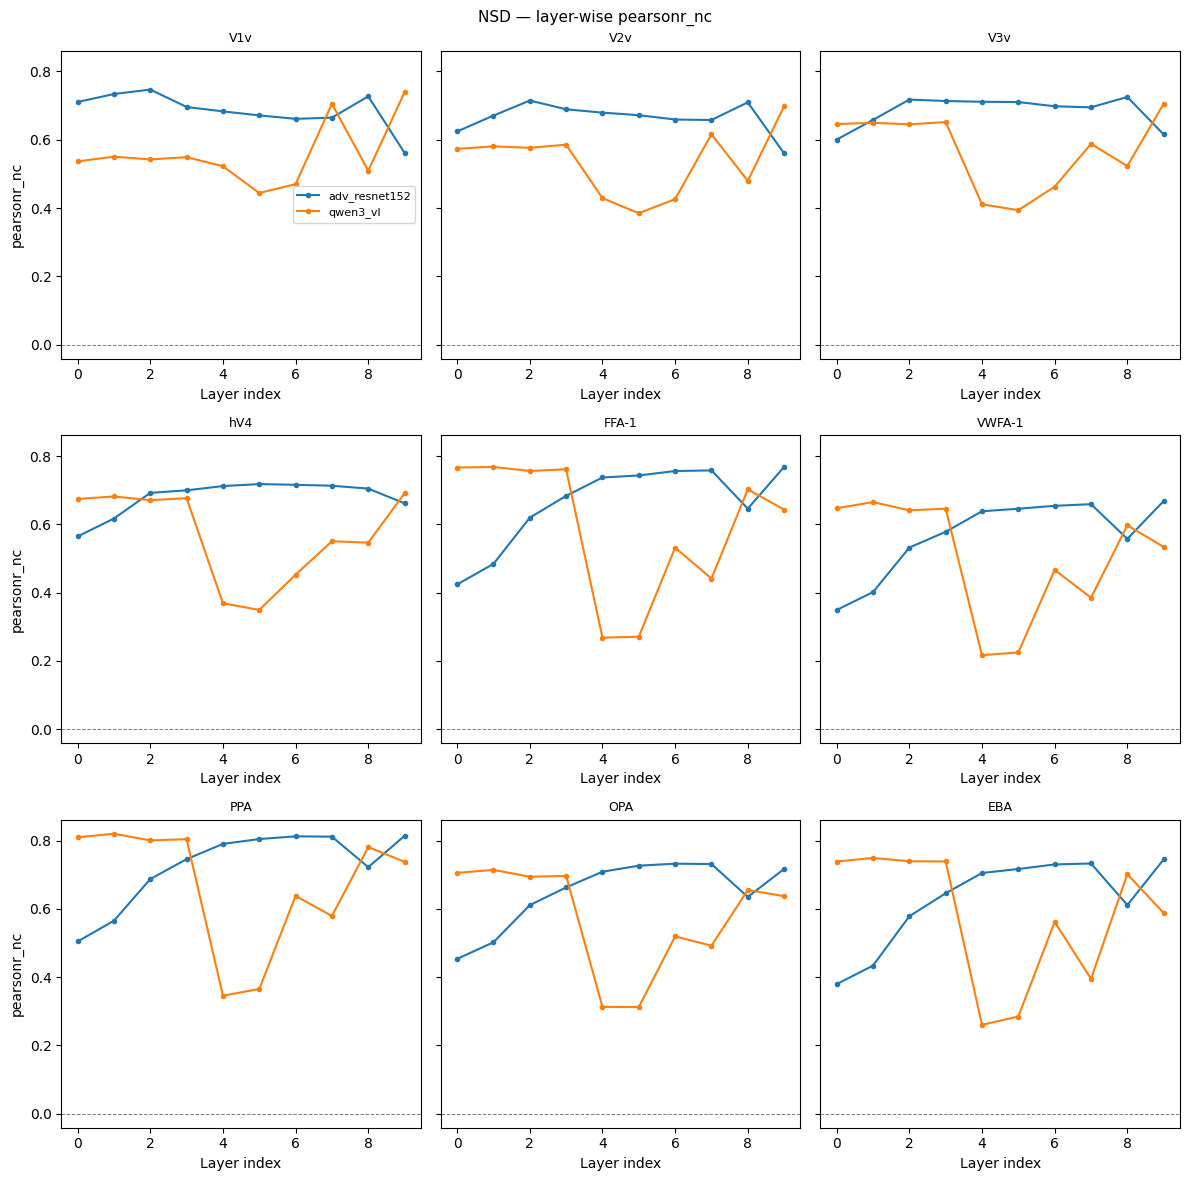

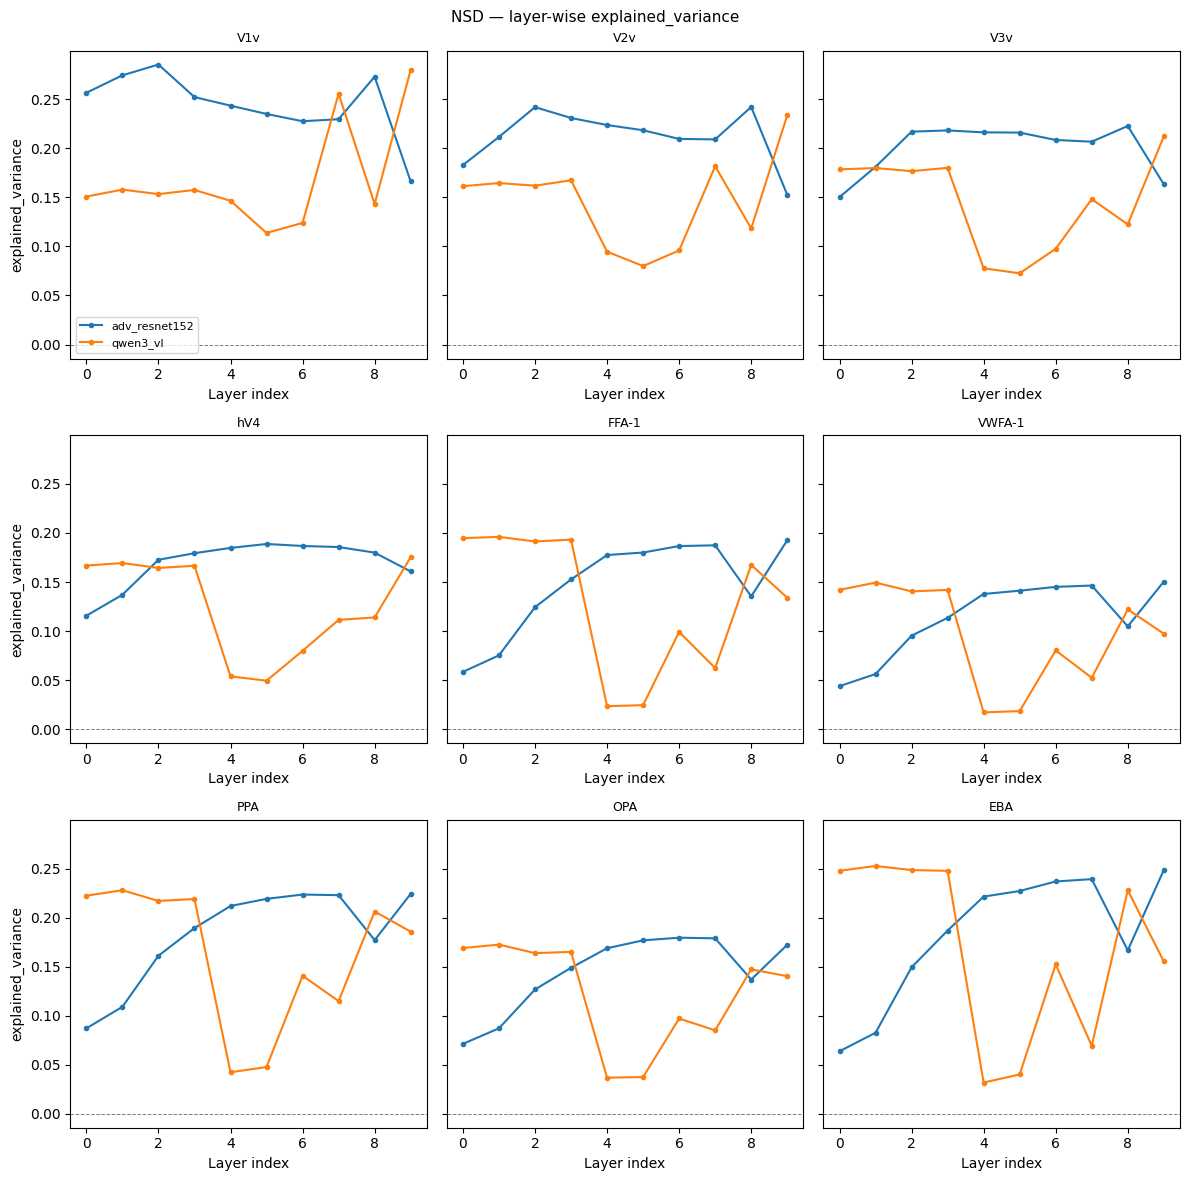

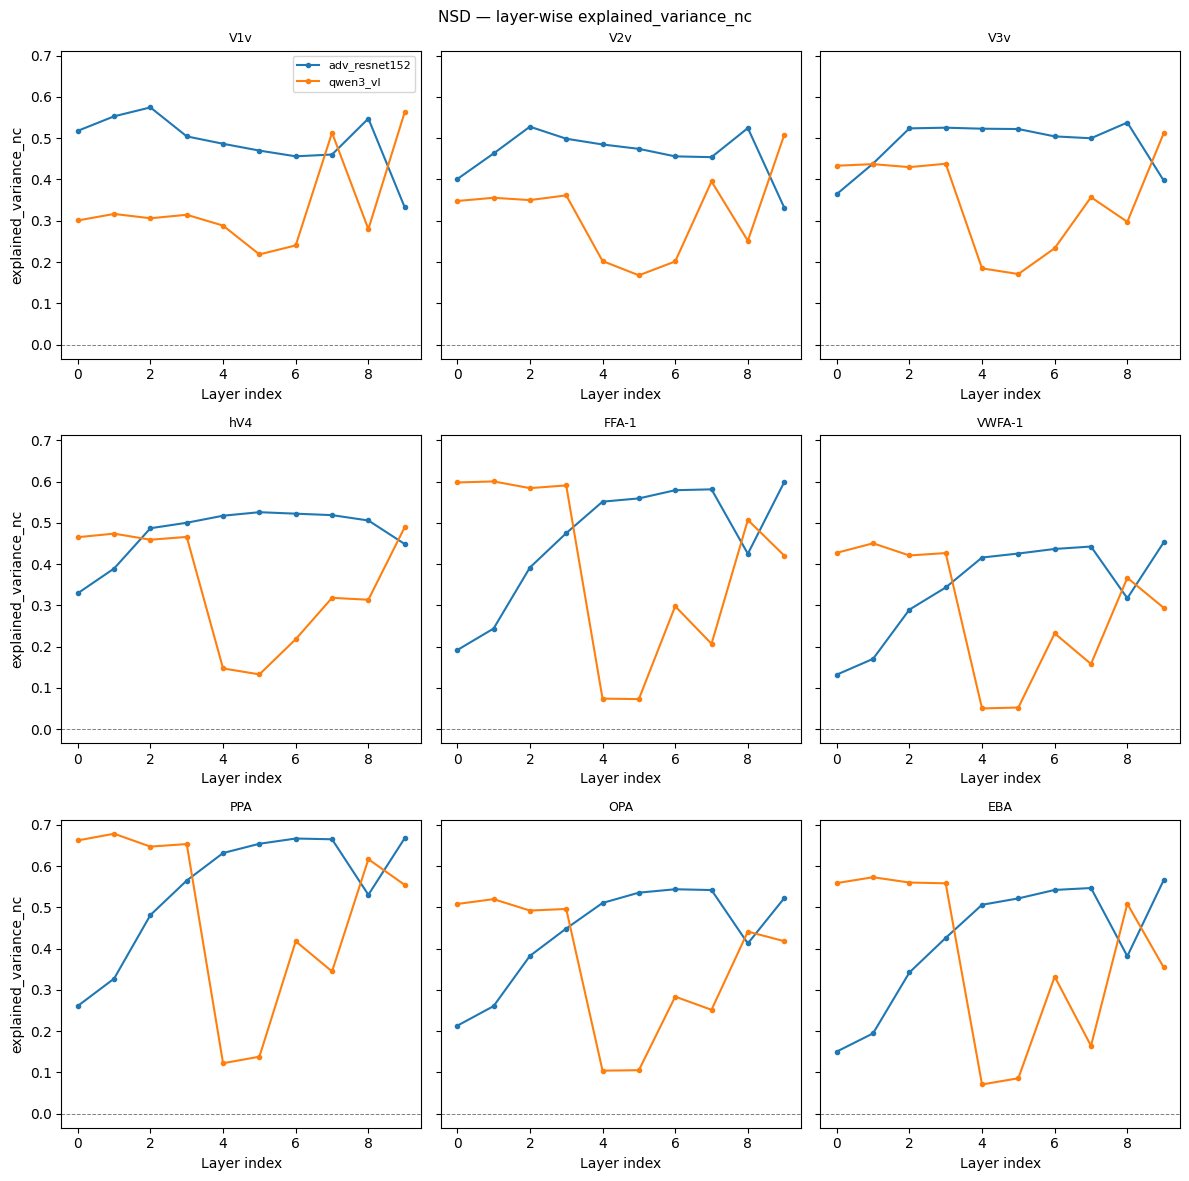

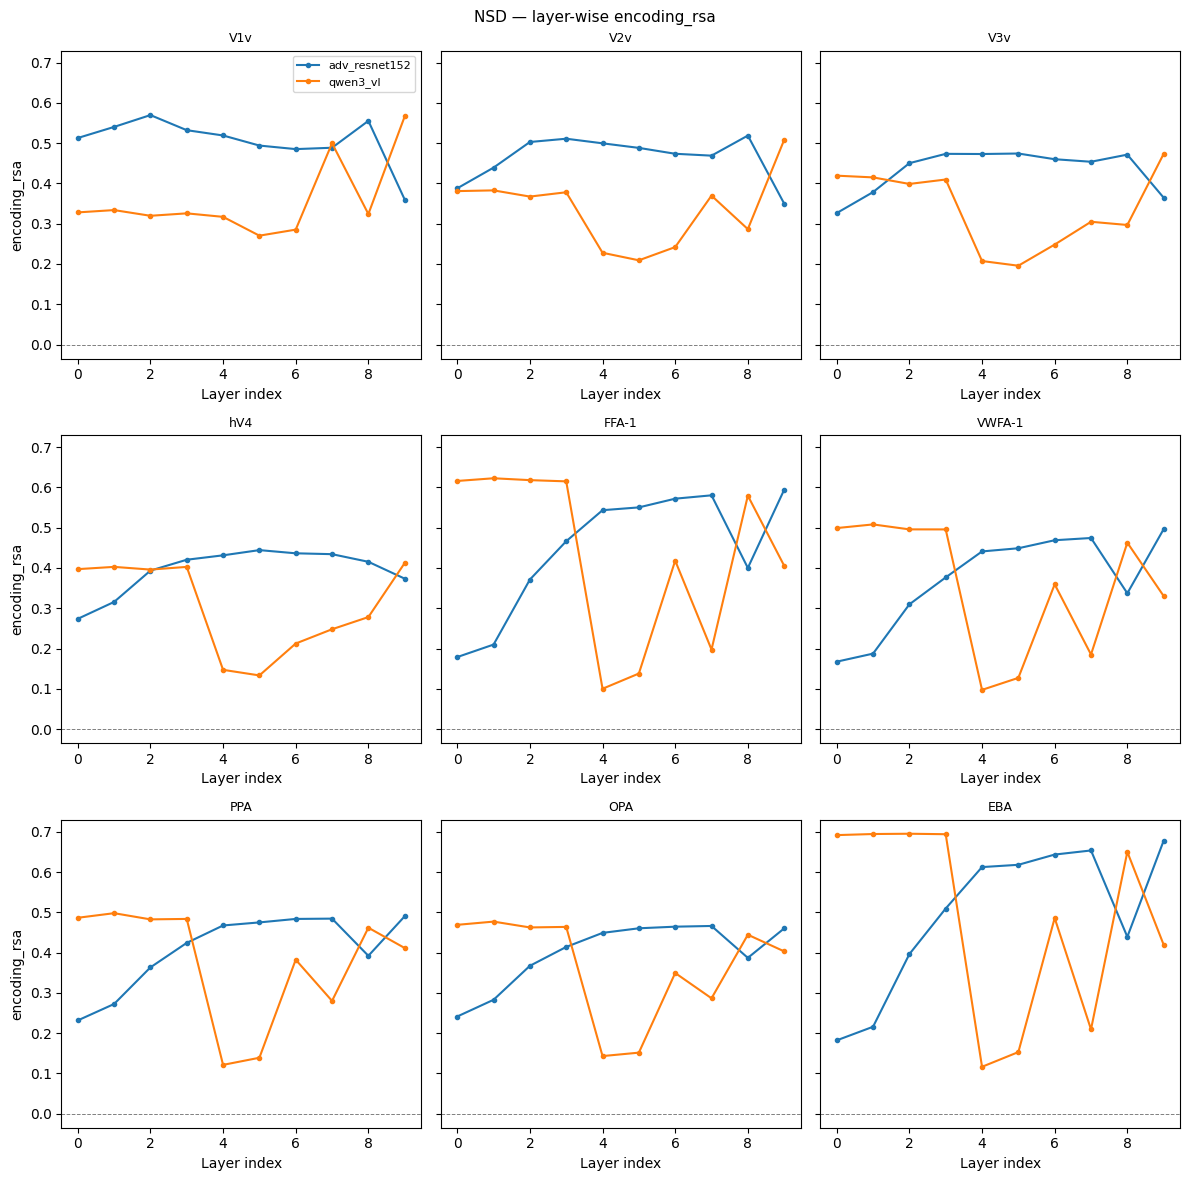

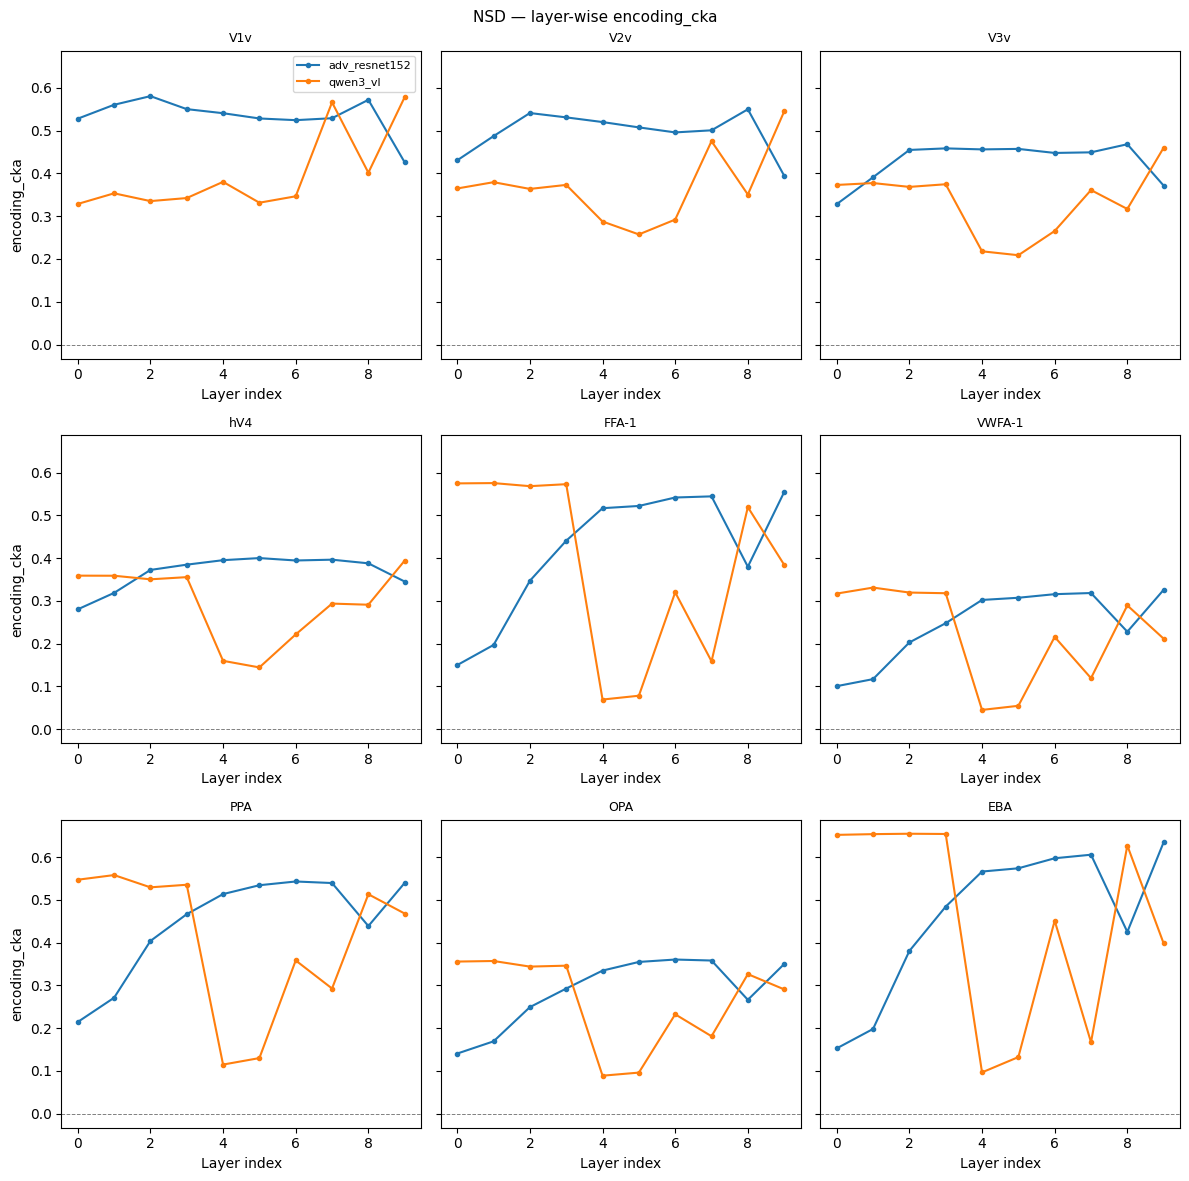

In [108]:
# Layer-wise metric plots
def plot_layerwise_encoding(df_all, dataset_name, metric="pearsonr",
                             max_cols=3, figsize=(12, 4)):
    """
    Plot layer-wise encoding metric for both models, one subplot per ROI.

    Parameters
    ----------
    df_all : pd.DataFrame
    dataset_name : str
    metric : str
        One of: pearsonr, pearsonr_nc, explained_variance,
                explained_variance_nc, encoding_rsa, encoding_cka
    max_cols : int
    figsize : tuple
    """
    df = df_all[df_all["dataset"] == dataset_name].copy()
    roi_names   = df["roi"].unique().tolist()
    model_names = df["model"].unique().tolist()

    n_rois = len(roi_names)
    n_cols = min(n_rois, max_cols)
    n_rows = int(np.ceil(n_rois / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize[0], figsize[1] * n_rows),
        sharey=True, squeeze=False,
    )

    for idx, roi in enumerate(roi_names):
        row = idx // n_cols
        col = idx % n_cols
        ax  = axes[row][col]

        for model_name in model_names:
            sub = df[(df["roi"] == roi) & (df["model"] == model_name)]
            x   = np.arange(len(sub))
            ax.plot(x, sub[metric].values, marker="o",
                    markersize=3, label=model_name)

        ax.set_title(roi, fontsize=9)
        ax.set_xlabel("Layer index")
        ax.axhline(0, linestyle="--", linewidth=0.7, color="gray")
        if col == 0:
            ax.set_ylabel(metric)

    axes[0][0].legend(fontsize=8)

    # Hide unused subplots
    for idx in range(n_rois, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].set_visible(False)

    fig.suptitle(f"{dataset_name} — layer-wise {metric}", fontsize=11)
    plt.tight_layout()
    plt.show()


# Plot all required metrics for each dataset
metrics_to_plot = [
    "pearsonr", "pearsonr_nc",
    "explained_variance", "explained_variance_nc",
    "encoding_rsa", "encoding_cka",
]

for dataset_name in results_enc:
    for metric in metrics_to_plot:
        plot_layerwise_encoding(df_all_enc, dataset_name,
                                metric=metric, max_cols=3, figsize=(12, 4))

In [109]:
# Best-layer summary table
print("\n=== Best layer per (dataset, model, ROI) ===")
display(df_best_enc[[
    "dataset", "model", "roi", "layer", "alpha",
    "pearsonr", "pearsonr_nc",
    "explained_variance", "explained_variance_nc",
    "encoding_rsa", "encoding_cka",
]])


=== Best layer per (dataset, model, ROI) ===


,dataset,model,roi,layer,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_rsa,encoding_cka
0,EEG2,adv_resnet152,occipital_parietal,features/layer3-30,630957.344480,0.361390,0.559730,0.147632,0.328328,0.068652,0.018632
1,EEG2,qwen3_vl,occipital_parietal,features/visual-blocks-6,630957.344480,0.295904,0.445610,0.106958,0.202490,0.055929,0.012055
2,NSD,adv_resnet152,EBA,features/layer4-1,39810.717055,0.472683,0.745128,0.248461,0.565972,0.677696,0.634790
3,NSD,adv_resnet152,FFA-1,features/layer4-1,39810.717055,0.417894,0.768401,0.192524,0.598365,0.594220,0.554276
4,NSD,adv_resnet152,OPA,features/layer3-25,39810.717055,0.407444,0.732651,0.179498,0.544011,0.464365,0.360515
5,NSD,adv_resnet152,PPA,features/layer4-1,39810.717055,0.456273,0.814350,0.224140,0.667766,0.490163,0.539674
6,NSD,adv_resnet152,V1v,features/layer3-0,2511.886432,0.508158,0.747002,0.285509,0.574695,0.569601,0.580764
7,NSD,adv_resnet152,V2v,features/layer3-0,2511.886432,0.463754,0.714882,0.242073,0.527973,0.502799,0.541244
8,NSD,adv_resnet152,V3v,features/layer3-5,2511.886432,0.450068,0.725343,0.222828,0.537996,0.471429,0.468309
9,NSD,adv_resnet152,VWFA-1,features/layer4-1,39810.717055,0.372670,0.668150,0.150405,0.452473,0.496456,0.325733


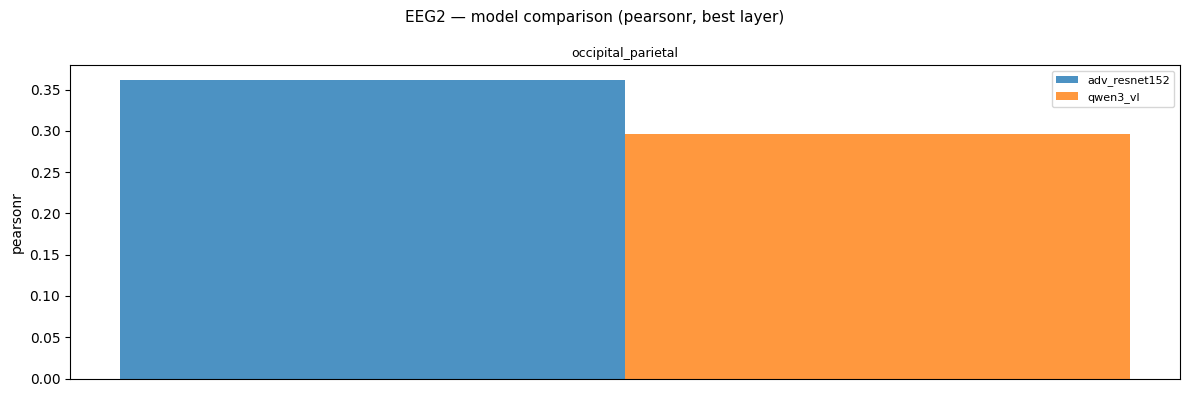

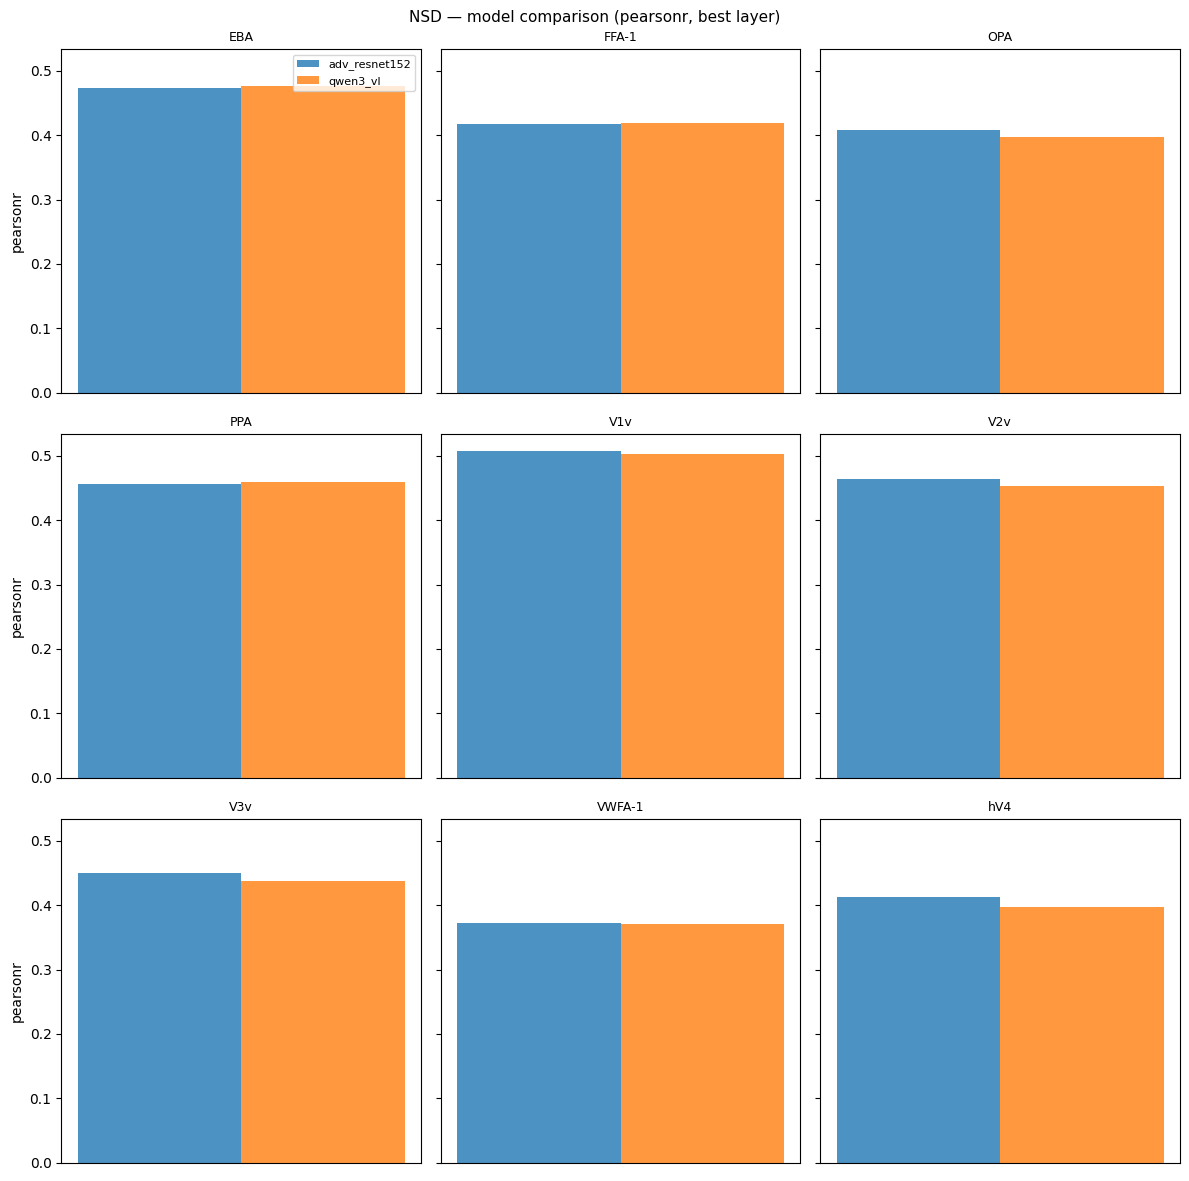

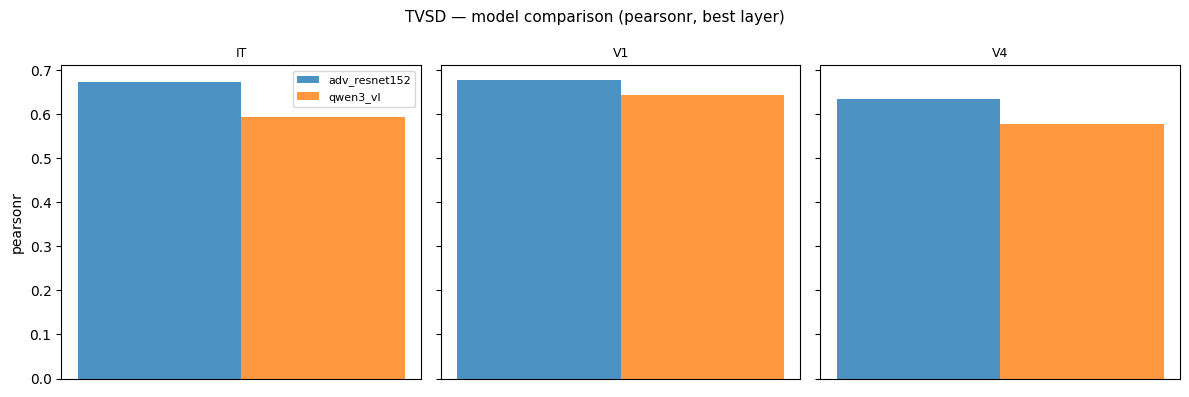

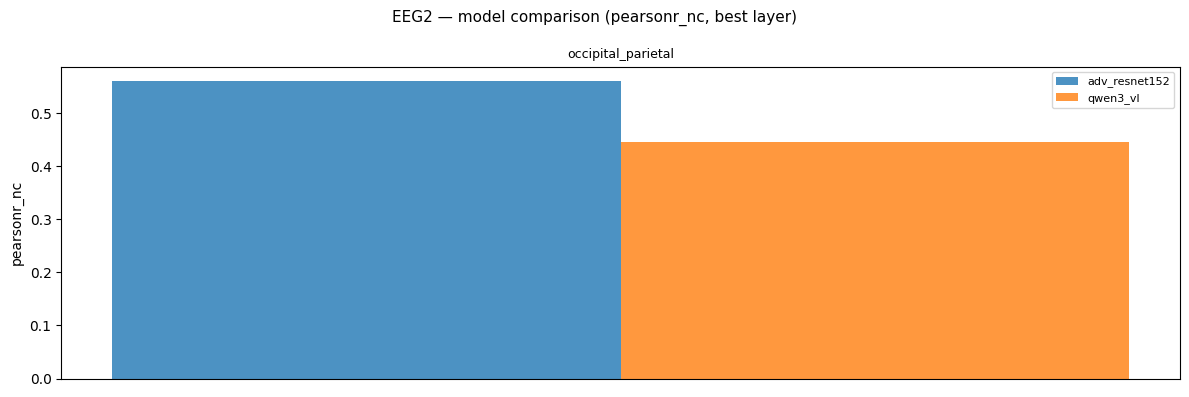

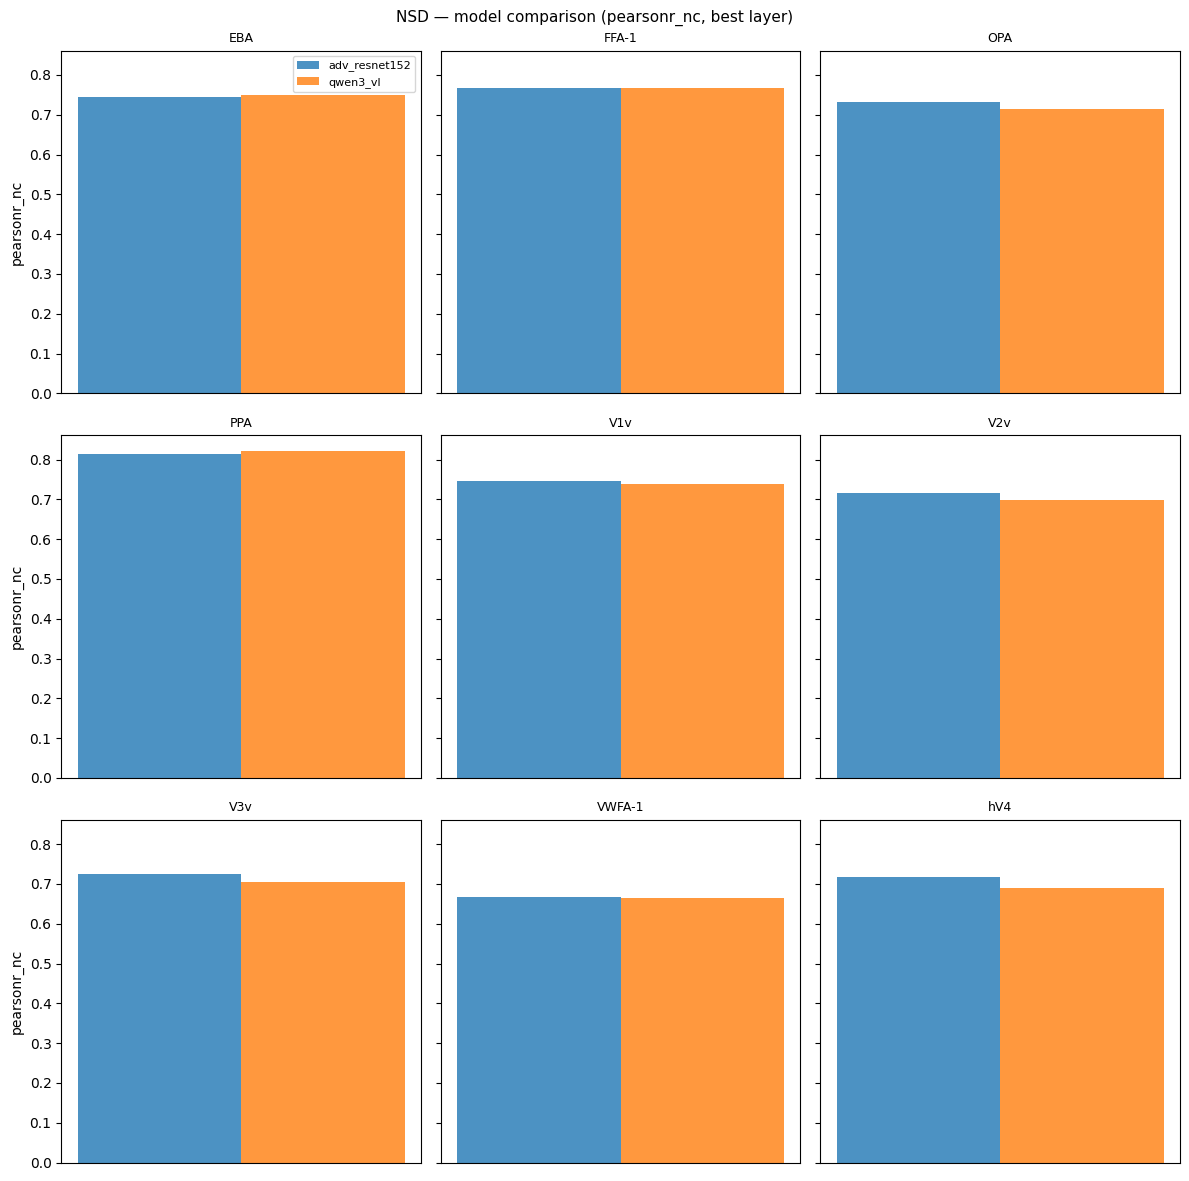

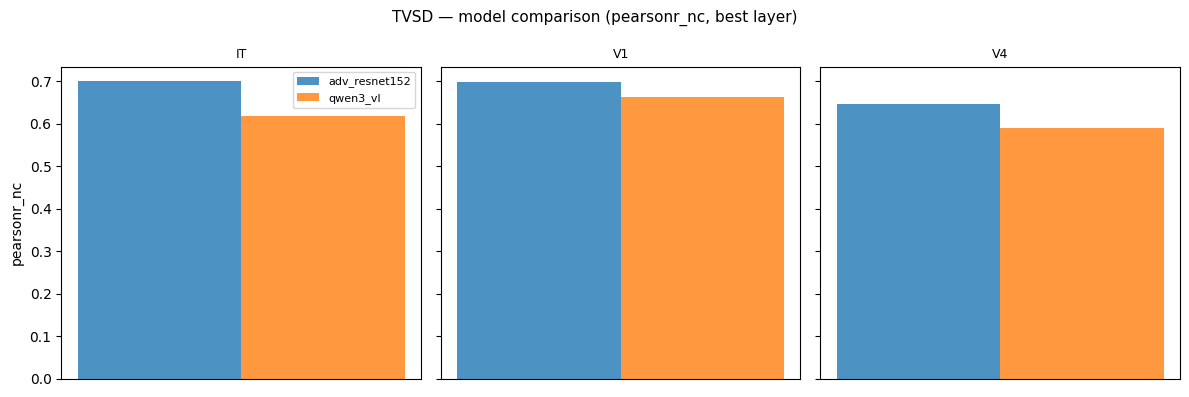

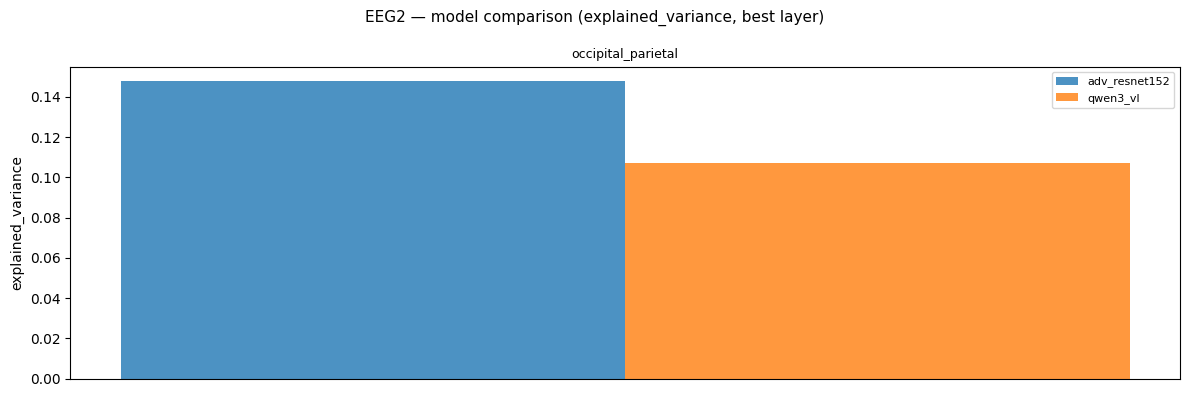

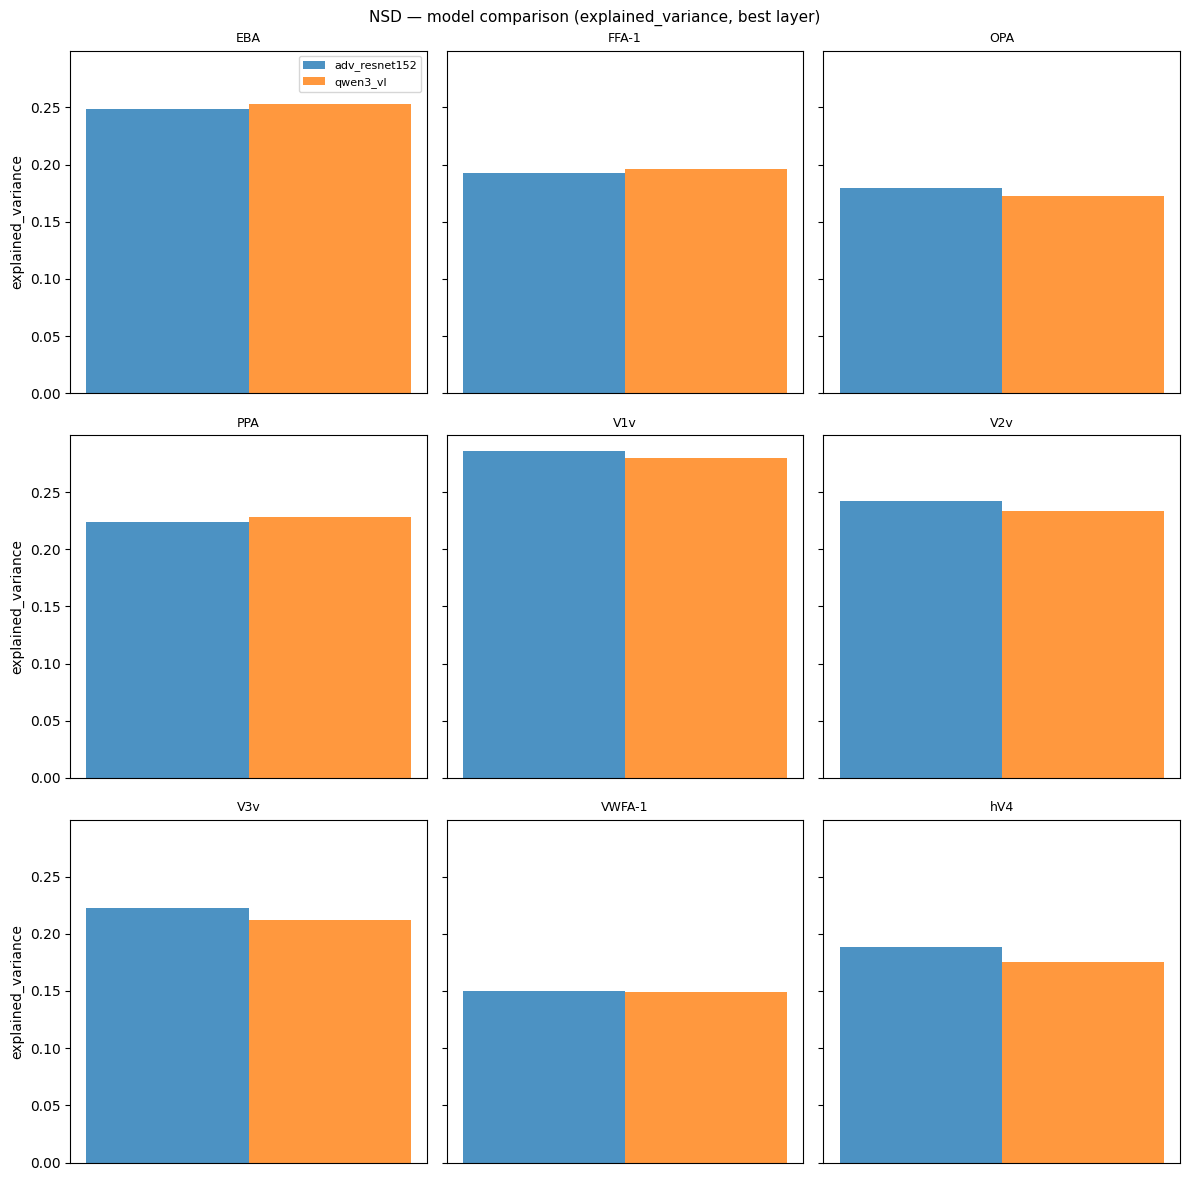

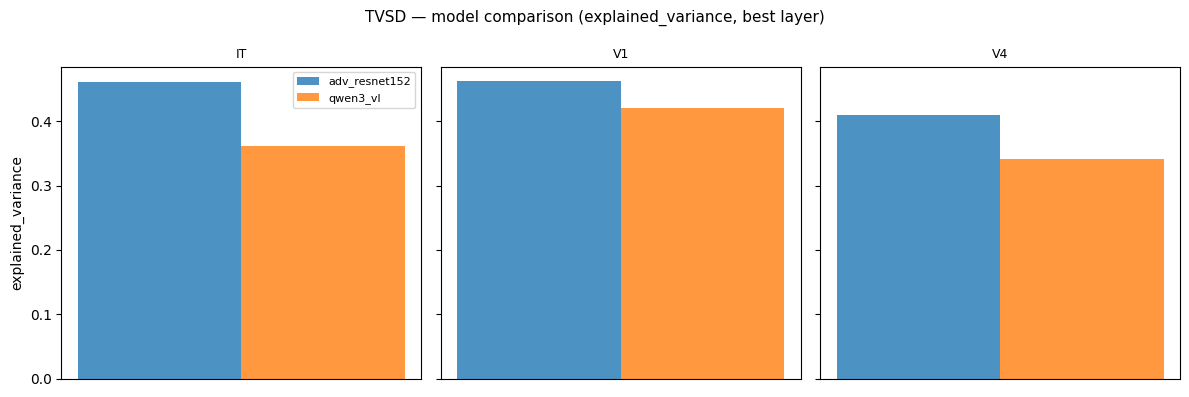

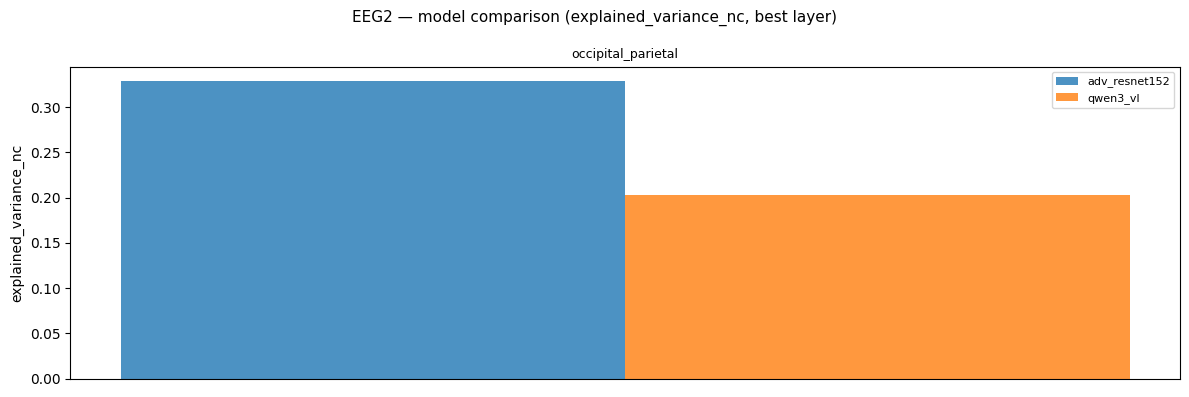

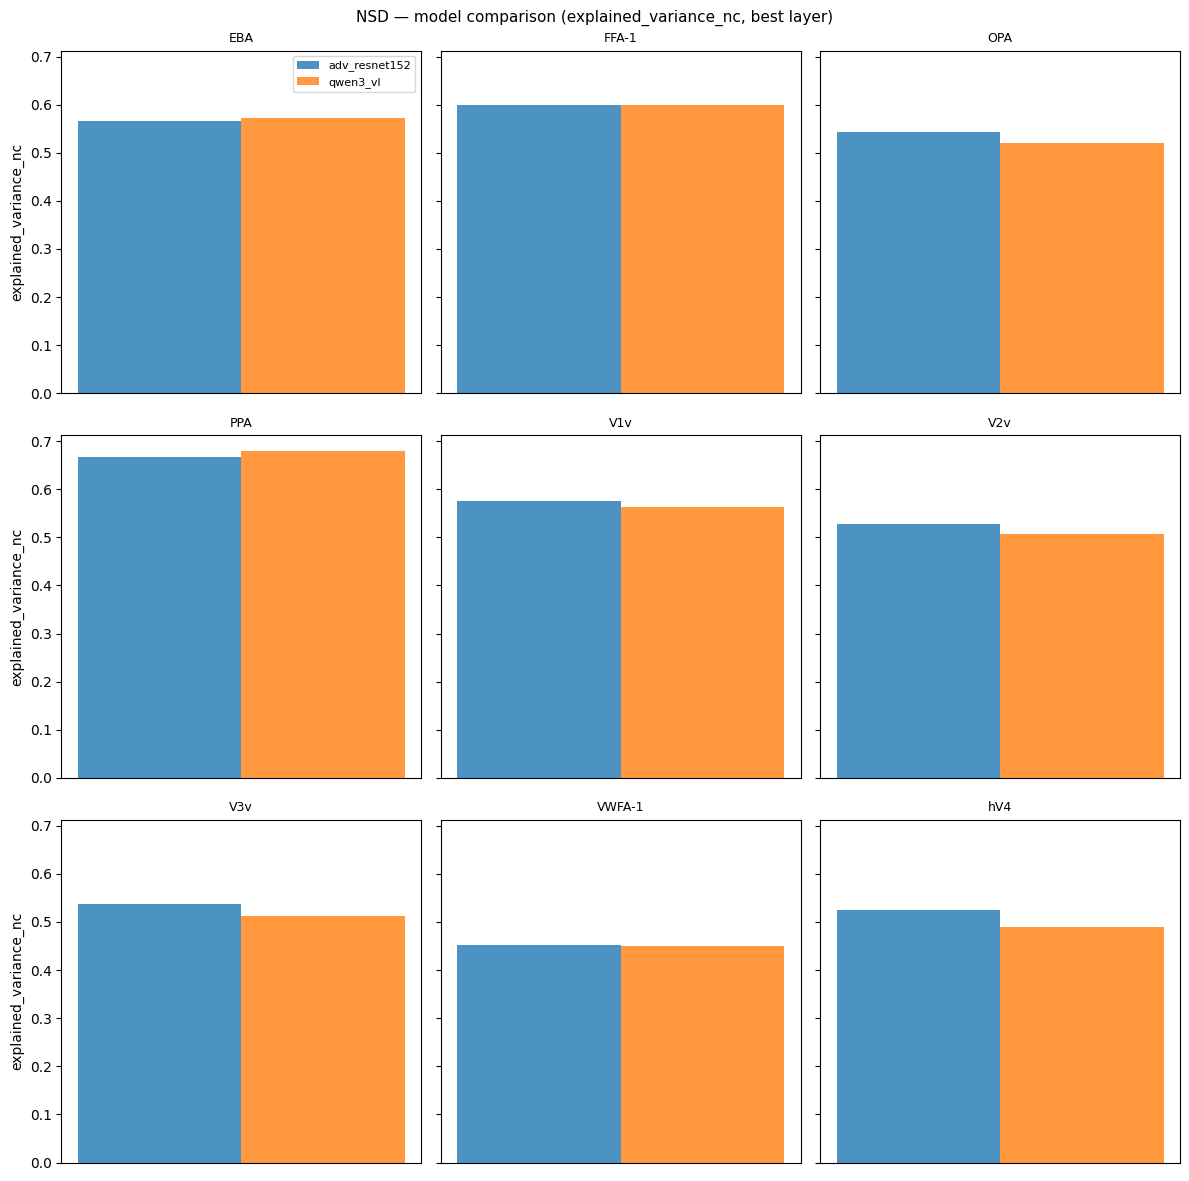

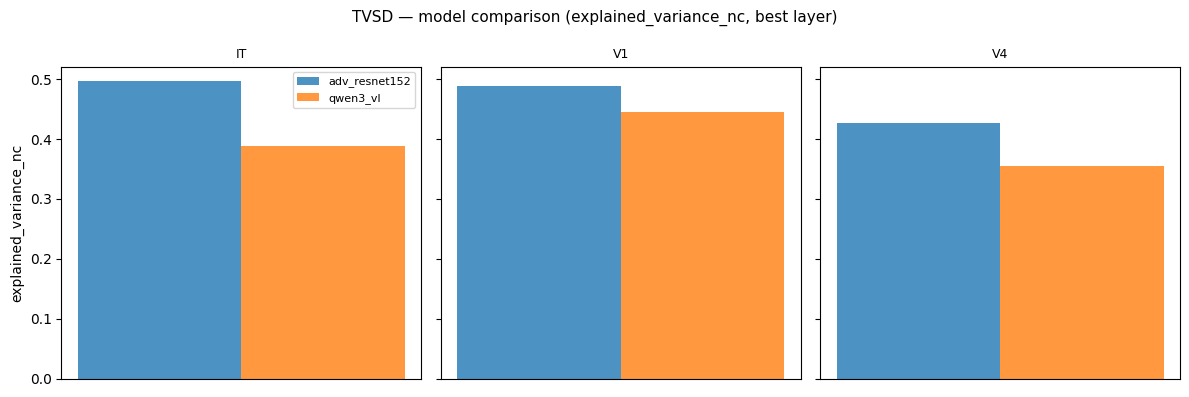

In [110]:
# Model comparison: best score per dataset x ROI
def plot_model_comparison_encoding(df_best, metric="pearsonr",
                                    max_cols=3, figsize=(12, 4)):
    """
    Bar plot comparing both models on best-layer score per ROI,
    one subplot per dataset.
    """
    dataset_names = df_best["dataset"].unique().tolist()
    model_names   = df_best["model"].unique().tolist()

    for dataset_name in dataset_names:
        df = df_best[df_best["dataset"] == dataset_name]
        roi_names = df["roi"].unique().tolist()

        n_rois = len(roi_names)
        n_cols = min(n_rois, max_cols)
        n_rows = int(np.ceil(n_rois / n_cols))
        width  = 0.35

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(figsize[0], figsize[1] * n_rows),
            sharey=True, squeeze=False,
        )

        for idx, roi in enumerate(roi_names):
            row = idx // n_cols
            col = idx % n_cols
            ax  = axes[row][col]

            for i, model_name in enumerate(model_names):
                sub   = df[(df["roi"] == roi) & (df["model"] == model_name)]
                score = sub[metric].values[0] if len(sub) > 0 else 0.0
                ax.bar(i * width, score, width, label=model_name, alpha=0.8)

            ax.set_title(roi, fontsize=9)
            ax.set_xticks([])
            ax.axhline(0, linestyle="--", linewidth=0.7, color="gray")
            if col == 0:
                ax.set_ylabel(metric)

        axes[0][0].legend(fontsize=8)

        for idx in range(n_rois, n_rows * n_cols):
            axes[idx // n_cols][idx % n_cols].set_visible(False)

        fig.suptitle(
            f"{dataset_name} — model comparison ({metric}, best layer)",
            fontsize=11
        )
        plt.tight_layout()
        plt.show()

for metric in ["pearsonr", "pearsonr_nc", "explained_variance", "explained_variance_nc"]:
    plot_model_comparison_encoding(df_best_enc, metric=metric,
                                    max_cols=3, figsize=(12, 4))

In [111]:
# TODO: summarize best layers and best scores

# 1) Best layer summary per dataset / model / roi
print("=" * 80)
print("BEST LAYER SUMMARY")
print("=" * 80)

for dataset_name in results_enc:
    print(f"\n{'─'*40}")
    print(f"Dataset: {dataset_name}")
    print(f"{'─'*40}")
    df_ds = df_best_enc[df_best_enc["dataset"] == dataset_name]
    display(df_ds[[
        "model", "roi", "layer",
        "pearsonr", "pearsonr_nc",
        "explained_variance", "explained_variance_nc",
        "encoding_rsa", "encoding_cka",
    ]].sort_values(["model", "roi"]).reset_index(drop=True))

BEST LAYER SUMMARY

────────────────────────────────────────
Dataset: TVSD
────────────────────────────────────────


,model,roi,layer,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_rsa,encoding_cka
0,adv_resnet152,IT,features/layer3-25,0.673683,0.699197,0.460573,0.496298,0.609517,0.643508
1,adv_resnet152,V1,features/layer1-0,0.677347,0.697670,0.461872,0.489326,0.525822,0.713596
2,adv_resnet152,V4,features/layer3-10,0.634377,0.647085,0.410295,0.426816,0.463052,0.622472
3,qwen3_vl,IT,features/visual-blocks-6,0.594500,0.616749,0.361205,0.388647,0.508101,0.511891
4,qwen3_vl,V1,features/visual-blocks-2,0.643483,0.662577,0.421066,0.445654,0.440642,0.663842
5,qwen3_vl,V4,features/visual-blocks-6,0.577229,0.588755,0.341297,0.354961,0.387090,0.539270



────────────────────────────────────────
Dataset: EEG2
────────────────────────────────────────


,model,roi,layer,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_rsa,encoding_cka
0,adv_resnet152,occipital_parietal,features/layer3-30,0.361390,0.55973,0.147632,0.328328,0.068652,0.018632
1,qwen3_vl,occipital_parietal,features/visual-blocks-6,0.295904,0.44561,0.106958,0.202490,0.055929,0.012055



────────────────────────────────────────
Dataset: NSD
────────────────────────────────────────


,model,roi,layer,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_rsa,encoding_cka
0,adv_resnet152,EBA,features/layer4-1,0.472683,0.745128,0.248461,0.565972,0.677696,0.634790
1,adv_resnet152,FFA-1,features/layer4-1,0.417894,0.768401,0.192524,0.598365,0.594220,0.554276
2,adv_resnet152,OPA,features/layer3-25,0.407444,0.732651,0.179498,0.544011,0.464365,0.360515
3,adv_resnet152,PPA,features/layer4-1,0.456273,0.814350,0.224140,0.667766,0.490163,0.539674
4,adv_resnet152,V1v,features/layer3-0,0.508158,0.747002,0.285509,0.574695,0.569601,0.580764
5,adv_resnet152,V2v,features/layer3-0,0.463754,0.714882,0.242073,0.527973,0.502799,0.541244
6,adv_resnet152,V3v,features/layer3-5,0.450068,0.725343,0.222828,0.537996,0.471429,0.468309
7,adv_resnet152,VWFA-1,features/layer4-1,0.372670,0.668150,0.150405,0.452473,0.496456,0.325733
8,adv_resnet152,hV4,features/layer3-20,0.412964,0.717963,0.188787,0.525740,0.444410,0.399939
9,qwen3_vl,EBA,features/language_model-layers-16,0.475965,0.749511,0.252630,0.573161,0.694366,0.653701


In [112]:
# 2) Best score per dataset: which model wins overall
print("\n" + "=" * 80)
print("BEST MODEL PER DATASET (averaged across ROIs)")
print("=" * 80)

metrics_to_compare = [
    "pearsonr", "pearsonr_nc",
    "explained_variance", "explained_variance_nc",
    "encoding_rsa", "encoding_cka",
]

summary_rows = []
for dataset_name in results_enc:
    df_ds = df_best_enc[df_best_enc["dataset"] == dataset_name]
    for model_name in df_ds["model"].unique():
        df_m = df_ds[df_ds["model"] == model_name]
        row  = {"dataset": dataset_name, "model": model_name}
        for metric in metrics_to_compare:
            row[f"mean_{metric}"] = float(np.nanmean(df_m[metric].values))
        summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
display(df_summary.sort_values(["dataset", "model"]).reset_index(drop=True))


BEST MODEL PER DATASET (averaged across ROIs)


,dataset,model,mean_pearsonr,mean_pearsonr_nc,mean_explained_variance,mean_explained_variance_nc,mean_encoding_rsa,mean_encoding_cka
0,EEG2,adv_resnet152,0.361390,0.559730,0.147632,0.328328,0.068652,0.018632
1,EEG2,qwen3_vl,0.295904,0.445610,0.106958,0.202490,0.055929,0.012055
2,NSD,adv_resnet152,0.440212,0.737097,0.214914,0.554999,0.523460,0.489472
3,NSD,qwen3_vl,0.435053,0.727991,0.211061,0.543814,0.528885,0.494747
4,TVSD,adv_resnet152,0.661803,0.681317,0.444246,0.470813,0.532797,0.659859
5,TVSD,qwen3_vl,0.605071,0.622694,0.374523,0.396421,0.445277,0.571668


In [113]:
# 3) Winner table: which model has the higher mean score per dataset
print("\n" + "=" * 80)
print("WINNER PER DATASET AND METRIC")
print("=" * 80)

winner_rows = []
for dataset_name in results_enc:
    df_ds = df_summary[df_summary["dataset"] == dataset_name]
    row   = {"dataset": dataset_name}
    for metric in metrics_to_compare:
        col    = f"mean_{metric}"
        best_model = df_ds.loc[df_ds[col].idxmax(), "model"]
        best_score = df_ds[col].max()
        row[metric] = f"{best_model} ({best_score:.4f})"
    winner_rows.append(row)

df_winners = pd.DataFrame(winner_rows)
display(df_winners)


WINNER PER DATASET AND METRIC


,dataset,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_rsa,encoding_cka
0,TVSD,adv_resnet152 (0.6618),adv_resnet152 (0.6813),adv_resnet152 (0.4442),adv_resnet152 (0.4708),adv_resnet152 (0.5328),adv_resnet152 (0.6599)
1,EEG2,adv_resnet152 (0.3614),adv_resnet152 (0.5597),adv_resnet152 (0.1476),adv_resnet152 (0.3283),adv_resnet152 (0.0687),adv_resnet152 (0.0186)
2,NSD,adv_resnet152 (0.4402),adv_resnet152 (0.7371),adv_resnet152 (0.2149),adv_resnet152 (0.5550),qwen3_vl (0.5289),qwen3_vl (0.4947)


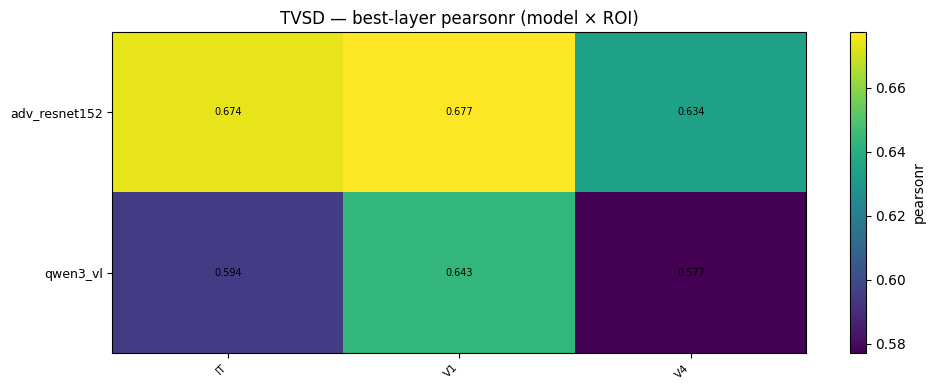

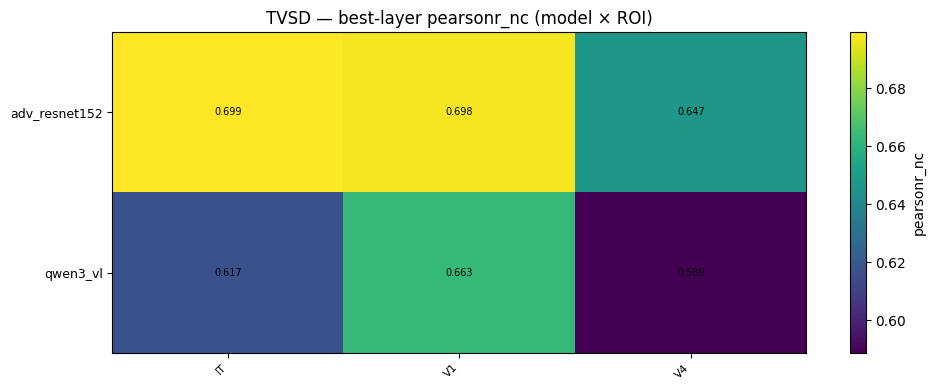

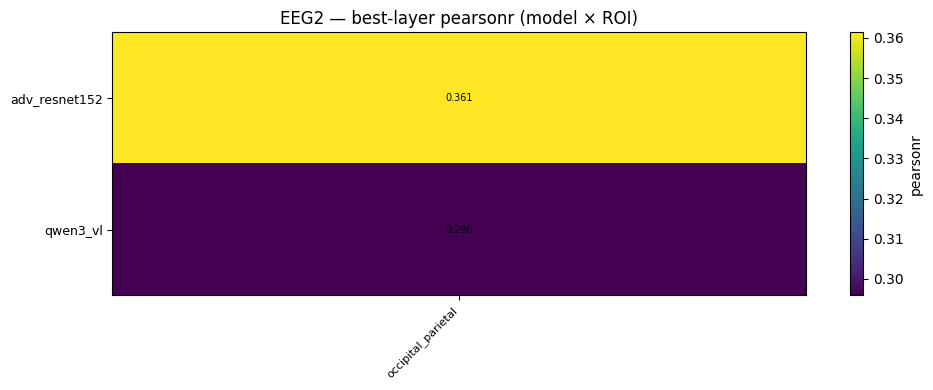

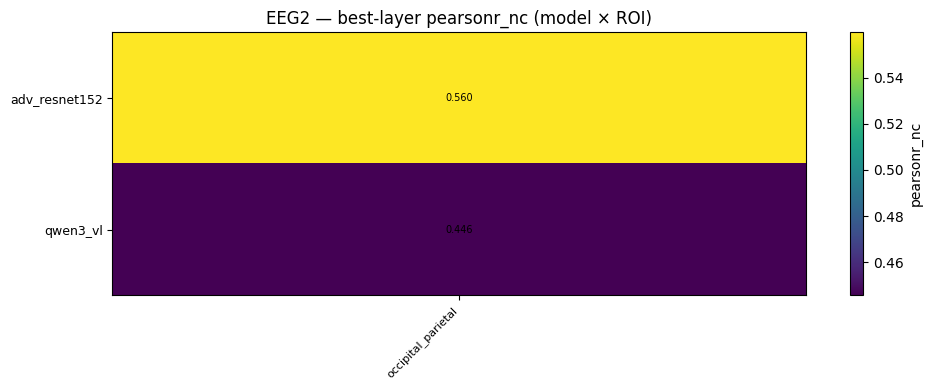

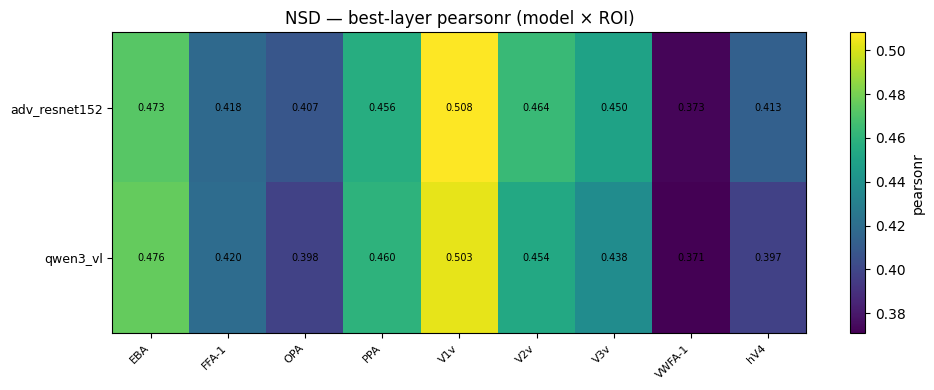

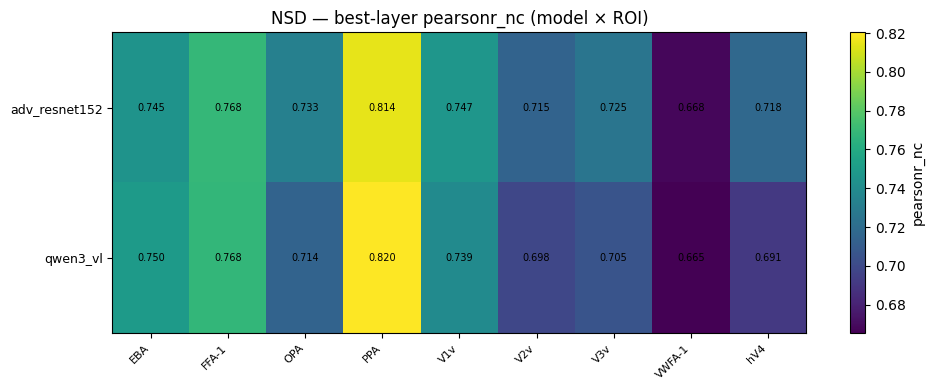

In [114]:
# 4) Visual summary: heatmap of best Pearson r per model x ROI
def plot_score_heatmap(df_best, dataset_name, metric="pearsonr", figsize=(10, 4)):
    """
    Heatmap of best-layer metric values, rows = models, cols = ROIs.
    """
    df_ds = df_best[df_best["dataset"] == dataset_name]
    pivot = df_ds.pivot(index="model", columns="roi", values=metric)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")
    plt.colorbar(im, ax=ax, label=metric)

    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(pivot.index, fontsize=9)

    # Annotate cells
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        fontsize=7, color="white" if val < pivot.values.max() * 0.7 else "black")

    ax.set_title(f"{dataset_name} — best-layer {metric} (model × ROI)")
    plt.tight_layout()
    plt.show()

for dataset_name in results_enc:
    plot_score_heatmap(df_best_enc, dataset_name, metric="pearsonr")
    plot_score_heatmap(df_best_enc, dataset_name, metric="pearsonr_nc")

In [115]:
# 5) Print single best configuration per dataset
print("\n" + "=" * 80)
print("SINGLE BEST CONFIGURATION PER DATASET")
print("=" * 80)

for dataset_name in results_enc:
    df_ds  = df_best_enc[df_best_enc["dataset"] == dataset_name]
    idx    = df_ds["pearsonr"].idxmax()
    best   = df_ds.loc[idx]
    print(f"\n{dataset_name}:")
    print(f"  model            : {best['model']}")
    print(f"  roi              : {best['roi']}")
    print(f"  layer            : {best['layer']}")
    print(f"  pearsonr         : {best['pearsonr']:.4f}")
    print(f"  pearsonr_nc      : {best['pearsonr_nc']:.4f}")
    print(f"  explained_var    : {best['explained_variance']:.4f}")
    print(f"  explained_var_nc : {best['explained_variance_nc']:.4f}")
    print(f"  encoding_rsa     : {best['encoding_rsa']:.4f}")
    print(f"  encoding_cka     : {best['encoding_cka']:.4f}")


SINGLE BEST CONFIGURATION PER DATASET

TVSD:
  model            : adv_resnet152
  roi              : V1
  layer            : features/layer1-0
  pearsonr         : 0.6773
  pearsonr_nc      : 0.6977
  explained_var    : 0.4619
  explained_var_nc : 0.4893
  encoding_rsa     : 0.5258
  encoding_cka     : 0.7136

EEG2:
  model            : adv_resnet152
  roi              : occipital_parietal
  layer            : features/layer3-30
  pearsonr         : 0.3614
  pearsonr_nc      : 0.5597
  explained_var    : 0.1476
  explained_var_nc : 0.3283
  encoding_rsa     : 0.0687
  encoding_cka     : 0.0186

NSD:
  model            : adv_resnet152
  roi              : V1v
  layer            : features/layer3-0
  pearsonr         : 0.5082
  pearsonr_nc      : 0.7470
  explained_var    : 0.2855
  explained_var_nc : 0.5747
  encoding_rsa     : 0.5696
  encoding_cka     : 0.5808


---

## 2.5 Compare predictive and representational metrics

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare the ranking of models and layers according to:

- Pearson correlation,
- explained variance,
- RSA,
- CKA.
- encoding-RSA/ encoding-CKA

Discuss whether the same layers are favored by all metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One figure comparing layer or model rankings across metrics**
2. **One concrete example where two metrics agree**
3. **One concrete example where two metrics disagree**
4. **One short written interpretation** in Answer box 2.4.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.4</strong><br>Does a model that is representationally similar to the brain also predict neural responses well? Use at least one example from your results.</div>

In [ ]:
# TODO: compare ranking of layers across metrics
# TODO: identify agreements and disagreements

---

## 2.6 Relate layer hierarchy to brain hierarchy

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Test whether deeper layers align better with higher-level neural targets.

- Does TVSD IT align with deeper layers than V1?
- Do higher-level NSD regions prefer later layers?
- For EEG, are particular time windows associated with later layers?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include one of the following analyses:

1. **A heatmap of layer × ROI**
2. **A ranked-layer plot by ROI**
3. **A time-resolved EEG layer comparison**

You must also include a short written conclusion in Answer box 2.5 stating whether the results support a hierarchy correspondence.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.5</strong><br>Is there evidence for a correspondence between model depth and neural hierarchy? State your conclusion clearly and support it with results.</div>

In [ ]:
# TODO: compare layers across ROIs / time windows
# TODO: create hierarchy figure(s)

---

## 2.7 Compare the two feature extractors

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare **Qwen3-VL-2B-Instruct** and **Adv-ResNet152** across datasets, ROIs, layers, and metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One summary figure comparing Qwen3-VL-2B-Instruct and Adv-ResNet152**
2. **One table of best scores across datasets and targets**
3. **One short written interpretation** in Answer box 2.6.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.6</strong><br>Does the vision-language model provide a clear advantage over the CNN? Is that advantage consistent across modalities and targets?</div>

In [ ]:
# TODO: aggregate results across both models
# TODO: create summary comparison figure/table

---

# 3. Open-Ended Research

So far you have explored a simple encoding model with a linear readout from a single layer per subject/ROI. In this section, you will extend the baseline pipeline in one clearly defined direction. The goal is to explore a meaningful extension that goes beyond the standard linear readout and to evaluate whether it provides a practically meaningful improvement. Depth is more important than breadth: a focused experiment is better than a broad but shallow exploration.

Possible directions include:

- readouts shared across ROIs,
- readouts shared across subjects,
- readouts shared across modalities,
- combining multiple layers,
- low-rank readouts,
- nonlinear readouts,
- temporal readouts for EEG,
- attention-based readouts,
- cross-subject pooling.

## What you must include

1. **Question**  
   What are you testing?

2. **Motivation**  
   Why is this extension interesting?

3. **Method**  
   What did you change relative to the linear baseline?

4. **Comparison**  
   How does it compare to the baseline?

5. **Interpretation**  
   Did it help, and why might that be?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly stated hypothesis**
2. **A short motivation for the extension**
3. **A clear description of the new method**
4. **One direct comparison against the linear baseline**
5. **At least one figure or one table summarizing the comparison**
6. **A short discussion of whether the extension helped in a practically meaningful way**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 3</strong><br>State your hypothesis, summarize your result, and say whether the new method helped in a practically meaningful way.</div>

In [ ]:
# TODO: define extension
# TODO: implement method
# TODO: compare against linear baseline

---

# Final Discussion

End the notebook with a short final discussion.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must address</div>

- Which dataset appeared noisiest?
- Which neural targets were most reliable?
- Which model aligned best overall?
- Which metrics were most consistent with each other?
- What was the main limitation of your analysis?
- What would you try next with more time?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box final</strong><br>Write a concise final conclusion of 1–2 paragraphs summarizing your main findings and their limitations.</div>

In [ ]:
# No code required here unless you want to add final summary tables/figures.

---

# Report Content

Your **2-page PDF report** should tell a clear and coherent story. It does **not** need to reproduce every notebook result.

It can include:

1. **A brief dataset overview**
2. **An exploratory figure from Section 1**
3. **The EEG noise ceiling comparison**
4. **The NSD reliability visualization**
5. **One or two key brain–model alignment results from Section 2**


Rather, you should primarily focus on the open-ended extension you designed, describing:
- the motivation for your extension,
- the methods you implemented,
- the results you obtained,
- and the scientific insights you gained from it.


The report should emphasize interpretation, not just figures. Since the notebook is the main technical deliverable, the report should act as a **compressed scientific summary** of your most important findings rather than a figure dump.

---

# Detailed Grading Rubric

The project is graded out of **100 points** as follows:

- **Section 1: Inspection, Visualization, and Noise Ceiling Estimates — 20 points**
- **Section 2: Brain–Model Alignment — 20 points**
- **Section 3: Open-Ended Research — 30 points**
- **Report — 30 points**

**Section 0 is required but not graded separately.** It is treated as setup and reproducibility infrastructure for the rest of the notebook.

## Section 1 — 20 points

### 1.1 Dataset inspection — 3 points
- 1 pt: TVSD structure is correctly inspected and explained.
- 1 pt: EEG2 structure is correctly inspected and explained.
- 1 pt: NSD structure is correctly inspected and explained.

### 1.2 EEG visualization — 4 points
- 1 pt: example EEG time-course plot is present and readable.
- 1 pt: channel × time heatmap is present and readable.
- 1 pt: provided EEG noise ceiling visualization is present and readable.
- 1 pt: written interpretation identifies informative time windows or channel groups.

### 1.3 EEG noise ceiling estimation — 7 points
- 2 pts: variance-based estimator is implemented correctly.
- 2 pts: split-half estimator is implemented correctly.
- 1 pt: required summary visualizations are included.
- 1 pt: comparison to stored EEG noise ceilings is shown clearly.
- 1 pt: Answer box 1.3 interprets similarities and differences between estimators.

### 1.4 Statistical comparison of EEG noise ceilings — 3 points
- 1 pt: quantitative comparison table is present.
- 1 pt: statistical test or formal comparison is appropriate and correctly interpreted.
- 1 pt: final conclusion is clearly justified.

### 1.5 NSD reliability visualization — 3 points
- 1 pt: ncsnr is correctly converted and visualized on cortex.
- 1 pt: parcel overlay or parcel-wise summary is included.
- 1 pt: Answer box 1.5 correctly interprets reliable and unreliable regions.

## Section 2 — 20 points

### 2.1 RSA implementation — 3 points
- 1 pt: RDM computation is correct.
- 1 pt: RDM comparison is correct.
- 1 pt: implementation is used properly in later analyses.

### 2.2 Unbiased linear CKA implementation — 3 points
- 2 pts: unbiased linear CKA is implemented correctly.
- 1 pt: implementation is used properly in later analyses.

### 2.3 Representational analyses across layers, models, and targets — 4 points
- 1 pt: layer-wise RSA results are reported clearly.
- 1 pt: layer-wise CKA results are reported clearly.
- 1 pt: a model comparison is included.
- 1 pt: ROI-wise or time-resolved analysis is included and interpreted.

### 2.4 Predictive alignment with linear encoding models — 6 points
- 1 pt: required targets are selected and described correctly.
- 2 pts: train/validation/test procedure and ridge fitting are correct.
- 1 pt: required predictive metrics are reported correctly.
- 1 pt: encoding-RSA and encoding-CKA are reported correctly.
- 1 pt: best-layer summary and model comparison are included.

### 2.5 Compare predictive and representational metrics — 2 points
- 1 pt: ranking comparison figure is present and informative.
- 1 pt: agreement and disagreement between metrics are discussed clearly.

### 2.6 Layer hierarchy vs brain hierarchy — 1 point
- 1 pt: at least one hierarchy analysis is included and interpreted correctly.

### 2.7 Compare the two feature extractors — 1 point
- 1 pt: final comparison between Qwen3-VL and Adv-ResNet is clear and supported by results.

## Section 3 — 30 points

### Research question and motivation — 5 points
- 2 pts: research question is clear and focused.
- 3 pts: motivation is scientifically sensible and well connected to the baseline project.

### Method and implementation — 10 points
- 4 pts: the extension is described clearly.
- 4 pts: the method is implemented correctly.
- 2 pts: the design remains focused and technically appropriate for the project scope.

### Baseline comparison and evaluation — 10 points
- 4 pts: the comparison to the linear baseline is fair.
- 3 pts: at least one figure or table communicates the comparison clearly.
- 3 pts: evaluation supports the stated conclusion.

### Interpretation and limitations — 5 points
- 3 pts: the student explains whether the method helped in a practically meaningful way.
- 2 pts: limitations or caveats are acknowledged.

## Report — 30 points

### Structure and clarity — 6 points
- clear organization, readable flow, and concise scientific writing.

### Selection of results — 6 points
- the report focuses on the strongest and most relevant results rather than trying to include everything.

### Methodological correctness — 6 points
- metrics, comparisons, and claims are described accurately.

### Interpretation and synthesis — 6 points
- the report explains what the results mean and ties them back to the project goals.

### Figure quality and presentation — 6 points
- figures are readable, labeled, well-chosen, and integrated into the narrative.

## Important grading note

A submission that is technically correct but poorly interpreted will lose points. A submission with good intuition but missing required analyses will also lose points. The strongest submissions will be both **correct** and **scientifically well explained**.

---

# Final Checklist Before Submission

Before submitting, make sure that:

- group information is filled in,
- the notebook runs from top to bottom,
- all notebook outputs are cleared,
- figures have readable titles and labels,
- written answers are included in the answer boxes,
- the zip archive name follows the required format,
- no large unnecessary files are included.

---

# References

Use the references below when you need scientific context for the datasets, models, and analysis methods.

## Datasets

- Papale et al. (2025) — *An extensive dataset of spiking activity to reveal the syntax of the ventral stream*
- Gifford et al. (2022) — *A large and rich EEG dataset for modeling human visual object recognition*
- Allen et al. (2022) — *A massive 7T fMRI dataset to bridge cognitive neuroscience and artificial intelligence*
- van Bree, Styrnal, and Hebart (2025) — *How Much Variance Does Your Model Explain? A Clarifying Note On The Use Of Split-Half Reliability For Computing Noise Ceilings*

## Models

- Wong et al. (2020) — *Fast is better than free: Revisiting adversarial training*
- He et al. (2016) — *Deep Residual Learning for Image Recognition*
- Bai et al. (2025) — *Qwen3-VL Technical Report*

## Alignment and encoding

- Conwell et al. (2024) — *A large-scale examination of inductive biases shaping high-level visual representation in brains and machines*
- Gokce and Schrimpf (2025) — *Scaling Laws for Task-Optimized Models of the Primate Visual Ventral Stream*

Use these references selectively. You are not expected to read everything in full.